# id2_std_3m因子

从研报当中所作的研究可以得知，该因子确实与市值和行业存在相关性，所以后续复现时不能简单把全市场股票放在一起直接排序选股。行业层面，不同行业的波动率因子中位数存在明显差异，例如建材、石油石化、机械等行业波动率较高，而银行、非银金融、电力及公用事业等行业波动率较低，因此跨行业直接比较因子值可能会混入行业差异，后续应考虑行业中性化或行业内排序。市值层面，研报指出大盘股通常波动率较小，多数波动率因子与市值因子呈负相关，其中 id2_std_3m 与市值因子的平均相关系数为 -0.073，说明即使该因子已经是三因子回归残差波动率，最终因子值仍然没有完全摆脱市值影响。因此，在后续裸用回测和参数测试中，需要同时观察原始因子和市值/行业中性化因子的表现，并在不同市值区间、行业内部进一步检验因子的真实选股能力。

## 原始因子IC、ICIR、RankIC、RankICIR、因子收益率

In [ ]:
# ============================================================
# id2_std_3m 原始因子：
# 30日横截面周期下的 IC / RankIC / 因子收益率测试
# BigQuant Notebook 完整版：
# 仅输出一张纵向汇总表 + 两张图表
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from IPython.display import display


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2021-07-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 未来30个交易日收益
REBALANCE_DAYS = 30      # 每30个交易日做一次横截面测试

MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数

# 原始因子方向：
#  1：严格使用原始 id2_std_3m
# -1：将低波动率方向正向化，即 factor = -id2_std_3m
FACTOR_SIGN = 1

# 市场收益率：
# True：优先尝试使用中证全指 000985.CSI；
# False：直接使用全市场等权收益率作为市场收益率近似。
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# 是否显示极简运行进度
SHOW_PROGRESS = True

# 如果 BigQuant 环境没有自动识别中文字体，可以在这里手动填入字体路径
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    """
    尽量自动寻找当前环境可用的中文字体。
    若自动失败，可以在参数区手动设置 CHINESE_FONT_PATH。
    """
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh",
            "wqy", "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def winsorize_s(s, lower=0.01, upper=0.99):
    """截面分位数缩尾。"""
    ql, qu = s.quantile([lower, upper])
    return s.clip(ql, qu)


def zscore_s(s):
    """截面 z-score 标准化。"""
    std = s.std(ddof=1)
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


def ols_resid_std(y, X, min_obs=40):
    """
    单只股票时间序列回归：
    y = alpha + beta_mkt * mkt_ret + beta_size * size_ret + beta_bp * bp_ret + resid

    返回残差标准差，即 id2_std_3m。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def cross_section_regression(y, x):
    """
    截面一元回归：
    future_ret = alpha + b * factor_z + error

    返回：
    b      = 当期因子收益率
    t_val  = 当期因子收益率 t 值
    """
    df = pd.DataFrame({"y": y, "x": x})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    n = len(df)

    if n < MIN_CS_N:
        return np.nan, np.nan

    yv = df["y"].values
    xv = df["x"].values

    X = np.column_stack([np.ones(n), xv])

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta

        k = X.shape[1]
        sigma2 = np.sum(resid ** 2) / (n - k)

        xtx_inv = np.linalg.inv(X.T @ X)
        se = np.sqrt(np.diag(sigma2 * xtx_inv))

        factor_ret = beta[1]
        t_value = beta[1] / se[1]

        return factor_ret, t_value

    except Exception:
        return np.nan, np.nan


def safe_mean_std_ir(s):
    """计算均值、标准差、IR。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) == 0:
        return np.nan, np.nan, np.nan

    mean = s.mean()
    std = s.std(ddof=1)
    ir = mean / std if std != 0 else np.nan

    return mean, std, ir


def time_series_tstat(s):
    """时间序列均值的 t 检验。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) < 2:
        return np.nan

    std = s.std(ddof=1)

    if std == 0:
        return np.nan

    return s.mean() / (std / np.sqrt(len(s)))


def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


# ============================================================
# 3. 读取行情数据
# ============================================================

log_progress("正在读取 A 股日行情数据...")

bar = dai.query(
    """
    SELECT
        date,
        instrument,
        close,
        amount,
        volume,
        name
    FROM cn_stock_bar1d
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()

# 剔除 ST / *ST
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()

bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])


# ============================================================
# 4. 读取市值与 PB 数据
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    """
    SELECT
        date,
        instrument,
        total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])


# ============================================================
# 5. 构造宽表
# ============================================================

log_progress("正在构造宽表...")

close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None)

mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
)

future_ret_wide = close_wide.shift(-HOLD_DAYS) / close_wide - 1

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 6. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None)
        idx_ret = idx_ret.reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True)


size_factor_ret = []
bp_factor_ret = []

for i, dt in enumerate(all_dates):
    if i == 0:
        size_factor_ret.append(np.nan)
        bp_factor_ret.append(np.nan)
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    # 规模因子：小市值组合收益 - 大市值组合收益
    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret.append(small_ret - big_ret)
    else:
        size_factor_ret.append(np.nan)

    # BP 因子：低 PB 组合收益 - 高 PB 组合收益，近似高 BP - 低 BP
    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret.append(low_pb_ret - high_pb_ret)
    else:
        bp_factor_ret.append(np.nan)


factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret,
        "size_ret": pd.Series(size_factor_ret, index=all_dates),
        "bp_ret": pd.Series(bp_factor_ret, index=all_dates),
    },
    index=all_dates
)


# ============================================================
# 7. 每 30 个交易日计算一次 id2_std_3m
# ============================================================

log_progress("正在计算 id2_std_3m 因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(end_pos, len(all_dates) - HOLD_DAYS - 1)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].values
    ret_window = ret_wide.loc[window_dates]

    valid_count = 0

    for inst in all_instruments:
        y = ret_window[inst].values
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, std_resid))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")


factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

factor_df["factor"] = FACTOR_SIGN * factor_df["id2_std_3m"]


# ============================================================
# 8. 合并未来 30 日收益
# ============================================================

log_progress("正在合并未来收益并计算 IC / RankIC / 因子收益率...")

future_ret_long = (
    future_ret_wide
    .stack(dropna=True)
    .rename("future_ret_30d")
    .reset_index()
)

sample = factor_df.merge(
    future_ret_long,
    on=["date", "instrument"],
    how="inner"
)

sample = (
    sample
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor", "future_ret_30d"])
)


# ============================================================
# 9. 逐横截面计算 IC、RankIC、因子收益率和 t 值
# ============================================================

period_results = []

for dt, g in sample.groupby("date"):
    g = g.dropna(subset=["factor", "future_ret_30d"]).copy()

    if len(g) < MIN_CS_N:
        continue

    ic = g["factor"].corr(g["future_ret_30d"], method="pearson")
    rank_ic = g["factor"].corr(g["future_ret_30d"], method="spearman")

    x = winsorize_s(g["factor"], 0.01, 0.99)
    xz = zscore_s(x)

    factor_return, t_value = cross_section_regression(
        y=g["future_ret_30d"],
        x=xz
    )

    period_results.append(
        {
            "date": dt,
            "n_stocks": len(g),
            "IC": ic,
            "RankIC": rank_ic,
            "factor_return": factor_return,
            "t_value": t_value,
            "abs_t_value": abs(t_value) if pd.notna(t_value) else np.nan,
        }
    )

period_df = pd.DataFrame(period_results).sort_values("date").reset_index(drop=True)


# ============================================================
# 10. 汇总统计表：只输出一张纵向完整版
# ============================================================

ic_mean, ic_std, icir = safe_mean_std_ir(period_df["IC"])
ric_mean, ric_std, ricir = safe_mean_std_ir(period_df["RankIC"])
fr_mean, fr_std, fr_ir = safe_mean_std_ir(period_df["factor_return"])

summary = pd.DataFrame(
    [
        {
            "因子名称": "id2_std_3m",
            "因子处理": "原始因子",
            "因子方向": "原始方向" if FACTOR_SIGN == 1 else "低波动率正向化",
            "样本开始": period_df["date"].min().strftime("%Y-%m-%d") if len(period_df) else None,
            "样本结束": period_df["date"].max().strftime("%Y-%m-%d") if len(period_df) else None,
            "横截面周期": f"{REBALANCE_DAYS}个交易日",
            "未来收益窗口": f"{HOLD_DAYS}个交易日",
            "横截面数量": len(period_df),
            "平均股票数": period_df["n_stocks"].mean(),

            "IC均值": ic_mean,
            "IC标准差": ic_std,
            "ICIR": icir,
            "IC序列t检验": time_series_tstat(period_df["IC"]),
            "IC>0占比": (period_df["IC"] > 0).mean(),

            "RankIC均值": ric_mean,
            "RankIC标准差": ric_std,
            "RankICIR": ricir,
            "RankIC序列t检验": time_series_tstat(period_df["RankIC"]),
            "RankIC>0占比": (period_df["RankIC"] > 0).mean(),

            "因子收益率均值": fr_mean,
            "因子收益率标准差": fr_std,
            "因子收益率IR": fr_ir,
            "因子收益率序列t检验": time_series_tstat(period_df["factor_return"]),

            "t值均值": period_df["t_value"].mean(),
            "|t|均值": period_df["abs_t_value"].mean(),
            "|t|>2占比": (period_df["abs_t_value"] > 2).mean(),
        }
    ]
)

summary_show = summary.copy()

for c in summary_show.select_dtypes(include=[np.number]).columns:
    summary_show[c] = summary_show[c].map(
        lambda x: np.nan if pd.isna(x) else round(x, 6)
    )

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 100)

summary_long_show = summary_show.T
summary_long_show.columns = ["结果"]

print("\n========== id2_std_3m 原始因子测试汇总表 ==========")
display(summary_long_show)


# ============================================================
# 11. 图表 1：IC 与 RankIC 序列
# ============================================================

plot_df = period_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(plot_df["date"], plot_df["IC"], label="IC", linewidth=1.8)
ax.plot(plot_df["date"], plot_df["RankIC"], label="RankIC", linewidth=1.8)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 原始因子：IC 与 RankIC 序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("相关系数", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 12. 图表 2：因子收益率序列
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_df["date"],
    plot_df["factor_return"],
    label="因子收益率",
    linewidth=1.8
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 原始因子：30日横截面因子收益率序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("因子收益率", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 13. 保留结果变量，方便后续继续分析
# ============================================================

# summary：原始因子汇总表
# summary_long_show：唯一输出的纵向汇总表
# period_df：逐期 IC / RankIC / 因子收益率 / t值
# factor_df：每个横截面的 id2_std_3m 因子值
# sample：因子值与未来收益合并后的测试样本

print("运行完成。主要结果变量：summary、summary_long_show、period_df、factor_df、sample")

## 市值中性化后IC、ICIR、RankIC、RankICIR、因子收益率

In [ ]:
# ============================================================
# id2_std_3m 市值中性化因子：
# 30日横截面周期下的 IC / RankIC / 因子收益率测试
# BigQuant Notebook 完整版：
# 仅输出一张纵向汇总表 + 两张图表
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from IPython.display import display


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2021-07-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 未来30个交易日收益
REBALANCE_DAYS = 30      # 每30个交易日做一次横截面测试

MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数

# 原始因子方向：
#  1：严格使用原始 id2_std_3m
# -1：将低波动率方向正向化，即 factor = -id2_std_3m
FACTOR_SIGN = 1

# 市值中性化使用的市值字段：
# total_market_cap：总市值
MV_FIELD = "total_market_cap"

# 市场收益率：
# True：优先尝试使用中证全指 000985.CSI；
# False：直接使用全市场等权收益率作为市场收益率近似。
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# 是否显示极简运行进度
SHOW_PROGRESS = True

# 如果 BigQuant 环境没有自动识别中文字体，可以在这里手动填入字体路径
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    """
    尽量自动寻找当前环境可用的中文字体。
    若自动失败，可以在参数区手动设置 CHINESE_FONT_PATH。
    """
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh",
            "wqy", "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def winsorize_s(s, lower=0.01, upper=0.99):
    """截面分位数缩尾。"""
    ql, qu = s.quantile([lower, upper])
    return s.clip(ql, qu)


def zscore_s(s):
    """截面 z-score 标准化。"""
    std = s.std(ddof=1)
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


def ols_resid_std(y, X, min_obs=40):
    """
    单只股票时间序列回归：
    y = alpha + beta_mkt * mkt_ret + beta_size * size_ret + beta_bp * bp_ret + resid

    返回残差标准差，即 id2_std_3m。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def size_neutralize_one_date(g, factor_col="factor_raw_signed", mv_col="total_market_cap"):
    """
    对单个截面的因子做市值中性化：
    factor = alpha + beta * log(mv) + residual

    返回残差 residual。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)

    valid = y.notna() & mv.notna() & (mv > 0)

    residual = pd.Series(np.nan, index=g.index, dtype=float)

    if valid.sum() < MIN_CS_N:
        return residual

    yv = y.loc[valid].values
    log_mv = np.log(mv.loc[valid].values)

    X = np.column_stack([np.ones(len(yv)), log_mv])

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta
        residual.loc[valid] = resid
    except Exception:
        pass

    return residual


def cross_section_regression(y, x):
    """
    截面一元回归：
    future_ret = alpha + b * factor_z + error

    返回：
    b      = 当期因子收益率
    t_val  = 当期因子收益率 t 值
    """
    df = pd.DataFrame({"y": y, "x": x})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    n = len(df)

    if n < MIN_CS_N:
        return np.nan, np.nan

    yv = df["y"].values
    xv = df["x"].values

    X = np.column_stack([np.ones(n), xv])

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta

        k = X.shape[1]
        sigma2 = np.sum(resid ** 2) / (n - k)

        xtx_inv = np.linalg.inv(X.T @ X)
        se = np.sqrt(np.diag(sigma2 * xtx_inv))

        factor_ret = beta[1]
        t_value = beta[1] / se[1]

        return factor_ret, t_value

    except Exception:
        return np.nan, np.nan


def safe_mean_std_ir(s):
    """计算均值、标准差、IR。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) == 0:
        return np.nan, np.nan, np.nan

    mean = s.mean()
    std = s.std(ddof=1)
    ir = mean / std if std != 0 else np.nan

    return mean, std, ir


def time_series_tstat(s):
    """时间序列均值的 t 检验。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) < 2:
        return np.nan

    std = s.std(ddof=1)

    if std == 0:
        return np.nan

    return s.mean() / (std / np.sqrt(len(s)))


def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


# ============================================================
# 3. 读取行情数据
# ============================================================

log_progress("正在读取 A 股日行情数据...")

bar = dai.query(
    """
    SELECT
        date,
        instrument,
        close,
        amount,
        volume,
        name
    FROM cn_stock_bar1d
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()

# 剔除 ST / *ST
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()

bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])


# ============================================================
# 4. 读取市值与 PB 数据
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])


# ============================================================
# 5. 构造宽表
# ============================================================

log_progress("正在构造宽表...")

close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None)

mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
)

future_ret_wide = close_wide.shift(-HOLD_DAYS) / close_wide - 1

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 6. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None)
        idx_ret = idx_ret.reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True)


size_factor_ret = []
bp_factor_ret = []

for i, dt in enumerate(all_dates):
    if i == 0:
        size_factor_ret.append(np.nan)
        bp_factor_ret.append(np.nan)
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    # 规模因子：小市值组合收益 - 大市值组合收益
    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret.append(small_ret - big_ret)
    else:
        size_factor_ret.append(np.nan)

    # BP 因子：低 PB 组合收益 - 高 PB 组合收益，近似高 BP - 低 BP
    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret.append(low_pb_ret - high_pb_ret)
    else:
        bp_factor_ret.append(np.nan)


factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret,
        "size_ret": pd.Series(size_factor_ret, index=all_dates),
        "bp_ret": pd.Series(bp_factor_ret, index=all_dates),
    },
    index=all_dates
)


# ============================================================
# 7. 每 30 个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(end_pos, len(all_dates) - HOLD_DAYS - 1)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].values
    ret_window = ret_wide.loc[window_dates]

    valid_count = 0

    for inst in all_instruments:
        y = ret_window[inst].values
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, std_resid))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")


factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

factor_df["factor_raw_signed"] = FACTOR_SIGN * factor_df["id2_std_3m"]


# ============================================================
# 8. 合并市值，并对因子做市值中性化
# ============================================================

log_progress("正在进行市值中性化处理...")

mv_long = (
    mv_wide
    .stack(dropna=True)
    .rename("total_market_cap")
    .reset_index()
)

factor_df = factor_df.merge(
    mv_long,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()

factor_df["factor_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap"
        )
    )
)

factor_df["factor"] = factor_df["factor_size_neutral"]
factor_df = factor_df.dropna(subset=["factor"]).copy()


# ============================================================
# 9. 合并未来 30 日收益
# ============================================================

log_progress("正在合并未来收益并计算 IC / RankIC / 因子收益率...")

future_ret_long = (
    future_ret_wide
    .stack(dropna=True)
    .rename("future_ret_30d")
    .reset_index()
)

sample = factor_df.merge(
    future_ret_long,
    on=["date", "instrument"],
    how="inner"
)

sample = (
    sample
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor", "future_ret_30d"])
)


# ============================================================
# 10. 逐横截面计算 IC、RankIC、因子收益率和 t 值
# ============================================================

period_results = []

for dt, g in sample.groupby("date"):
    g = g.dropna(subset=["factor", "future_ret_30d"]).copy()

    if len(g) < MIN_CS_N:
        continue

    ic = g["factor"].corr(g["future_ret_30d"], method="pearson")
    rank_ic = g["factor"].corr(g["future_ret_30d"], method="spearman")

    x = winsorize_s(g["factor"], 0.01, 0.99)
    xz = zscore_s(x)

    factor_return, t_value = cross_section_regression(
        y=g["future_ret_30d"],
        x=xz
    )

    period_results.append(
        {
            "date": dt,
            "n_stocks": len(g),
            "IC": ic,
            "RankIC": rank_ic,
            "factor_return": factor_return,
            "t_value": t_value,
            "abs_t_value": abs(t_value) if pd.notna(t_value) else np.nan,
        }
    )

period_df = pd.DataFrame(period_results).sort_values("date").reset_index(drop=True)


# ============================================================
# 11. 市值中性化效果检查：只计算，不单独 display
# ============================================================

neutral_check_rows = []

for dt, g in factor_df.groupby("date"):
    g = g.dropna(subset=["factor_raw_signed", "factor_size_neutral", "total_market_cap"]).copy()

    if len(g) < MIN_CS_N:
        continue

    g["log_mv"] = np.log(g["total_market_cap"])

    neutral_check_rows.append(
        {
            "date": dt,
            "raw_corr_log_mv": g["factor_raw_signed"].corr(g["log_mv"], method="pearson"),
            "neutral_corr_log_mv": g["factor_size_neutral"].corr(g["log_mv"], method="pearson"),
            "raw_rank_corr_log_mv": g["factor_raw_signed"].corr(g["log_mv"], method="spearman"),
            "neutral_rank_corr_log_mv": g["factor_size_neutral"].corr(g["log_mv"], method="spearman"),
        }
    )

neutral_check_df = pd.DataFrame(neutral_check_rows).sort_values("date").reset_index(drop=True)


# ============================================================
# 12. 汇总统计表：只输出一张纵向完整版
# ============================================================

ic_mean, ic_std, icir = safe_mean_std_ir(period_df["IC"])
ric_mean, ric_std, ricir = safe_mean_std_ir(period_df["RankIC"])
fr_mean, fr_std, fr_ir = safe_mean_std_ir(period_df["factor_return"])

summary = pd.DataFrame(
    [
        {
            "因子名称": "id2_std_3m",
            "因子处理": "市值中性化",
            "中性化方式": "截面回归：factor ~ log(total_market_cap)",
            "因子方向": "原始方向" if FACTOR_SIGN == 1 else "低波动率正向化",
            "样本开始": period_df["date"].min().strftime("%Y-%m-%d") if len(period_df) else None,
            "样本结束": period_df["date"].max().strftime("%Y-%m-%d") if len(period_df) else None,
            "横截面周期": f"{REBALANCE_DAYS}个交易日",
            "未来收益窗口": f"{HOLD_DAYS}个交易日",
            "横截面数量": len(period_df),
            "平均股票数": period_df["n_stocks"].mean(),

            "IC均值": ic_mean,
            "IC标准差": ic_std,
            "ICIR": icir,
            "IC序列t检验": time_series_tstat(period_df["IC"]),
            "IC>0占比": (period_df["IC"] > 0).mean(),

            "RankIC均值": ric_mean,
            "RankIC标准差": ric_std,
            "RankICIR": ricir,
            "RankIC序列t检验": time_series_tstat(period_df["RankIC"]),
            "RankIC>0占比": (period_df["RankIC"] > 0).mean(),

            "因子收益率均值": fr_mean,
            "因子收益率标准差": fr_std,
            "因子收益率IR": fr_ir,
            "因子收益率序列t检验": time_series_tstat(period_df["factor_return"]),

            "t值均值": period_df["t_value"].mean(),
            "|t|均值": period_df["abs_t_value"].mean(),
            "|t|>2占比": (period_df["abs_t_value"] > 2).mean(),

            "原始因子与log市值Pearson相关均值": neutral_check_df["raw_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "市值中性化后与log市值Pearson相关均值": neutral_check_df["neutral_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "原始因子与log市值Rank相关均值": neutral_check_df["raw_rank_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "市值中性化后与log市值Rank相关均值": neutral_check_df["neutral_rank_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
        }
    ]
)

summary_show = summary.copy()

for c in summary_show.select_dtypes(include=[np.number]).columns:
    summary_show[c] = summary_show[c].map(
        lambda x: np.nan if pd.isna(x) else round(x, 6)
    )

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 100)

summary_long_show = summary_show.T
summary_long_show.columns = ["结果"]

print("\n========== id2_std_3m 市值中性化因子测试汇总表 ==========")
display(summary_long_show)


# ============================================================
# 13. 图表 1：IC 与 RankIC 序列
# ============================================================

plot_df = period_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(plot_df["date"], plot_df["IC"], label="IC", linewidth=1.8)
ax.plot(plot_df["date"], plot_df["RankIC"], label="RankIC", linewidth=1.8)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 市值中性化因子：IC 与 RankIC 序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("相关系数", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 14. 图表 2：因子收益率序列
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_df["date"],
    plot_df["factor_return"],
    label="因子收益率",
    linewidth=1.8
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 市值中性化因子：30日横截面因子收益率序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("因子收益率", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 15. 保留结果变量，方便后续继续分析
# ============================================================

# summary：市值中性化因子汇总表
# summary_long_show：唯一输出的纵向汇总表
# period_df：逐期 IC / RankIC / 因子收益率 / t值
# factor_df：包含原始 id2_std_3m、原始方向因子、市值中性化因子的横截面因子值
# sample：市值中性化因子值与未来收益合并后的测试样本
# neutral_check_df：逐期市值中性化效果检查结果

print("运行完成。主要结果变量：summary、summary_long_show、period_df、factor_df、sample、neutral_check_df")

## 行业市值中性化后IC、ICIR、RankIC、RankICIR、因子收益率

In [ ]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子：
# 30日横截面周期下的 IC / RankIC / 因子收益率测试
# BigQuant Notebook 完整版：
# 仅输出一张纵向汇总表 + 两张图表
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from IPython.display import display


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2021-07-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 未来30个交易日收益
REBALANCE_DAYS = 30      # 每30个交易日做一次横截面测试

MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

# 原始因子方向：
#  1：严格使用原始 id2_std_3m
# -1：将低波动率方向正向化，即 factor = -id2_std_3m
FACTOR_SIGN = 1

# 市值中性化使用的市值字段：
# total_market_cap：总市值
MV_FIELD = "total_market_cap"

# 市场收益率：
# True：优先尝试使用中证全指 000985.CSI；
# False：直接使用全市场等权收益率作为市场收益率近似。
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# 是否显示极简运行进度
SHOW_PROGRESS = True

# 如果 BigQuant 环境没有自动识别中文字体，可以在这里手动填入字体路径
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 行业数据 SQL：
# 如果自动读取行业失败，请把 CUSTOM_INDUSTRY_SQL 改成你环境中可用的行业字段查询。
# 要求最终返回三列：date, instrument, industry
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    """
    尽量自动寻找当前环境可用的中文字体。
    若自动失败，可以在参数区手动设置 CHINESE_FONT_PATH。
    """
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh",
            "wqy", "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def winsorize_s(s, lower=0.01, upper=0.99):
    """截面分位数缩尾。"""
    ql, qu = s.quantile([lower, upper])
    return s.clip(ql, qu)


def zscore_s(s):
    """截面 z-score 标准化。"""
    std = s.std(ddof=1)
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


def ols_resid_std(y, X, min_obs=40):
    """
    单只股票时间序列回归：
    y = alpha + beta_mkt * mkt_ret + beta_size * size_ret + beta_bp * bp_ret + resid

    返回残差标准差，即 id2_std_3m。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def cross_section_regression(y, x):
    """
    截面一元回归：
    future_ret = alpha + b * factor_z + error

    返回：
    b      = 当期因子收益率
    t_val  = 当期因子收益率 t 值
    """
    df = pd.DataFrame({"y": y, "x": x})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    n = len(df)

    if n < MIN_CS_N:
        return np.nan, np.nan

    yv = df["y"].values
    xv = df["x"].values

    X = np.column_stack([np.ones(n), xv])

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta

        k = X.shape[1]
        sigma2 = np.sum(resid ** 2) / (n - k)

        xtx_inv = np.linalg.inv(X.T @ X)
        se = np.sqrt(np.diag(sigma2 * xtx_inv))

        factor_ret = beta[1]
        t_value = beta[1] / se[1]

        return factor_ret, t_value

    except Exception:
        return np.nan, np.nan


def safe_mean_std_ir(s):
    """计算均值、标准差、IR。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) == 0:
        return np.nan, np.nan, np.nan

    mean = s.mean()
    std = s.std(ddof=1)
    ir = mean / std if std != 0 else np.nan

    return mean, std, ir


def time_series_tstat(s):
    """时间序列均值的 t 检验。"""
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()

    if len(s) < 2:
        return np.nan

    std = s.std(ddof=1)

    if std == 0:
        return np.nan

    return s.mean() / (std / np.sqrt(len(s)))


def load_industry_data(query_start, query_end):
    """
    尝试从 BigQuant 常见表中读取行业字段。
    最终要求返回 date, instrument, industry 三列。

    如果自动读取失败，请在参数区设置 CUSTOM_INDUSTRY_SQL。
    """

    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()

        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry, "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
            industry = industry[["date", "instrument", "industry"]].copy()
            industry = industry.dropna(subset=["date", "instrument", "industry"])
            industry["industry"] = industry["industry"].astype(str)

            if industry.empty:
                continue

            industry = industry.drop_duplicates(["date", "instrument"])

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    """
    对单个截面的因子做行业 + 市值中性化：

    factor = alpha + beta * log(total_market_cap) + industry_dummies + residual

    返回残差 residual。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()

    residual = pd.Series(np.nan, index=g.index, dtype=float)

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    # 股票数太少的行业归入 Other，避免虚拟变量过稀疏
    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].values.astype(float)
    log_mv = np.log(sub[mv_col].values.astype(float))

    industry_dummies = pd.get_dummies(sub[industry_col], prefix="industry", drop_first=True)
    industry_dummies = industry_dummies.astype(float)

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.values.astype(float)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual


def industry_neutrality_check(g, factor_col, industry_col="industry"):
    """
    衡量某一期因子的行业暴露：
    用各行业因子中位数的截面标准差衡量行业差异。
    数值越小，说明行业层面的均值/中位数差异越小。
    """
    tmp = g[[factor_col, industry_col]].replace([np.inf, -np.inf], np.nan).dropna()

    if tmp.empty:
        return np.nan

    med = tmp.groupby(industry_col)[factor_col].median()

    if len(med) <= 1:
        return np.nan

    return med.std(ddof=1)


# ============================================================
# 3. 读取行情数据
# ============================================================

log_progress("正在读取 A 股日行情数据...")

bar = dai.query(
    """
    SELECT
        date,
        instrument,
        close,
        amount,
        volume,
        name
    FROM cn_stock_bar1d
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()

# 剔除 ST / *ST
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()

bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])


# ============================================================
# 4. 读取市值与 PB 数据
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])


# ============================================================
# 5. 读取行业数据
# ============================================================

log_progress("正在读取行业数据...")

industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END)

log_progress(f"行业数据来源：{industry_source}")


# ============================================================
# 6. 构造宽表
# ============================================================

log_progress("正在构造宽表...")

close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None)

mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
)

future_ret_wide = close_wide.shift(-HOLD_DAYS) / close_wide - 1

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 7. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None)
        idx_ret = idx_ret.reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True)


size_factor_ret = []
bp_factor_ret = []

for i, dt in enumerate(all_dates):
    if i == 0:
        size_factor_ret.append(np.nan)
        bp_factor_ret.append(np.nan)
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    # 规模因子：小市值组合收益 - 大市值组合收益
    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret.append(small_ret - big_ret)
    else:
        size_factor_ret.append(np.nan)

    # BP 因子：低 PB 组合收益 - 高 PB 组合收益，近似高 BP - 低 BP
    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret.append(low_pb_ret - high_pb_ret)
    else:
        bp_factor_ret.append(np.nan)


factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret,
        "size_ret": pd.Series(size_factor_ret, index=all_dates),
        "bp_ret": pd.Series(bp_factor_ret, index=all_dates),
    },
    index=all_dates
)


# ============================================================
# 8. 每 30 个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(end_pos, len(all_dates) - HOLD_DAYS - 1)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].values
    ret_window = ret_wide.loc[window_dates]

    valid_count = 0

    for inst in all_instruments:
        y = ret_window[inst].values
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, std_resid))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")


factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

factor_df["factor_raw_signed"] = FACTOR_SIGN * factor_df["id2_std_3m"]


# ============================================================
# 9. 合并市值与行业，并对因子做行业 + 市值中性化
# ============================================================

log_progress("正在进行行业 + 市值中性化处理...")

mv_long = (
    mv_wide
    .stack(dropna=True)
    .rename("total_market_cap")
    .reset_index()
)

factor_df = factor_df.merge(
    mv_long,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"]
factor_df = factor_df.dropna(subset=["factor"]).copy()


# ============================================================
# 10. 合并未来 30 日收益
# ============================================================

log_progress("正在合并未来收益并计算 IC / RankIC / 因子收益率...")

future_ret_long = (
    future_ret_wide
    .stack(dropna=True)
    .rename("future_ret_30d")
    .reset_index()
)

sample = factor_df.merge(
    future_ret_long,
    on=["date", "instrument"],
    how="inner"
)

sample = (
    sample
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor", "future_ret_30d"])
)


# ============================================================
# 11. 逐横截面计算 IC、RankIC、因子收益率和 t 值
# ============================================================

period_results = []

for dt, g in sample.groupby("date"):
    g = g.dropna(subset=["factor", "future_ret_30d"]).copy()

    if len(g) < MIN_CS_N:
        continue

    ic = g["factor"].corr(g["future_ret_30d"], method="pearson")
    rank_ic = g["factor"].corr(g["future_ret_30d"], method="spearman")

    x = winsorize_s(g["factor"], 0.01, 0.99)
    xz = zscore_s(x)

    factor_return, t_value = cross_section_regression(
        y=g["future_ret_30d"],
        x=xz
    )

    period_results.append(
        {
            "date": dt,
            "n_stocks": len(g),
            "IC": ic,
            "RankIC": rank_ic,
            "factor_return": factor_return,
            "t_value": t_value,
            "abs_t_value": abs(t_value) if pd.notna(t_value) else np.nan,
        }
    )

period_df = pd.DataFrame(period_results).sort_values("date").reset_index(drop=True)


# ============================================================
# 12. 中性化效果检查：只计算，不单独 display
# ============================================================

neutral_check_rows = []

for dt, g in factor_df.groupby("date"):
    g = g.dropna(
        subset=[
            "factor_raw_signed",
            "factor_industry_size_neutral",
            "total_market_cap",
            "industry"
        ]
    ).copy()

    if len(g) < MIN_CS_N:
        continue

    g["log_mv"] = np.log(g["total_market_cap"])

    raw_corr = g["factor_raw_signed"].corr(g["log_mv"], method="pearson")
    neutral_corr = g["factor_industry_size_neutral"].corr(g["log_mv"], method="pearson")

    raw_rank_corr = g["factor_raw_signed"].corr(g["log_mv"], method="spearman")
    neutral_rank_corr = g["factor_industry_size_neutral"].corr(g["log_mv"], method="spearman")

    raw_industry_spread = industry_neutrality_check(
        g,
        factor_col="factor_raw_signed",
        industry_col="industry"
    )

    neutral_industry_spread = industry_neutrality_check(
        g,
        factor_col="factor_industry_size_neutral",
        industry_col="industry"
    )

    neutral_check_rows.append(
        {
            "date": dt,
            "raw_corr_log_mv": raw_corr,
            "neutral_corr_log_mv": neutral_corr,
            "raw_rank_corr_log_mv": raw_rank_corr,
            "neutral_rank_corr_log_mv": neutral_rank_corr,
            "raw_industry_median_std": raw_industry_spread,
            "neutral_industry_median_std": neutral_industry_spread,
        }
    )

neutral_check_df = pd.DataFrame(neutral_check_rows).sort_values("date").reset_index(drop=True)


# ============================================================
# 13. 汇总统计表：只输出一张纵向完整版
# ============================================================

ic_mean, ic_std, icir = safe_mean_std_ir(period_df["IC"])
ric_mean, ric_std, ricir = safe_mean_std_ir(period_df["RankIC"])
fr_mean, fr_std, fr_ir = safe_mean_std_ir(period_df["factor_return"])

industry_coverage = factor_df["industry"].notna().mean() if len(factor_df) else np.nan
avg_industry_count = (
    factor_df.groupby("date")["industry"].nunique().mean()
    if len(factor_df) else np.nan
)

summary = pd.DataFrame(
    [
        {
            "因子名称": "id2_std_3m",
            "因子处理": "行业 + 市值中性化",
            "中性化方式": "截面回归：factor ~ log(total_market_cap) + industry_dummies",
            "行业数据来源": industry_source,
            "因子方向": "原始方向" if FACTOR_SIGN == 1 else "低波动率正向化",
            "样本开始": period_df["date"].min().strftime("%Y-%m-%d") if len(period_df) else None,
            "样本结束": period_df["date"].max().strftime("%Y-%m-%d") if len(period_df) else None,
            "横截面周期": f"{REBALANCE_DAYS}个交易日",
            "未来收益窗口": f"{HOLD_DAYS}个交易日",
            "横截面数量": len(period_df),
            "平均股票数": period_df["n_stocks"].mean(),

            "IC均值": ic_mean,
            "IC标准差": ic_std,
            "ICIR": icir,
            "IC序列t检验": time_series_tstat(period_df["IC"]),
            "IC>0占比": (period_df["IC"] > 0).mean(),

            "RankIC均值": ric_mean,
            "RankIC标准差": ric_std,
            "RankICIR": ricir,
            "RankIC序列t检验": time_series_tstat(period_df["RankIC"]),
            "RankIC>0占比": (period_df["RankIC"] > 0).mean(),

            "因子收益率均值": fr_mean,
            "因子收益率标准差": fr_std,
            "因子收益率IR": fr_ir,
            "因子收益率序列t检验": time_series_tstat(period_df["factor_return"]),

            "t值均值": period_df["t_value"].mean(),
            "|t|均值": period_df["abs_t_value"].mean(),
            "|t|>2占比": (period_df["abs_t_value"] > 2).mean(),

            "行业有效覆盖率": industry_coverage,
            "平均行业数量": avg_industry_count,

            "原始因子与log市值Pearson相关均值": neutral_check_df["raw_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "中性化后与log市值Pearson相关均值": neutral_check_df["neutral_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "原始因子与log市值Rank相关均值": neutral_check_df["raw_rank_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,
            "中性化后与log市值Rank相关均值": neutral_check_df["neutral_rank_corr_log_mv"].mean() if len(neutral_check_df) else np.nan,

            "原始因子行业中位数标准差均值": neutral_check_df["raw_industry_median_std"].mean() if len(neutral_check_df) else np.nan,
            "中性化后行业中位数标准差均值": neutral_check_df["neutral_industry_median_std"].mean() if len(neutral_check_df) else np.nan,
        }
    ]
)

summary_show = summary.copy()

for c in summary_show.select_dtypes(include=[np.number]).columns:
    summary_show[c] = summary_show[c].map(
        lambda x: np.nan if pd.isna(x) else round(x, 6)
    )

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 120)

summary_long_show = summary_show.T
summary_long_show.columns = ["结果"]

print("\n========== id2_std_3m 行业 + 市值中性化因子测试汇总表 ==========")
display(summary_long_show)


# ============================================================
# 14. 图表 1：IC 与 RankIC 序列
# ============================================================

plot_df = period_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(plot_df["date"], plot_df["IC"], label="IC", linewidth=1.8)
ax.plot(plot_df["date"], plot_df["RankIC"], label="RankIC", linewidth=1.8)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 行业 + 市值中性化因子：IC 与 RankIC 序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("相关系数", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 15. 图表 2：因子收益率序列
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_df["date"],
    plot_df["factor_return"],
    label="因子收益率",
    linewidth=1.8
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("id2_std_3m 行业 + 市值中性化因子：30日横截面因子收益率序列", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("因子收益率", fontsize=12, **cn_text_kwargs())

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()

ax.grid(True, alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()


# ============================================================
# 16. 保留结果变量，方便后续继续分析
# ============================================================

# summary：行业 + 市值中性化因子汇总表
# summary_long_show：唯一输出的纵向汇总表
# period_df：逐期 IC / RankIC / 因子收益率 / t值
# factor_df：包含原始 id2_std_3m、原始方向因子、行业+市值中性化因子的横截面因子值
# sample：行业+市值中性化因子值与未来收益合并后的测试样本
# neutral_check_df：逐期行业+市值中性化效果检查结果
# industry_df：行业数据

print("运行完成。主要结果变量：summary、summary_long_show、period_df、factor_df、sample、neutral_check_df、industry_df")

## 上述结果的阶段性分析

从三版测试结果来看，`id2_std_3m` 并不是一个简单的市值暴露或行业暴露代理变量。原始因子本身具有明显的负向选股能力，IC均值为 -0.0701、RankIC均值为 -0.1273，说明特质波动率越高，未来收益越差；在做市值中性化后，IC均值和RankIC均值并没有衰减，反而分别提升至 -0.0731 和 -0.1311，说明该因子的有效性并不是单纯来自市值效应；进一步做行业+市值中性化后，IC均值绝对值略有下降至 -0.0642，RankIC均值下降至 -0.1143，但ICIR、RankICIR和因子收益率序列t检验均明显改善，说明行业中性化虽然剥离了一部分行业结构带来的收益差异，但也降低了噪音、提升了因子表现的稳定性。因此，后续如果只是做“裸用策略回测”并观察真实收益曲线，我最推荐优先使用**行业+市值中性化后的因子版本**，理由是它更能代表因子本身的独立选股能力，避免收益曲线被市值风格或行业轮动污染；同时它的RankICIR最优、因子收益率t检验也最强，说明虽然平均IC略低，但信号更稳定、更干净。实际策略方向上应注意该因子是负向因子，后续应买入低 `id2_std_3m` 或使用 `-id2_std_3m` 作为正向信号。

## 全市场行业市值中性化后因子裸用回测记录

In [ ]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子 BigTrader v30 原生回测
#
# 策略设定：
# - 股票池：全市场 A 股，剔除 ST / *ST
# - 因子：id2_std_3m，近 3 个月个股收益对市场、规模、BP 三因子回归残差标准差
# - 因子处理：行业 + 市值中性化
# - 方向：选中性化后因子值最低的前 150 只股票
# - 调仓：每 30 个交易日调仓一次，因子日后第 1 个交易日开盘买入
# - 回测：仅使用 BigQuant / BigTrader 原生 M.bigtrader.v30 回测引擎
#
# 说明：
# 1）本版去掉 bigquant.bigtrader.run、M.trade.v1/v3 等冗余兼容路径；
# 2）不再使用自建回测结果替代原生回测；
# 3）调仓信号仍由前置因子计算生成，最终撮合、手续费、成交量限制由 BigTrader v30 完成。
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
# BigQuant / BigTrader v30 原生回测入口。
# 当前已知可运行范式为：from bigmodule import M，然后 M.bigtrader.v30(...)。
from bigmodule import M
from bigtrader.finance.commission import PerOrder


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2020-01-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 持仓30个交易日
REBALANCE_DAYS = 30      # 每30个交易日调仓一次
BUY_DELAY_DAYS = 1       # 因子日后第1个交易日交易，避免同日未来函数

TOP_K = 150              # 选行业+市值中性化后因子值最低的前150只
MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

FACTOR_SIGN = 1          # 保持原始 id2_std_3m 方向，策略直接选最低值

MV_FIELD = "total_market_cap"

# total_market_cap 单位换算
# 如果 BigQuant 中 total_market_cap 是“元”，则 1e8 换算为“亿元”
# 如果你的字段已经是“亿元”，改为 1
MARKET_CAP_UNIT_DIVISOR = 1e8

# 市场收益率
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# BigTrader v30 原生回测参数
CAPITAL_BASE = 1_000_000
# BigTrader v30 的 benchmark 参数通常使用中文基准名称；因子里的市场收益率仍使用 INDEX_CODE。
BENCHMARK = "沪深300指数"

# 交易成本
BUY_COST = 0.0003        # 买入万3
SELL_COST = 0.0013       # 卖出千1.3
MIN_COST = 5             # 最低5元

# 成交量限制，BigTrader v30 使用
VOLUME_LIMIT = 0.025

# 买卖价格字段
ORDER_PRICE_FIELD_BUY = "open"
ORDER_PRICE_FIELD_SELL = "open"

# 目标仓位使用比例，留少量现金避免费用导致下单失败
TARGET_GROSS_EXPOSURE = 0.98

SHOW_PROGRESS = True

# 中文字体路径。若 BigQuant 环境没有自动识别中文字体，可手动填入字体路径。
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None


# 行业数据 SQL。自动读取失败时，手动填入，要求返回 date, instrument, industry 三列
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    """
    设置 Matplotlib 中文字体，保证持仓市值直方图和行业分布图中文正常显示。
    """
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(
            key in fname_lower
            for key in [
                "noto",
                "sourcehan",
                "simhei",
                "msyh",
                "wqy",
                "wenquanyi",
                "pingfang",
                "heiti",
            ]
        ):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)



# 申万 2021 一级行业代码 -> 中文名称。
# 如果 BigQuant 返回的行业字段本身已经是中文，industry_to_chinese_name 会原样保留。
SW2021_LEVEL1_NAME_MAP = {
    "110000": "农林牧渔",
    "210000": "煤炭",
    "220000": "基础化工",
    "230000": "钢铁",
    "240000": "有色金属",
    "270000": "电子",
    "280000": "汽车",
    "330000": "家用电器",
    "340000": "食品饮料",
    "350000": "纺织服饰",
    "360000": "轻工制造",
    "370000": "医药生物",
    "410000": "公用事业",
    "420000": "交通运输",
    "430000": "房地产",
    "450000": "商贸零售",
    "460000": "社会服务",
    "480000": "银行",
    "490000": "非银金融",
    "510000": "综合",
    "610000": "建筑材料",
    "620000": "建筑装饰",
    "630000": "电力设备",
    "640000": "机械设备",
    "650000": "国防军工",
    "710000": "计算机",
    "720000": "传媒",
    "730000": "通信",
    "740000": "银行",
    "750000": "非银金融",
    "760000": "环保",
    "770000": "美容护理",
}


def industry_to_chinese_name(x):
    """
    将行业编码转成中文行业名称。
    - 对 sw2021_level1 这类 6 位数字编码，映射到申万 2021 一级行业中文名；
    - 对已经是中文名称的字段，直接原样返回；
    - 对缺失值返回“未知行业”。
    """
    if pd.isna(x):
        return "未知行业"

    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return "未知行业"

    # 兼容 640000.0 这种浮点字符串。
    try:
        f = float(s)
        if f.is_integer():
            s_norm = str(int(f))
        else:
            s_norm = s
    except Exception:
        s_norm = s

    return SW2021_LEVEL1_NAME_MAP.get(s_norm, s)



def ols_resid_std(y, X, min_obs=40):
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan



def load_industry_data(query_start, query_end):
    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()

        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry, "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
            industry = industry[["date", "instrument", "industry"]].copy()
            industry = industry.dropna(subset=["date", "instrument", "industry"])
            industry["industry"] = industry["industry"].astype(str)

            if industry.empty:
                continue

            industry = industry.drop_duplicates(["date", "instrument"])

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()

    residual = pd.Series(np.nan, index=g.index, dtype=float)

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].values.astype(float)
    log_mv = np.log(sub[mv_col].values.astype(float))

    industry_dummies = pd.get_dummies(
        sub[industry_col],
        prefix="industry",
        drop_first=True
    ).astype(float)

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.values.astype(float)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = yv - X @ beta
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual




# ============================================================
# 3. 读取行情数据，显式带入涨跌停、停牌相关字段
# ============================================================

log_progress("正在读取 A 股日行情数据...")

# BigQuant 的 cn_stock_bar1d 在不同环境/版本中涨跌停字段名可能不同：
# - 部分环境为 up_limit / down_limit
# - 当前报错环境为 upper_limit / lower_limit
# 这里仅做字段名兼容，不改变后续涨跌停、停牌、买卖可行性判断的基本逻辑。
def query_bar_data(query_start, query_end):
    query_candidates = [
        (
            "upper/lower + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "upper/lower only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
    ]

    errors = []
    for query_name, sql, has_limit_flag in query_candidates:
        try:
            data = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if data is None or data.empty:
                errors.append(f"{query_name}: 查询结果为空")
                continue

            # 统一补齐后续代码需要的列，保证下面的基本逻辑不需要改动。
            if "up_limit" not in data.columns:
                data["up_limit"] = np.nan
            if "down_limit" not in data.columns:
                data["down_limit"] = np.nan
            if "is_open_limit_up" not in data.columns:
                data["is_open_limit_up"] = np.nan
            if "is_open_limit_down" not in data.columns:
                data["is_open_limit_down"] = np.nan
            if "is_suspended" not in data.columns:
                data["is_suspended"] = np.nan

            log_progress(f"行情数据字段方案：{query_name}")
            return data, has_limit_flag

        except Exception as e:
            errors.append(f"{query_name}: {repr(e)}")
            continue

    raise RuntimeError(
        "未能读取 cn_stock_bar1d 行情数据。请检查当前 BigQuant 环境中 cn_stock_bar1d 的字段名。"
        "\n已尝试字段方案：\n" + "\n".join(errors[-8:])
    )


bar, HAS_LIMIT_FLAG = query_bar_data(QUERY_START, QUERY_END)

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()

# 剔除 ST / *ST
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()

bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])

# 停牌判定
bar["is_suspended_calc"] = (
    bar["open"].isna()
    | bar["close"].isna()
    | bar["amount"].fillna(0).le(0)
    | bar["volume"].fillna(0).le(0)
)

if "is_suspended" in bar.columns:
    bar["is_suspended_final"] = bar["is_suspended"].fillna(False).astype(bool) | bar["is_suspended_calc"]
else:
    bar["is_suspended_final"] = bar["is_suspended_calc"]

# 涨停不可买 / 跌停不可卖
if HAS_LIMIT_FLAG:
    bar["is_open_limit_up_final"] = bar["is_open_limit_up"].fillna(False).astype(bool)
    bar["is_open_limit_down_final"] = bar["is_open_limit_down"].fillna(False).astype(bool)
else:
    eps = 1e-8
    bar["is_open_limit_up_final"] = (
        bar["up_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] >= bar["up_limit"] * (1 - eps))
    )
    bar["is_open_limit_down_final"] = (
        bar["down_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] <= bar["down_limit"] * (1 + eps))
    )

bar["buyable_open"] = (
    ~bar["is_suspended_final"]
    & ~bar["is_open_limit_up_final"]
)

bar["sellable_open"] = (
    ~bar["is_suspended_final"]
    & ~bar["is_open_limit_down_final"]
)


# ============================================================
# 4. 读取市值与 PB 数据
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])


# ============================================================
# 5. 读取行业数据
# ============================================================

log_progress("正在读取行业数据...")

industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END)

log_progress(f"行业数据来源：{industry_source}")


# ============================================================
# 6. 构造宽表
# ============================================================

log_progress("正在构造宽表...")

open_wide = bar.pivot(index="date", columns="instrument", values="open").sort_index()
close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None)

amount_wide = bar.pivot(index="date", columns="instrument", values="amount").reindex(close_wide.index)
volume_wide = bar.pivot(index="date", columns="instrument", values="volume").reindex(close_wide.index)

buyable_wide = bar.pivot(index="date", columns="instrument", values="buyable_open").reindex(close_wide.index).fillna(False)
sellable_wide = bar.pivot(index="date", columns="instrument", values="sellable_open").reindex(close_wide.index).fillna(False)

mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
)

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 7. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None)
        idx_ret = idx_ret.reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True)


size_factor_ret = []
bp_factor_ret = []

for i, dt in enumerate(all_dates):
    if i == 0:
        size_factor_ret.append(np.nan)
        bp_factor_ret.append(np.nan)
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret.append(small_ret - big_ret)
    else:
        size_factor_ret.append(np.nan)

    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret.append(low_pb_ret - high_pb_ret)
    else:
        bp_factor_ret.append(np.nan)


factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret,
        "size_ret": pd.Series(size_factor_ret, index=all_dates),
        "bp_ret": pd.Series(bp_factor_ret, index=all_dates),
    },
    index=all_dates
)


# ============================================================
# 8. 每30个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)

valid_end_pos = min(
    end_pos,
    len(all_dates) - BUY_DELAY_DAYS - HOLD_DAYS - 1
)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].values
    ret_window = ret_wide.loc[window_dates]

    valid_count = 0

    for inst in all_instruments:
        y = ret_window[inst].values
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, std_resid))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")


factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

factor_df["factor_raw_signed"] = FACTOR_SIGN * factor_df["id2_std_3m"]


# ============================================================
# 9. 合并市值与行业，并对因子做行业 + 市值中性化
# ============================================================

log_progress("正在进行行业 + 市值中性化处理...")

mv_long = (
    mv_wide
    .stack(dropna=True)
    .rename("total_market_cap")
    .reset_index()
)

factor_df = factor_df.merge(
    mv_long,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)
factor_df["industry_name"] = factor_df["industry"].map(industry_to_chinese_name)

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"]
factor_df = factor_df.dropna(subset=["factor"]).copy()


# ============================================================
# 10. 生成 BigTrader 交易日选股表：
#     因子日 -> BUY_DELAY_DAYS 后交易日开盘调仓
#     显式剔除：停牌、开盘涨停不可买
# ============================================================

log_progress("正在生成调仓信号表，并剔除停牌与开盘涨停不可买股票...")

tradability_long = bar[
    [
        "date",
        "instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "open",
        "close",
        "amount",
        "volume",
    ]
].copy()

selected_rows = []
holding_rows = []
universe_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    factor_date = all_dates[pos]
    buy_pos = pos + BUY_DELAY_DAYS
    sell_pos = buy_pos + HOLD_DAYS

    if sell_pos >= len(all_dates):
        continue

    buy_date = all_dates[buy_pos]
    sell_date = all_dates[sell_pos]

    g = factor_df[factor_df["date"] == factor_date].copy()

    if g.empty:
        continue

    buy_trade = tradability_long[tradability_long["date"] == buy_date][
        ["instrument", "buyable_open", "sellable_open"]
    ]

    g = g.merge(
        buy_trade,
        on="instrument",
        how="left"
    )

    g["buyable_open"] = g["buyable_open"].fillna(False).astype(bool)

    # 真实约束：买入时剔除停牌、开盘涨停不可买
    g = g[g["buyable_open"]].copy()

    if g.empty:
        continue

    # 记录每个调仓截面的“可买候选股票池”，用于市值区间入选比例的分母。
    # 分母口径：同一调仓日、因子有效、市值有效、行业有效、且开盘可买的全部候选股票记录。
    g["trade_date"] = buy_date
    g["factor_date"] = factor_date
    g["sell_date"] = sell_date
    g["market_cap_yi"] = g["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR
    g["log10_market_cap_yi"] = np.log10(g["market_cap_yi"].replace(0, np.nan))
    if "industry_name" not in g.columns:
        g["industry_name"] = g["industry"].map(industry_to_chinese_name)
    else:
        g["industry_name"] = g["industry_name"].fillna(g["industry"].map(industry_to_chinese_name))

    universe_rows.append(
        g[
            [
                "factor_date",
                "trade_date",
                "sell_date",
                "instrument",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
                "industry_name",
            ]
        ].copy()
    )

    if len(g) < TOP_K:
        continue

    selected_df = (
        g.sort_values("factor", ascending=True)
         .head(TOP_K)
         .copy()
    )

    selected_df["target_weight"] = TARGET_GROSS_EXPOSURE / len(selected_df)
    selected_df["rank_in_portfolio"] = np.arange(1, len(selected_df) + 1)

    selected_rows.append(
        selected_df[
            [
                "trade_date",
                "factor_date",
                "sell_date",
                "instrument",
                "target_weight",
                "rank_in_portfolio",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
                "industry_name",
            ]
        ]
    )

    holding_rows.append(
        selected_df[
            [
                "factor_date",
                "trade_date",
                "sell_date",
                "instrument",
                "rank_in_portfolio",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
                "industry_name",
            ]
        ]
    )

if len(selected_rows) == 0:
    raise RuntimeError("选股结果为空。请检查日期、行业字段、市值字段、涨跌停字段和 TOP_K 设置。")

selected_data = pd.concat(selected_rows, ignore_index=True)
holding_df = pd.concat(holding_rows, ignore_index=True)
universe_df = pd.concat(universe_rows, ignore_index=True)

selected_data["trade_date"] = pd.to_datetime(selected_data["trade_date"]).dt.strftime("%Y-%m-%d")
selected_data["factor_date"] = pd.to_datetime(selected_data["factor_date"]).dt.strftime("%Y-%m-%d")
selected_data["sell_date"] = pd.to_datetime(selected_data["sell_date"]).dt.strftime("%Y-%m-%d")

holding_df["factor_date"] = pd.to_datetime(holding_df["factor_date"])
holding_df["trade_date"] = pd.to_datetime(holding_df["trade_date"])
holding_df["sell_date"] = pd.to_datetime(holding_df["sell_date"])

universe_df["factor_date"] = pd.to_datetime(universe_df["factor_date"])
universe_df["trade_date"] = pd.to_datetime(universe_df["trade_date"])
universe_df["sell_date"] = pd.to_datetime(universe_df["sell_date"])

selected_by_date = {
    d: g[["instrument", "target_weight"]].copy()
    for d, g in selected_data.groupby("trade_date")
}

selected_instruments = sorted(selected_data["instrument"].unique().tolist())

# 卖出约束：开盘跌停或停牌不可卖
sellable_by_date = {
    pd.to_datetime(d).strftime("%Y-%m-%d"): set(g.loc[g["sellable_open"], "instrument"])
    for d, g in tradability_long.groupby("date")
}

buyable_by_date = {
    pd.to_datetime(d).strftime("%Y-%m-%d"): set(g.loc[g["buyable_open"], "instrument"])
    for d, g in tradability_long.groupby("date")
}




# ============================================================
# 11. 输出持仓市值区间入选比例图与中文行业分布图
# ============================================================

log_progress("正在输出所有调仓截面 TopK 持仓市值区间入选比例图和中文行业分布图...")

# holding_df：每个调仓截面的 TopK 目标持仓明细，作为分子；
# universe_df：每个调仓截面中满足因子、市值、行业、开盘可买约束的候选股票池，作为分母。
# 注意：这里统计的是“股票-调仓截面记录”，不是去重后的股票数量。
holding_distribution_summary = {
    "调仓截面数量": int(holding_df["trade_date"].nunique()),
    "候选股票截面记录数量": int(len(universe_df)),
    "持仓记录数量": int(len(holding_df)),
    "平均每期候选股票数量": float(universe_df.groupby("trade_date")["instrument"].nunique().mean()),
    "平均每期目标持仓数量": float(holding_df.groupby("trade_date")["instrument"].nunique().mean()),
    "平均持仓市值_亿元": float(holding_df["market_cap_yi"].replace([np.inf, -np.inf], np.nan).dropna().mean()),
    "中位数持仓市值_亿元": float(holding_df["market_cap_yi"].replace([np.inf, -np.inf], np.nan).dropna().median()),
    "持仓行业数量": int(holding_df["industry_name"].nunique()),
}

print("========== 持仓分布统计 ==========")
for k, v in holding_distribution_summary.items():
    if isinstance(v, float):
        print(f"{k}：{v:.4f}")
    else:
        print(f"{k}：{v}")

# 图 1：市值区间入选比例图
# 纵轴 = 该 log10 市值区间内，TopK 所选股票记录数 / 候选股票记录数。
universe_log_mv = (
    universe_df["log10_market_cap_yi"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
selected_log_mv = (
    holding_df["log10_market_cap_yi"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

if universe_log_mv.empty or selected_log_mv.empty:
    print("提示：市值分布数据为空，跳过市值区间入选比例图。")
    market_cap_selection_ratio_df = pd.DataFrame()
else:
    n_bins = 30
    left = float(universe_log_mv.min())
    right = float(universe_log_mv.max())

    if np.isclose(left, right):
        left -= 0.5
        right += 0.5

    bins = np.linspace(left, right, n_bins + 1)
    universe_count, bin_edges = np.histogram(universe_log_mv.values, bins=bins)
    selected_count, _ = np.histogram(selected_log_mv.values, bins=bin_edges)

    selected_ratio = np.divide(
        selected_count,
        universe_count,
        out=np.zeros_like(selected_count, dtype=float),
        where=universe_count > 0,
    )

    bin_left = bin_edges[:-1]
    bin_right = bin_edges[1:]
    bin_center = (bin_left + bin_right) / 2
    bin_width = np.diff(bin_edges)

    market_cap_selection_ratio_df = pd.DataFrame(
        {
            "bin_left_log10_mv_yi": bin_left,
            "bin_right_log10_mv_yi": bin_right,
            "bin_center_log10_mv_yi": bin_center,
            "candidate_count": universe_count,
            "selected_count": selected_count,
            "selected_ratio": selected_ratio,
        }
    )
    market_cap_selection_ratio_df["selected_ratio_pct"] = market_cap_selection_ratio_df["selected_ratio"] * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(
        market_cap_selection_ratio_df["bin_center_log10_mv_yi"],
        market_cap_selection_ratio_df["selected_ratio"],
        width=bin_width * 0.9,
        align="center",
    )

    ax.set_title(
        f"所有调仓截面 Top{TOP_K} 持仓市值区间入选比例",
        fontsize=15,
        **cn_text_kwargs(),
    )
    ax.set_xlabel("log10(总市值，亿元)", fontsize=12, **cn_text_kwargs())
    ax.set_ylabel("所选股票数 / 该市值区间候选股票数", fontsize=12, **cn_text_kwargs())
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    ax.grid(True, axis="y", alpha=0.3)
    set_cn_tick_font(ax)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

# 图 2：所有调仓截面 TopK 持仓行业中文分布图
industry_count = (
    holding_df["industry_name"]
    .fillna("未知行业")
    .astype(str)
    .value_counts()
    .sort_values(ascending=True)
)

industry_distribution_df = (
    industry_count
    .rename("selected_count")
    .reset_index()
    .rename(columns={"index": "industry_name"})
)
industry_distribution_df["selected_ratio"] = industry_distribution_df["selected_count"] / industry_distribution_df["selected_count"].sum()
industry_distribution_df["selected_ratio_pct"] = industry_distribution_df["selected_ratio"] * 100

fig_height = max(6, len(industry_count) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_height))

ax.barh(industry_count.index, industry_count.values)

ax.set_title(
    f"所有调仓截面 Top{TOP_K} 持仓行业分布",
    fontsize=15,
    **cn_text_kwargs(),
)
ax.set_xlabel("出现次数", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("行业", fontsize=12, **cn_text_kwargs())

ax.grid(True, axis="x", alpha=0.3)
set_cn_tick_font(ax)

fig.tight_layout()
plt.show()
plt.close(fig)


# ============================================================
# 12. 生成 BigTrader v30 回测所需的信号与交易状态字典
# ============================================================

print("\n========== 准备 BigTrader v30 原生回测 ==========")
print("说明：本节将实际调用 M.bigtrader.v30，不使用自建回测，也不回退到 M.trade。")


def to_bigtrader_instrument(inst):
    """
    统一 BigTrader v30 使用的股票代码后缀。
    - DAI 某些环境可能返回 000001.SZA / 600000.SHA；
    - BigTrader v30 通常使用 000001.SZ / 600000.SH。
    """
    s = str(inst)
    if s.endswith(".SZA"):
        return s[:-4] + ".SZ"
    if s.endswith(".SHA"):
        return s[:-4] + ".SH"
    if s.endswith(".BJA"):
        return s[:-4] + ".BJ"
    return s


selected_data["bt_instrument"] = selected_data["instrument"].map(to_bigtrader_instrument)
tradability_long["bt_instrument"] = tradability_long["instrument"].map(to_bigtrader_instrument)

# 调仓信号：date -> DataFrame(bt_instrument, target_weight)
signal_for_bt = selected_data[
    ["trade_date", "bt_instrument", "target_weight", "instrument", "factor_date", "sell_date", "factor"]
].copy()

signal_by_date_for_bt = {
    d: g[["bt_instrument", "target_weight"]].drop_duplicates("bt_instrument").reset_index(drop=True)
    for d, g in signal_for_bt.groupby("trade_date")
}

# 交易状态：date -> instrument -> status
# buyable_open / sellable_open 已经在前面按停牌、开盘涨停、开盘跌停条件计算好。
trade_status_for_bt = tradability_long[
    [
        "date",
        "bt_instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].copy()
trade_status_for_bt["date"] = pd.to_datetime(trade_status_for_bt["date"]).dt.strftime("%Y-%m-%d")
trade_status_for_bt = trade_status_for_bt.drop_duplicates(["date", "bt_instrument"])

# BigTrader 订阅股票池：覆盖所有历史信号出现过的股票，确保买入和后续卖出都能正常处理。
INSTRUMENTS = sorted(signal_for_bt["bt_instrument"].dropna().astype(str).unique().tolist())

trade_start_date = pd.to_datetime(selected_data["trade_date"].min()).strftime("%Y-%m-%d")
trade_end_date = pd.to_datetime(selected_data["sell_date"].max()).strftime("%Y-%m-%d")

# 最后一个持仓周期结束日加入空目标组合，用于在 BigTrader 中尝试清仓，
# 使“持仓 30 个交易日”的设定在最后一期也能落实。
if trade_end_date not in signal_by_date_for_bt:
    signal_by_date_for_bt[trade_end_date] = pd.DataFrame(columns=["bt_instrument", "target_weight"])

print(f"BigTrader 回测开始日期：{trade_start_date}")
print(f"BigTrader 回测结束日期：{trade_end_date}")
print(f"BigTrader 订阅股票数量：{len(INSTRUMENTS)}")
print(f"调仓信号日期数量：{len(signal_by_date_for_bt)}")
print(f"每次目标持仓数量：{TOP_K}")


# ============================================================
# 13. BigTrader v30 回调函数
# ============================================================

def initialize(context):
    """
    BigTrader 初始化函数，只执行一次。
    """
    context.set_commission(
        PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
        )
    )

    context.top_k = TOP_K
    context.target_gross_exposure = TARGET_GROSS_EXPOSURE

    context.signal_by_date = signal_by_date_for_bt

    context.trade_status_by_date = {}
    for d, df in trade_status_for_bt.groupby("date"):
        context.trade_status_by_date[d] = (
            df.set_index("bt_instrument")[[
                "buyable_open",
                "sellable_open",
                "is_suspended_final",
                "is_open_limit_up_final",
                "is_open_limit_down_final",
                "amount",
                "volume",
            ]]
            .to_dict("index")
        )

    print("initialize 完成。")
    print("订阅股票数量：", len(INSTRUMENTS))
    print("调仓信号数量：", len(context.signal_by_date))
    print("目标持仓数量：", context.top_k)


def _get_today(data):
    """兼容 BigTrader v30 中 current_dt 的不同类型。"""
    try:
        return pd.Timestamp(data.current_dt).strftime("%Y-%m-%d")
    except Exception:
        return None


def _get_instrument_key(x):
    """兼容持仓字典 key 可能是字符串，也可能是 BigTrader 对象的情况。"""
    for attr in ["symbol", "instrument", "order_book_id", "code"]:
        if hasattr(x, attr):
            try:
                return to_bigtrader_instrument(getattr(x, attr))
            except Exception:
                pass
    return to_bigtrader_instrument(str(x))


def _get_holding_instruments(context):
    """获取当前持仓股票代码集合。"""
    positions = context.get_account_positions()
    holding = set()

    for k, pos in positions.items():
        instrument = _get_instrument_key(k)
        amount = getattr(pos, "amount", 0)
        if amount > 0:
            holding.add(instrument)

    return holding


def _get_status(context, date_str, instrument):
    """获取某日某股票交易状态；查不到时保守视作不可交易。"""
    day_status = context.trade_status_by_date.get(date_str, {})
    return day_status.get(
        instrument,
        {
            "buyable_open": False,
            "sellable_open": False,
            "is_suspended_final": True,
            "is_open_limit_up_final": True,
            "is_open_limit_down_final": True,
            "amount": 0,
            "volume": 0,
        },
    )


def _can_buy(context, date_str, instrument):
    """
    买入限制：
    - 停牌不能买；
    - 无成交不能买；
    - 开盘涨停不能买。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("buyable_open", False))


def _can_sell(context, date_str, instrument):
    """
    卖出限制：
    - 停牌不能卖；
    - 无成交不能卖；
    - 开盘跌停不能卖。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("sellable_open", False))


def handle_data(context, data):
    """
    BigTrader v30 每个交易日调用一次。
    本策略只在预先生成的 trade_date 上调仓；非信号日直接返回。
    """
    today = _get_today(data)
    if today is None:
        return

    # 非预设调仓日不交易。这样可以避免 BigTrader 自身调仓周期起点与因子信号日错位。
    if today not in context.signal_by_date:
        return

    today_signal = context.signal_by_date[today].copy()

    target_instruments = today_signal["bt_instrument"].astype(str).tolist()
    target_set = set(target_instruments)
    holding_set = _get_holding_instruments(context)

    # 1）先卖出：当前持仓中不在本期目标组合里的股票。
    for instrument in sorted(holding_set - target_set):
        if _can_sell(context, today, instrument):
            try:
                context.order_target_percent(instrument, 0)
            except Exception as e:
                print(f"{today} 卖出 {instrument} 下单异常：{e}")
        else:
            print(f"{today} 无法卖出 {instrument}：停牌、无成交或开盘跌停。")

    # 2）再买入 / 调整：目标组合中当日可买的股票。
    buyable_targets = [ins for ins in target_instruments if _can_buy(context, today, ins)]

    if len(buyable_targets) == 0:
        print(f"{today} 没有可买入标的；如当天为空目标组合，则表示执行期末清仓。")
        return

    weight = context.target_gross_exposure / len(buyable_targets)

    for instrument in buyable_targets:
        try:
            context.order_target_percent(instrument, weight)
        except Exception as e:
            print(f"{today} 买入/调仓 {instrument} 下单异常：{e}")

    print(
        f"{today} 调仓完成：目标 {len(target_instruments)} 只，"
        f"实际可买 {len(buyable_targets)} 只，单票目标权重 {weight:.4f}"
    )


# ============================================================
# 14. 启动 BigTrader v30 原生回测
# ============================================================

print("\n========== 开始 BigTrader v30 原生交易引擎回测 ==========")

backtest_data = {
    "start_date": trade_start_date,
    "end_date": trade_end_date,
    "market": "cn_stock",
    "instruments": INSTRUMENTS,
}

m = M.bigtrader.v30(
    data=backtest_data,
    start_date="",
    end_date="",
    initialize=initialize,
    handle_data=handle_data,

    capital_base=CAPITAL_BASE,
    frequency="daily",
    product_type="股票",

    # 这里设为每日触发 handle_data，由 handle_data 自己判断是否为预设调仓日。
    # 这样不会因为 BigTrader 内部调仓周期起点与因子日错位而漏调仓。
    rebalance_period_type="交易日",
    rebalance_period_days="1",
    rebalance_period_roll_forward=True,

    backtest_engine_mode="标准模式",
    before_start_days=0,

    volume_limit=VOLUME_LIMIT,
    order_price_field_buy=ORDER_PRICE_FIELD_BUY,
    order_price_field_sell=ORDER_PRICE_FIELD_SELL,

    benchmark=BENCHMARK,
    plot_charts=True,
)


# ============================================================
# 15. 保留结果变量
# ============================================================

# selected_data：传入 BigTrader 的调仓选股表
# holding_df：所有调仓截面 Top150 持仓明细
# factor_df：原始因子与行业+市值中性化因子值
# signal_by_date_for_bt：BigTrader 调仓信号字典
# trade_status_for_bt：BigTrader 交易状态表
# m：BigTrader v30 原生回测对象
# industry_df：行业数据

print("\n运行完成。主要结果变量：")
print("selected_data、holding_df、universe_df、factor_df、holding_distribution_summary、market_cap_selection_ratio_df、industry_distribution_df、industry_count、signal_by_date_for_bt、trade_status_for_bt、m、industry_df")
print("提示：m 为 M.bigtrader.v30 返回的 BigTrader 原生回测对象。")


## 持仓市值与行业分布分析

从市值区间入选比例图来看，当前策略并没有在组合层面实现严格的市值中性。图中纵轴已经改为“该市值区间内入选股票数量 / 该市值区间候选股票总数量”，因此它反映的是不同市值区间股票被选入 Top150 的相对概率，而不再只是出现次数。从结果看，入选比例并不是平坦分布，而是呈现出较明显的结构性差异：低市值区间，尤其是 `log10(总市值，亿元)` 约在 0.5–0.8 附近，入选比例较高，最高接近 14%；中等市值区间的入选比例明显下降，多数在 2%–5% 左右；极大市值区间也出现了较高入选比例，但这部分需要谨慎解读，因为超大市值股票本身数量较少，分母较小，单只股票入选就可能显著抬高比例。因此，市值中性化后的因子虽然已经在截面回归中剔除了 `log(total_market_cap)` 的线性影响，但最终“全市场排序 + Top150 等权选股”的组合构建方式，仍然会让策略在某些市值段产生非均匀暴露。

从行业分布图来看，行业名称已经能够正常显示为中文。组合在行业层面存在明显集中：机械设备出现次数最高，显著高于其他行业；计算机、医药生物、电力设备、电子、汽车、基础化工等行业也占比较高；而银行、钢铁、综合、美容护理、非银金融、交通运输等行业出现次数较少。这说明当前组合的行业配置明显偏向制造业、TMT、成长型和设备类行业，而对金融、传统周期、稳定类行业配置较低。

需要注意的是，行业图目前展示的是“入选出现次数”，而不是“行业入选比例”。因此，它可以说明组合最终持仓集中在哪些行业，但还不能完全说明这些行业相对于候选股票池是否超配。因为机械设备、电子、电力设备等行业本身在 A 股中的股票数量较多，如果只看出现次数，会天然更容易排在前面。若要严格判断行业是否中性，最好进一步计算每个行业的：

```text
行业入选比例 = 该行业入选 Top150 的股票数 / 该行业候选股票总数

## 市值分组回测

将市值分为10组，在每一组中分别回测策略，测试因子在那一组市值中表现会最好

In [ ]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子：按市值十组分组 BigTrader v30 原生回测
#
# 策略设定：
# - 股票池：全市场 A 股，剔除 ST / *ST
# - 因子：id2_std_3m，近 3 个月个股收益对市场、规模、BP 三因子回归残差标准差
# - 因子处理：行业 + 市值中性化
# - 市值分组：每个调仓截面按 total_market_cap 从小到大分为 10 组
#       第 1 组 = 最小市值 10%
#       第 10 组 = 最大市值 10%
# - 选股方式：每个市值组内部选中性化后因子值最低的 5%
# - 调仓：每 30 个交易日调仓一次，因子日后第 1 个交易日开盘买入
# - 回测：逐组调用 BigQuant / BigTrader 原生 M.bigtrader.v30 回测引擎
#
# 交易约束：
# - 剔除 ST / *ST
# - 停牌 / 无成交不可买卖
# - 开盘涨停不可买
# - 开盘跌停不可卖
# - 买入万三，卖出千一三，最低 5 元
#
# 内存优化要点：
# - 不再构造 open/amount/volume/buyable/sellable 的宽表，只保留 close、ret、mv、pb 宽表
# - 只在因子截面日期合并市值与行业，不使用全量 mv_wide.stack()
# - 选股信号生成后主动释放行情宽表、因子中间表等大对象
# - 十组回测顺序执行，默认不保存每组 m 对象，避免累计占用内存
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from bigmodule import M
from bigtrader.finance.commission import PerOrder

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2023-01-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 持仓30个交易日
REBALANCE_DAYS = 30      # 每30个交易日调仓一次
BUY_DELAY_DAYS = 1       # 因子日后第1个交易日交易，避免同日未来函数

NUM_SIZE_GROUPS = 10     # 市值十组
SELECT_PCT = 0.05        # 每个市值组内部选因子值最低的5%
MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

FACTOR_SIGN = 1          # 保持原始 id2_std_3m 方向，策略直接选最低值
MV_FIELD = "total_market_cap"

# total_market_cap 单位换算
# 如果 BigQuant 中 total_market_cap 是“元”，则 1e8 换算为“亿元”
# 如果你的字段已经是“亿元”，改为 1
MARKET_CAP_UNIT_DIVISOR = 1e8

# 市场收益率：用于 id2_std_3m 三因子回归中的市场因子
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# BigTrader v30 原生回测参数
CAPITAL_BASE = 1_000_000
BENCHMARK = "沪深300指数"

# 交易成本
BUY_COST = 0.0003        # 买入万3
SELL_COST = 0.0013       # 卖出千1.3
MIN_COST = 5             # 最低5元

# 成交量限制，BigTrader v30 使用
VOLUME_LIMIT = 0.025

# 买卖价格字段
ORDER_PRICE_FIELD_BUY = "open"
ORDER_PRICE_FIELD_SELL = "open"

# 目标仓位使用比例，留少量现金避免费用导致下单失败
TARGET_GROSS_EXPOSURE = 0.98

# 是否保存每个市值组的 BigTrader 回测对象。
# 为降低内存，默认 False：每组回测会输出 BigTrader 原生图表，但不在内存中长期保留 m 对象。
STORE_BACKTEST_OBJECTS = False

# 需要运行的市值组。默认 1~10 全部运行。
# 若资源不足，可以临时改成例如 [1,2,3] 分批运行。
RUN_SIZE_GROUPS = list(range(1, NUM_SIZE_GROUPS + 1))

SHOW_PROGRESS = True

# 中文字体路径。若 BigQuant 环境没有自动识别中文字体，可手动填入字体路径。
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 行业数据 SQL。自动读取失败时，手动填入，要求返回 date, instrument, industry 三列
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def downcast_float_columns(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
    return df


def ols_resid_std(y, X, min_obs=40):
    """
    计算 y 对 X 多元线性回归的残差标准差。
    逻辑与原版一致：使用 np.linalg.lstsq，残差标准差按 ddof=1 计算。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def load_industry_data(query_start, query_end, keep_dates=None):
    """
    自动读取行业数据。
    keep_dates: 若提供，则只保留这些日期，减少后续内存占用。
    """
    def _post_process(industry):
        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry["industry"] = industry["industry"].astype(str)
        if keep_dates is not None:
            industry = industry[industry["date"].isin(keep_dates)].copy()
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry

    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()
        return _post_process(industry), "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry = _post_process(industry)
            if industry.empty:
                continue

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    """
    横截面回归中性化：factor ~ log(total_market_cap) + industry_dummies。
    返回残差。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()
    residual = pd.Series(np.nan, index=g.index, dtype="float32")

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].to_numpy(dtype="float64", copy=False)
    log_mv = np.log(sub[mv_col].to_numpy(dtype="float64", copy=False))

    industry_dummies = pd.get_dummies(
        sub[industry_col],
        prefix="industry",
        drop_first=True
    ).astype("float64")

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.to_numpy(dtype="float64", copy=False)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = (yv - X @ beta).astype("float32")
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual


# ============================================================
# 3. 读取行情数据，构造交易状态
# ============================================================

log_progress("正在读取 A 股日行情数据...")


def query_bar_data(query_start, query_end):
    query_candidates = [
        (
            "upper/lower + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "upper/lower only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
    ]

    errors = []
    for query_name, sql, has_limit_flag in query_candidates:
        try:
            data = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if data is None or data.empty:
                errors.append(f"{query_name}: 查询结果为空")
                continue

            if "up_limit" not in data.columns:
                data["up_limit"] = np.nan
            if "down_limit" not in data.columns:
                data["down_limit"] = np.nan
            if "is_open_limit_up" not in data.columns:
                data["is_open_limit_up"] = np.nan
            if "is_open_limit_down" not in data.columns:
                data["is_open_limit_down"] = np.nan
            if "is_suspended" not in data.columns:
                data["is_suspended"] = np.nan

            log_progress(f"行情数据字段方案：{query_name}")
            return data, has_limit_flag

        except Exception as e:
            errors.append(f"{query_name}: {repr(e)}")
            continue

    raise RuntimeError(
        "未能读取 cn_stock_bar1d 行情数据。请检查当前 BigQuant 环境中 cn_stock_bar1d 的字段名。"
        "\n已尝试字段方案：\n" + "\n".join(errors[-8:])
    )


bar, HAS_LIMIT_FLAG = query_bar_data(QUERY_START, QUERY_END)

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()
bar = downcast_float_columns(bar, ["open", "close", "amount", "volume", "up_limit", "down_limit"])

# 剔除 ST / *ST。
# 这里用名称包含 ST 处理，兼容 ST 与 *ST。
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()
bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])

# 停牌判定
bar["is_suspended_calc"] = (
    bar["open"].isna()
    | bar["close"].isna()
    | bar["amount"].fillna(0).le(0)
    | bar["volume"].fillna(0).le(0)
)

bar["is_suspended_final"] = bar["is_suspended"].fillna(False).astype(bool) | bar["is_suspended_calc"]

# 涨停不可买 / 跌停不可卖
if HAS_LIMIT_FLAG:
    bar["is_open_limit_up_final"] = bar["is_open_limit_up"].fillna(False).astype(bool)
    bar["is_open_limit_down_final"] = bar["is_open_limit_down"].fillna(False).astype(bool)
else:
    eps = 1e-8
    bar["is_open_limit_up_final"] = (
        bar["up_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] >= bar["up_limit"] * (1 - eps))
    )
    bar["is_open_limit_down_final"] = (
        bar["down_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] <= bar["down_limit"] * (1 + eps))
    )

bar["buyable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_up_final"]).astype(bool)
bar["sellable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_down_final"]).astype(bool)

# 交易状态长表：后续 BigTrader 回调用。保留必要列即可。
tradability_long = bar[
    [
        "date",
        "instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].copy()

# 用 close 构造收益率宽表；其余 open/amount/volume 不再构造宽表，节省内存。
log_progress("正在构造收盘价与收益率宽表...")
close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None).astype("float32")

# 释放 bar 中不再使用的大列，保留 tradability_long 和 close_wide 即可。
del bar
gc.collect()


# ============================================================
# 4. 读取市值与 PB 数据，构造宽表
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = downcast_float_columns(val, ["total_market_cap", "pb"])
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])

log_progress("正在构造市值与 PB 宽表...")
mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
    .astype("float32")
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
    .astype("float32")
)

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 5. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")
        idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None).reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret.astype("float32")
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True).astype("float32")

size_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")
bp_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")

for i, dt in enumerate(all_dates):
    if i == 0:
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret[i] = small_ret - big_ret

    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret[i] = low_pb_ret - high_pb_ret

factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret.values.astype("float32"),
        "size_ret": size_factor_ret,
        "bp_ret": bp_factor_ret,
    },
    index=all_dates,
)


# ============================================================
# 6. 每30个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(
    end_pos,
    len(all_dates) - BUY_DELAY_DAYS - HOLD_DAYS - 1
)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))
if len(rebalance_positions) == 0:
    raise RuntimeError("没有可用调仓截面。请检查 START_DATE、END_DATE、LOOKBACK_DAYS、HOLD_DAYS 设置。")

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].to_numpy(dtype="float64")
    ret_window = ret_wide.loc[window_dates]

    # 先按非空收益率数量过滤，减少无效回归次数。
    valid_obs_count = ret_window.notna().sum(axis=0)
    candidate_instruments = valid_obs_count[valid_obs_count >= MIN_OBS_TS].index

    valid_count = 0

    for inst in candidate_instruments:
        y = ret_window[inst].to_numpy(dtype="float64", copy=False)
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, np.float32(std_resid)))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")

factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

if factor_df.empty:
    raise RuntimeError("id2_std_3m 因子结果为空。请检查行情、指数和回归窗口设置。")

factor_df["factor_raw_signed"] = (FACTOR_SIGN * factor_df["id2_std_3m"]).astype("float32")
factor_dates = pd.DatetimeIndex(sorted(factor_df["date"].unique()))


# ============================================================
# 7. 读取行业数据，只保留因子截面日期；合并市值与行业；做行业 + 市值中性化
# ============================================================

log_progress("正在读取行业数据...")
industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END, keep_dates=set(factor_dates))
log_progress(f"行业数据来源：{industry_source}")

log_progress("正在合并市值与行业，并进行行业 + 市值中性化处理...")

mv_on_factor_dates = val[
    val["date"].isin(factor_dates)
][["date", "instrument", "total_market_cap"]].copy()

factor_df = factor_df.merge(
    mv_on_factor_dates,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)
factor_df["total_market_cap"] = factor_df["total_market_cap"].astype("float32")

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
    .astype("float32")
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"].astype("float32")
factor_df = factor_df.dropna(subset=["factor"]).copy()

# 行业数据已合并完成，释放。
del industry_df, mv_on_factor_dates
gc.collect()


# ============================================================
# 8. 生成十组市值分组调仓信号
# ============================================================

log_progress("正在生成十组市值分组调仓信号：每组内部选中性化因子最低的 5%...")

selected_rows = []
group_summary_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    factor_date = all_dates[pos]
    buy_pos = pos + BUY_DELAY_DAYS
    sell_pos = buy_pos + HOLD_DAYS

    if sell_pos >= len(all_dates):
        continue

    buy_date = all_dates[buy_pos]
    sell_date = all_dates[sell_pos]

    g = factor_df[factor_df["date"] == factor_date].copy()
    if g.empty:
        continue

    buy_trade = tradability_long.loc[
        tradability_long["date"] == buy_date,
        ["instrument", "buyable_open"]
    ]

    g = g.merge(buy_trade, on="instrument", how="left")
    g["buyable_open"] = g["buyable_open"].fillna(False).astype(bool)

    # 真实约束：买入时剔除停牌、无成交、开盘涨停不可买。
    g = g[g["buyable_open"]].copy()
    g = g.dropna(subset=["factor", "total_market_cap"])
    g = g[g["total_market_cap"] > 0].copy()

    if len(g) < MIN_CS_N:
        continue

    # 每个截面按总市值从小到大分十组。
    # size_group = 1 表示最小市值 10%；size_group = 10 表示最大市值 10%。
    g = g.sort_values("total_market_cap", ascending=True).reset_index(drop=True)
    g["mcap_rank"] = np.arange(1, len(g) + 1)
    g["size_group"] = np.ceil(g["mcap_rank"] / len(g) * NUM_SIZE_GROUPS).astype(int)
    g["size_group"] = g["size_group"].clip(1, NUM_SIZE_GROUPS)

    for size_group, sub in g.groupby("size_group"):
        sub = sub.copy()
        n_candidates = len(sub)
        n_select = int(np.floor(n_candidates * SELECT_PCT))

        if n_select < 1:
            continue

        selected_df = (
            sub.sort_values("factor", ascending=True)
               .head(n_select)
               .copy()
        )

        selected_df["trade_date"] = buy_date
        selected_df["factor_date"] = factor_date
        selected_df["sell_date"] = sell_date
        selected_df["target_weight"] = TARGET_GROSS_EXPOSURE / len(selected_df)
        selected_df["rank_in_size_group"] = np.arange(1, len(selected_df) + 1)
        selected_df["market_cap_yi"] = selected_df["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR
        selected_df["log10_market_cap_yi"] = np.log10(selected_df["market_cap_yi"].replace(0, np.nan))
        selected_df["size_group"] = int(size_group)

        selected_rows.append(
            selected_df[
                [
                    "trade_date",
                    "factor_date",
                    "sell_date",
                    "size_group",
                    "instrument",
                    "target_weight",
                    "rank_in_size_group",
                    "id2_std_3m",
                    "factor_raw_signed",
                    "factor",
                    "total_market_cap",
                    "market_cap_yi",
                    "log10_market_cap_yi",
                    "industry",
                ]
            ]
        )

        group_summary_rows.append(
            {
                "factor_date": factor_date,
                "trade_date": buy_date,
                "sell_date": sell_date,
                "size_group": int(size_group),
                "n_candidates": int(n_candidates),
                "n_selected": int(len(selected_df)),
                "avg_market_cap_yi": float(selected_df["market_cap_yi"].mean()),
                "median_market_cap_yi": float(selected_df["market_cap_yi"].median()),
            }
        )

if len(selected_rows) == 0:
    raise RuntimeError("十组市值分组选股结果为空。请检查日期、涨跌停、停牌、市值字段和 SELECT_PCT 设置。")

selected_data = pd.concat(selected_rows, ignore_index=True)
size_group_signal_summary = pd.DataFrame(group_summary_rows)

for col in ["trade_date", "factor_date", "sell_date"]:
    selected_data[col] = pd.to_datetime(selected_data[col]).dt.strftime("%Y-%m-%d")
    size_group_signal_summary[col] = pd.to_datetime(size_group_signal_summary[col]).dt.strftime("%Y-%m-%d")

selected_data["size_group"] = selected_data["size_group"].astype(int)
selected_data["target_weight"] = selected_data["target_weight"].astype("float32")
selected_data["market_cap_yi"] = selected_data["market_cap_yi"].astype("float32")
selected_data["log10_market_cap_yi"] = selected_data["log10_market_cap_yi"].astype("float32")

print("\n========== 市值分组选股信号概览 ==========")
summary_show = (
    size_group_signal_summary
    .groupby("size_group")
    .agg(
        调仓次数=("trade_date", "nunique"),
        平均候选股票数=("n_candidates", "mean"),
        平均入选股票数=("n_selected", "mean"),
        平均入选市值_亿元=("avg_market_cap_yi", "mean"),
        中位入选市值_亿元=("median_market_cap_yi", "mean"),
    )
    .reset_index()
)
summary_show["市值组说明"] = summary_show["size_group"].map(
    lambda x: f"第{x}组：{'最小市值' if x == 1 else ('最大市值' if x == NUM_SIZE_GROUPS else '中间市值')}"
)
summary_show = summary_show[
    ["size_group", "市值组说明", "调仓次数", "平均候选股票数", "平均入选股票数", "平均入选市值_亿元", "中位入选市值_亿元"]
]

if display is not None:
    display(summary_show)
else:
    print(summary_show)

# 选股信号生成后，释放大对象，降低 BigTrader 回测阶段内存占用。
del close_wide, ret_wide, mv_wide, pb_wide, factor_ret_daily, factor_df, val
gc.collect()


# ============================================================
# 9. 生成 BigTrader v30 所需代码转换与交易状态表
# ============================================================

print("\n========== 准备 BigTrader v30 原生回测 ==========")
print("说明：将按市值组 1~10 顺序调用 M.bigtrader.v30。每组是一条独立的 BigTrader 原生回测曲线。")


def to_bigtrader_instrument(inst):
    """
    统一 BigTrader v30 使用的股票代码后缀。
    - DAI 某些环境可能返回 000001.SZA / 600000.SHA；
    - BigTrader v30 通常使用 000001.SZ / 600000.SH。
    """
    s = str(inst)
    if s.endswith(".SZA"):
        return s[:-4] + ".SZ"
    if s.endswith(".SHA"):
        return s[:-4] + ".SH"
    if s.endswith(".BJA"):
        return s[:-4] + ".BJ"
    return s


selected_data["bt_instrument"] = selected_data["instrument"].map(to_bigtrader_instrument)
tradability_long["bt_instrument"] = tradability_long["instrument"].map(to_bigtrader_instrument)
tradability_long["date"] = pd.to_datetime(tradability_long["date"]).dt.strftime("%Y-%m-%d")

trade_status_for_bt_all = tradability_long[
    [
        "date",
        "bt_instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].drop_duplicates(["date", "bt_instrument"]).copy()

# 原始 tradability_long 已转换为 trade_status_for_bt_all，可以释放。
del tradability_long
gc.collect()

SIZE_GROUP_NAME = {
    1: "第01组_最小市值",
    2: "第02组",
    3: "第03组",
    4: "第04组",
    5: "第05组",
    6: "第06组",
    7: "第07组",
    8: "第08组",
    9: "第09组",
    10: "第10组_最大市值",
}


# ============================================================
# 10. BigTrader v30 回调函数
# ============================================================

# 以下全局变量会在每组回测启动前更新；initialize 会将其写入 context。
BT_SIGNAL_BY_DATE = None
BT_TRADE_STATUS_BY_DATE = None
BT_INSTRUMENTS = None
BT_SIZE_GROUP = None
BT_GROUP_NAME = None


def initialize(context):
    """
    BigTrader 初始化函数，只执行一次。
    """
    context.set_commission(
        PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
        )
    )

    context.target_gross_exposure = TARGET_GROSS_EXPOSURE
    context.signal_by_date = BT_SIGNAL_BY_DATE
    context.trade_status_by_date = BT_TRADE_STATUS_BY_DATE
    context.size_group = BT_SIZE_GROUP
    context.group_name = BT_GROUP_NAME

    print("initialize 完成。")
    print("当前市值组：", context.group_name)
    print("订阅股票数量：", len(BT_INSTRUMENTS))
    print("调仓信号数量：", len(context.signal_by_date))


def _get_today(data):
    """兼容 BigTrader v30 中 current_dt 的不同类型。"""
    try:
        return pd.Timestamp(data.current_dt).strftime("%Y-%m-%d")
    except Exception:
        return None


def _get_instrument_key(x):
    """兼容持仓字典 key 可能是字符串，也可能是 BigTrader 对象的情况。"""
    for attr in ["symbol", "instrument", "order_book_id", "code"]:
        if hasattr(x, attr):
            try:
                return to_bigtrader_instrument(getattr(x, attr))
            except Exception:
                pass
    return to_bigtrader_instrument(str(x))


def _get_holding_instruments(context):
    """获取当前持仓股票代码集合。"""
    positions = context.get_account_positions()
    holding = set()

    for k, pos in positions.items():
        instrument = _get_instrument_key(k)
        amount = getattr(pos, "amount", 0)
        if amount > 0:
            holding.add(instrument)

    return holding


def _get_status(context, date_str, instrument):
    """获取某日某股票交易状态；查不到时保守视作不可交易。"""
    day_status = context.trade_status_by_date.get(date_str, {})
    return day_status.get(
        instrument,
        {
            "buyable_open": False,
            "sellable_open": False,
            "is_suspended_final": True,
            "is_open_limit_up_final": True,
            "is_open_limit_down_final": True,
            "amount": 0,
            "volume": 0,
        },
    )


def _can_buy(context, date_str, instrument):
    """
    买入限制：
    - 停牌不能买；
    - 无成交不能买；
    - 开盘涨停不能买。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("buyable_open", False))


def _can_sell(context, date_str, instrument):
    """
    卖出限制：
    - 停牌不能卖；
    - 无成交不能卖；
    - 开盘跌停不能卖。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("sellable_open", False))


def handle_data(context, data):
    """
    BigTrader v30 每个交易日调用一次。
    本策略只在预先生成的 trade_date 上调仓；非信号日直接返回。
    """
    today = _get_today(data)
    if today is None:
        return

    if today not in context.signal_by_date:
        return

    today_signal = context.signal_by_date[today].copy()

    if today_signal.empty:
        target_instruments = []
    else:
        target_instruments = today_signal["bt_instrument"].astype(str).tolist()

    target_set = set(target_instruments)
    holding_set = _get_holding_instruments(context)

    # 1）先卖出：当前持仓中不在本期目标组合里的股票。
    for instrument in sorted(holding_set - target_set):
        if _can_sell(context, today, instrument):
            try:
                context.order_target_percent(instrument, 0)
            except Exception as e:
                print(f"{today} {context.group_name} 卖出 {instrument} 下单异常：{e}")
        else:
            print(f"{today} {context.group_name} 无法卖出 {instrument}：停牌、无成交或开盘跌停。")

    # 2）再买入 / 调整：目标组合中当日可买的股票。
    buyable_targets = [ins for ins in target_instruments if _can_buy(context, today, ins)]

    if len(buyable_targets) == 0:
        if len(target_instruments) == 0:
            print(f"{today} {context.group_name} 空目标组合：执行期末清仓。")
        else:
            print(f"{today} {context.group_name} 没有可买入标的。")
        return

    weight = context.target_gross_exposure / len(buyable_targets)

    for instrument in buyable_targets:
        try:
            context.order_target_percent(instrument, weight)
        except Exception as e:
            print(f"{today} {context.group_name} 买入/调仓 {instrument} 下单异常：{e}")

    print(
        f"{today} {context.group_name} 调仓完成：目标 {len(target_instruments)} 只，"
        f"实际可买 {len(buyable_targets)} 只，单票目标权重 {weight:.4f}"
    )


# ============================================================
# 11. 分组准备函数与逐组运行 BigTrader v30
# ============================================================

def prepare_group_backtest_inputs(size_group):
    """
    为某一个市值组准备 BigTrader 回测输入。
    仅保留该组曾经入选过的股票及对应交易状态，降低内存。
    """
    group_selected = selected_data[selected_data["size_group"] == size_group].copy()

    if group_selected.empty:
        return None

    signal_for_bt = group_selected[
        ["trade_date", "bt_instrument", "target_weight", "instrument", "factor_date", "sell_date", "factor"]
    ].copy()

    signal_by_date = {
        d: g[["bt_instrument", "target_weight"]].drop_duplicates("bt_instrument").reset_index(drop=True)
        for d, g in signal_for_bt.groupby("trade_date")
    }

    instruments = sorted(signal_for_bt["bt_instrument"].dropna().astype(str).unique().tolist())

    trade_start_date = pd.to_datetime(group_selected["trade_date"].min()).strftime("%Y-%m-%d")
    trade_end_date = pd.to_datetime(group_selected["sell_date"].max()).strftime("%Y-%m-%d")

    # 最后一个持仓周期结束日加入空目标组合，用于期末清仓。
    if trade_end_date not in signal_by_date:
        signal_by_date[trade_end_date] = pd.DataFrame(columns=["bt_instrument", "target_weight"])

    # 只保留本组相关股票、回测区间内的交易状态。
    status_df = trade_status_for_bt_all[
        (trade_status_for_bt_all["bt_instrument"].isin(instruments))
        & (trade_status_for_bt_all["date"] >= trade_start_date)
        & (trade_status_for_bt_all["date"] <= trade_end_date)
    ].copy()

    trade_status_by_date = {}
    for d, df in status_df.groupby("date"):
        trade_status_by_date[d] = (
            df.set_index("bt_instrument")[[
                "buyable_open",
                "sellable_open",
                "is_suspended_final",
                "is_open_limit_up_final",
                "is_open_limit_down_final",
                "amount",
                "volume",
            ]]
            .to_dict("index")
        )

    return {
        "group_selected": group_selected,
        "signal_by_date": signal_by_date,
        "trade_status_by_date": trade_status_by_date,
        "instruments": instruments,
        "trade_start_date": trade_start_date,
        "trade_end_date": trade_end_date,
    }


print("\n========== 开始按市值十组调用 BigTrader v30 原生交易引擎回测 ==========")
print("提示：若当前资源不足，可将 RUN_SIZE_GROUPS 改成部分组别分批运行。")

bt_results = {} if STORE_BACKTEST_OBJECTS else None
bt_group_run_summary = []

for size_group in RUN_SIZE_GROUPS:
    group_name = SIZE_GROUP_NAME.get(size_group, f"第{size_group:02d}组")
    print("\n" + "=" * 80)
    print(f"开始运行 {group_name} BigTrader v30 原生回测")
    print("=" * 80)

    inputs = prepare_group_backtest_inputs(size_group)

    if inputs is None:
        print(f"{group_name} 没有选股信号，跳过。")
        continue

    # 更新 BigTrader 回调所需全局变量。
    BT_SIGNAL_BY_DATE = inputs["signal_by_date"]
    BT_TRADE_STATUS_BY_DATE = inputs["trade_status_by_date"]
    BT_INSTRUMENTS = inputs["instruments"]
    BT_SIZE_GROUP = size_group
    BT_GROUP_NAME = group_name

    print(f"回测开始日期：{inputs['trade_start_date']}")
    print(f"回测结束日期：{inputs['trade_end_date']}")
    print(f"订阅股票数量：{len(BT_INSTRUMENTS)}")
    print(f"调仓信号日期数量：{len(BT_SIGNAL_BY_DATE)}")
    print(f"平均每期入选股票数：{inputs['group_selected'].groupby('trade_date')['instrument'].nunique().mean():.2f}")

    backtest_data = {
        "start_date": inputs["trade_start_date"],
        "end_date": inputs["trade_end_date"],
        "market": "cn_stock",
        "instruments": BT_INSTRUMENTS,
    }

    m = M.bigtrader.v30(
        data=backtest_data,
        start_date="",
        end_date="",
        initialize=initialize,
        handle_data=handle_data,

        capital_base=CAPITAL_BASE,
        frequency="daily",
        product_type="股票",

        # 每日触发 handle_data，由 handle_data 自己判断是否为预设调仓日。
        rebalance_period_type="交易日",
        rebalance_period_days="1",
        rebalance_period_roll_forward=True,

        backtest_engine_mode="标准模式",
        before_start_days=0,

        volume_limit=VOLUME_LIMIT,
        order_price_field_buy=ORDER_PRICE_FIELD_BUY,
        order_price_field_sell=ORDER_PRICE_FIELD_SELL,

        benchmark=BENCHMARK,
        plot_charts=True,
    )

    bt_group_run_summary.append(
        {
            "size_group": size_group,
            "group_name": group_name,
            "start_date": inputs["trade_start_date"],
            "end_date": inputs["trade_end_date"],
            "n_instruments": len(BT_INSTRUMENTS),
            "n_signal_dates": len(BT_SIGNAL_BY_DATE),
            "avg_selected_per_period": float(inputs["group_selected"].groupby("trade_date")["instrument"].nunique().mean()),
        }
    )

    if STORE_BACKTEST_OBJECTS:
        bt_results[size_group] = m
    else:
        # 不保存 m 对象，减少十组连续回测时的累计内存占用。
        del m

    del inputs, BT_SIGNAL_BY_DATE, BT_TRADE_STATUS_BY_DATE, BT_INSTRUMENTS
    BT_SIGNAL_BY_DATE = None
    BT_TRADE_STATUS_BY_DATE = None
    BT_INSTRUMENTS = None
    BT_SIZE_GROUP = None
    BT_GROUP_NAME = None
    gc.collect()


# ============================================================
# 12. 保留结果变量
# ============================================================

bt_group_run_summary = pd.DataFrame(bt_group_run_summary)

print("\n========== 十组市值分组 BigTrader 原生回测已全部提交/运行完成 ==========")
if display is not None:
    display(bt_group_run_summary)
else:
    print(bt_group_run_summary)

print("\n主要结果变量：")
print("selected_data：十组市值分组的所有调仓选股信号")
print("size_group_signal_summary：每个截面、每个市值组的候选数与入选数")
print("summary_show：十组市值分组选股概览")
print("bt_group_run_summary：十组 BigTrader 原生回测运行概览")
print("bt_results：仅当 STORE_BACKTEST_OBJECTS=True 时保存每组 BigTrader 回测对象")
print("说明：每组回测曲线由 M.bigtrader.v30 原生输出；若内存不足，可修改 RUN_SIZE_GROUPS 分批运行。")


## id2_std_3m 因子市值分组回测结果分析

本次回测将全市场股票按照总市值从小到大划分为十个市值组，并在每个市值组内部选取行业 + 市值中性化后 `id2_std_3m` 因子值最低的前 5% 股票进行等权配置，每 30 个交易日调仓一次。回测过程使用 BigTrader 原生回测引擎，考虑了交易成本、涨跌停限制、停牌约束，并剔除了 ST / *ST 股票。

从前五组回测结果来看，`id2_std_3m` 因子的收益表现主要集中在较小市值区间，尤其是第一组至第三组。第一组累计收益率最高，达到约 152.74%，年化收益率约 32.03%，说明该因子在最小市值股票池中具有较强的收益弹性。但第一组最大回撤也较高，达到约 48.50%，表明最小市值区间虽然收益空间最大，但同时伴随较强的波动和回撤风险。

第二组表现弱于第一组和第三组，但仍然取得了正向超额收益。其累计收益率约 64.21%，年化收益率约 16.02%，说明因子在第二市值组内依然具备一定选股能力。虽然该组收益弹性不如第一组和第三组，但它作为连续小市值区间的一部分，能够增强区间选择的稳定性，避免结论过度依赖单一市值组。

第三组是前五组中综合表现较优的一组。其累计收益率约 115.88%，年化收益率约 25.93%，最大回撤约 39.67%。相比第一组，第三组收益略低，但回撤明显更小；相比第二组，第三组收益能力明显更强。因此，第三组可以被视为本次市值分组测试中风险收益表现较为均衡的核心市值区间。

第四组和第五组虽然仍然取得正收益，但收益强度已经明显下降。第四组累计收益率约 65.29%，第五组累计收益率约 50.46%，均弱于第一组和第三组。更重要的是，从整体走势看，随着市值组继续向更大市值方向移动，因子的收益弹性和超额收益能力逐步减弱，后续市值组表现普遍弱于前几组。这说明 `id2_std_3m` 因子并不适合在大市值股票池中作为主要选股因子使用。

需要注意的是，十个市值组之间的表现并不是严格单调的。第一组最强，第二组相对较弱，第三组再次增强，第四、第五组逐渐减弱。这说明因子有效性并不是简单地随着市值变小而线性增强，而是存在一定非线性结构。造成这种现象的原因可能包括小市值股票的流动性差异、涨跌停约束、市场风格切换、微盘股阶段性行情，以及不同市值区间内股票基本面和波动特征的差异。

因此，在选择因子适用市值区间时，不宜只选择单个表现最好的市值组。单独选择第一组虽然可以获得最高收益，但可能过度暴露于极小市值股票的交易风险和回撤风险；单独选择第三组虽然风险收益更均衡，但样本可能过窄，容易带来后验选择问题。相比之下，选择第一组至第三组这一连续区间，可以在保留小市值区间高收益弹性的同时，降低只依赖单一市值组带来的偶然性。

综合来看，第一组至第三组具备以下优势：

1. 收益表现整体优于中大市值组，说明因子主要收益来源集中在小市值至中小市值区间；
2. 第一区间提供较高收益弹性，第三组提供较好的风险收益平衡，第二组则增强连续区间的完整性；
3. 连续选择前三组可以避免单独挑选最优组带来的过拟合嫌疑；
4. 相比全市场裸用，限定在第一至第三市值组内更能聚焦因子的有效股票池；
5. 相比只选最小市值组，第一至第三组的组合容量更大，交易可行性和策略稳定性更好。

最终结论是：`id2_std_3m` 行业 + 市值中性化因子更适合在小市值至中小市值股票池中使用。基于本次十组市值分层回测结果，后续策略构建中应选择**第一组至第三组这一连续市值区间**作为主要选股空间，并在该区间内继续分组执行“因子值最低前 5% 等权调仓”的策略逻辑。

## 前三组市值选股策略

In [ ]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子：市值前三组联合选股 BigTrader v30 原生回测
#
# 策略设定：
# - 股票池：全市场 A 股，剔除 ST / *ST
# - 因子：id2_std_3m，近 3 个月个股收益对市场、规模、BP 三因子回归残差标准差
# - 因子处理：行业 + 市值中性化
# - 市值分组：每个调仓截面按 total_market_cap 从小到大分为 10 组
#       第 1 组 = 最小市值 10%
#       第 10 组 = 最大市值 10%
# - 选股方式：只使用第 1~3 组；每组内部选中性化后因子值最低的 5%
# - 组合权重：三组入选股票合并后整体等权，目标总仓位 0.98
# - 调仓：每 30 个交易日调仓一次，因子日后第 1 个交易日开盘买入
# - 回测：单次调用 BigQuant / BigTrader 原生 M.bigtrader.v30 回测引擎
#
# 交易约束：
# - 剔除 ST / *ST
# - 停牌 / 无成交不可买卖
# - 开盘涨停不可买
# - 开盘跌停不可卖
# - 买入万三，卖出千一三，最低 5 元
#
# 内存优化要点：
# - 不再构造 open/amount/volume/buyable/sellable 的宽表，只保留 close、ret、mv、pb 宽表
# - 只在因子截面日期合并市值与行业，不使用全量 mv_wide.stack()
# - 选股信号生成后主动释放行情宽表、因子中间表等大对象
# - 只运行第 1~3 组联合策略的一次 BigTrader 回测，避免十组对象累计占用内存
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from bigmodule import M
from bigtrader.finance.commission import PerOrder

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2020-01-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 持仓30个交易日
REBALANCE_DAYS = 30      # 每30个交易日调仓一次
BUY_DELAY_DAYS = 1       # 因子日后第1个交易日交易，避免同日未来函数

NUM_SIZE_GROUPS = 10     # 市值十组
SELECT_PCT = 0.05        # 每个目标市值组内部选因子值最低的5%
SELECT_SIZE_GROUPS = [1, 2, 3]  # 使用市值最小的前三组
MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

FACTOR_SIGN = 1          # 保持原始 id2_std_3m 方向，策略直接选最低值
MV_FIELD = "total_market_cap"

# total_market_cap 单位换算
# 如果 BigQuant 中 total_market_cap 是“元”，则 1e8 换算为“亿元”
# 如果你的字段已经是“亿元”，改为 1
MARKET_CAP_UNIT_DIVISOR = 1e8

# 市场收益率：用于 id2_std_3m 三因子回归中的市场因子
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# BigTrader v30 原生回测参数
CAPITAL_BASE = 1_000_000
BENCHMARK = "沪深300指数"

# 交易成本
BUY_COST = 0.0003        # 买入万3
SELL_COST = 0.0013       # 卖出千1.3
MIN_COST = 5             # 最低5元

# 成交量限制，BigTrader v30 使用
VOLUME_LIMIT = 0.025

# 买卖价格字段
ORDER_PRICE_FIELD_BUY = "open"
ORDER_PRICE_FIELD_SELL = "open"

# 目标仓位使用比例，留少量现金避免费用导致下单失败
TARGET_GROSS_EXPOSURE = 0.98

# 是否展示 BigTrader 原生交互式回测图。
# 若页面占位太大或内存紧张，可以设为 False，但回测仍使用原生引擎。
PLOT_CHARTS = True

SHOW_PROGRESS = True

# 中文字体路径。若 BigQuant 环境没有自动识别中文字体，可手动填入字体路径。
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 行业数据 SQL。自动读取失败时，手动填入，要求返回 date, instrument, industry 三列
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def downcast_float_columns(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
    return df


def ols_resid_std(y, X, min_obs=40):
    """
    计算 y 对 X 多元线性回归的残差标准差。
    逻辑与原版一致：使用 np.linalg.lstsq，残差标准差按 ddof=1 计算。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def load_industry_data(query_start, query_end, keep_dates=None):
    """
    自动读取行业数据。
    keep_dates: 若提供，则只保留这些日期，减少后续内存占用。
    """
    def _post_process(industry):
        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry["industry"] = industry["industry"].astype(str)
        if keep_dates is not None:
            industry = industry[industry["date"].isin(keep_dates)].copy()
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry

    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()
        return _post_process(industry), "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry = _post_process(industry)
            if industry.empty:
                continue

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    """
    横截面回归中性化：factor ~ log(total_market_cap) + industry_dummies。
    返回残差。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()
    residual = pd.Series(np.nan, index=g.index, dtype="float32")

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].to_numpy(dtype="float64", copy=False)
    log_mv = np.log(sub[mv_col].to_numpy(dtype="float64", copy=False))

    industry_dummies = pd.get_dummies(
        sub[industry_col],
        prefix="industry",
        drop_first=True
    ).astype("float64")

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.to_numpy(dtype="float64", copy=False)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = (yv - X @ beta).astype("float32")
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual


# ============================================================
# 3. 读取行情数据，构造交易状态
# ============================================================

log_progress("正在读取 A 股日行情数据...")


def query_bar_data(query_start, query_end):
    query_candidates = [
        (
            "upper/lower + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "upper/lower only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
    ]

    errors = []
    for query_name, sql, has_limit_flag in query_candidates:
        try:
            data = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if data is None or data.empty:
                errors.append(f"{query_name}: 查询结果为空")
                continue

            if "up_limit" not in data.columns:
                data["up_limit"] = np.nan
            if "down_limit" not in data.columns:
                data["down_limit"] = np.nan
            if "is_open_limit_up" not in data.columns:
                data["is_open_limit_up"] = np.nan
            if "is_open_limit_down" not in data.columns:
                data["is_open_limit_down"] = np.nan
            if "is_suspended" not in data.columns:
                data["is_suspended"] = np.nan

            log_progress(f"行情数据字段方案：{query_name}")
            return data, has_limit_flag

        except Exception as e:
            errors.append(f"{query_name}: {repr(e)}")
            continue

    raise RuntimeError(
        "未能读取 cn_stock_bar1d 行情数据。请检查当前 BigQuant 环境中 cn_stock_bar1d 的字段名。"
        "\n已尝试字段方案：\n" + "\n".join(errors[-8:])
    )


bar, HAS_LIMIT_FLAG = query_bar_data(QUERY_START, QUERY_END)

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()
bar = downcast_float_columns(bar, ["open", "close", "amount", "volume", "up_limit", "down_limit"])

# 剔除 ST / *ST。
# 这里用名称包含 ST 处理，兼容 ST 与 *ST。
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()
bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])

# 停牌判定
bar["is_suspended_calc"] = (
    bar["open"].isna()
    | bar["close"].isna()
    | bar["amount"].fillna(0).le(0)
    | bar["volume"].fillna(0).le(0)
)

bar["is_suspended_final"] = bar["is_suspended"].fillna(False).astype(bool) | bar["is_suspended_calc"]

# 涨停不可买 / 跌停不可卖
if HAS_LIMIT_FLAG:
    bar["is_open_limit_up_final"] = bar["is_open_limit_up"].fillna(False).astype(bool)
    bar["is_open_limit_down_final"] = bar["is_open_limit_down"].fillna(False).astype(bool)
else:
    eps = 1e-8
    bar["is_open_limit_up_final"] = (
        bar["up_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] >= bar["up_limit"] * (1 - eps))
    )
    bar["is_open_limit_down_final"] = (
        bar["down_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] <= bar["down_limit"] * (1 + eps))
    )

bar["buyable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_up_final"]).astype(bool)
bar["sellable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_down_final"]).astype(bool)

# 交易状态长表：后续 BigTrader 回调用。保留必要列即可。
tradability_long = bar[
    [
        "date",
        "instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].copy()

# 用 close 构造收益率宽表；其余 open/amount/volume 不再构造宽表，节省内存。
log_progress("正在构造收盘价与收益率宽表...")
close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None).astype("float32")

# 释放 bar 中不再使用的大列，保留 tradability_long 和 close_wide 即可。
del bar
gc.collect()


# ============================================================
# 4. 读取市值与 PB 数据，构造宽表
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = downcast_float_columns(val, ["total_market_cap", "pb"])
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])

log_progress("正在构造市值与 PB 宽表...")
mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
    .astype("float32")
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
    .astype("float32")
)

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 5. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")
        idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None).reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret.astype("float32")
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True).astype("float32")

size_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")
bp_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")

for i, dt in enumerate(all_dates):
    if i == 0:
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret[i] = small_ret - big_ret

    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret[i] = low_pb_ret - high_pb_ret

factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret.values.astype("float32"),
        "size_ret": size_factor_ret,
        "bp_ret": bp_factor_ret,
    },
    index=all_dates,
)


# ============================================================
# 6. 每30个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(
    end_pos,
    len(all_dates) - BUY_DELAY_DAYS - HOLD_DAYS - 1
)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))
if len(rebalance_positions) == 0:
    raise RuntimeError("没有可用调仓截面。请检查 START_DATE、END_DATE、LOOKBACK_DAYS、HOLD_DAYS 设置。")

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].to_numpy(dtype="float64")
    ret_window = ret_wide.loc[window_dates]

    # 先按非空收益率数量过滤，减少无效回归次数。
    valid_obs_count = ret_window.notna().sum(axis=0)
    candidate_instruments = valid_obs_count[valid_obs_count >= MIN_OBS_TS].index

    valid_count = 0

    for inst in candidate_instruments:
        y = ret_window[inst].to_numpy(dtype="float64", copy=False)
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, np.float32(std_resid)))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")

factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

if factor_df.empty:
    raise RuntimeError("id2_std_3m 因子结果为空。请检查行情、指数和回归窗口设置。")

factor_df["factor_raw_signed"] = (FACTOR_SIGN * factor_df["id2_std_3m"]).astype("float32")
factor_dates = pd.DatetimeIndex(sorted(factor_df["date"].unique()))


# ============================================================
# 7. 读取行业数据，只保留因子截面日期；合并市值与行业；做行业 + 市值中性化
# ============================================================

log_progress("正在读取行业数据...")
industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END, keep_dates=set(factor_dates))
log_progress(f"行业数据来源：{industry_source}")

log_progress("正在合并市值与行业，并进行行业 + 市值中性化处理...")

mv_on_factor_dates = val[
    val["date"].isin(factor_dates)
][["date", "instrument", "total_market_cap"]].copy()

factor_df = factor_df.merge(
    mv_on_factor_dates,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)
factor_df["total_market_cap"] = factor_df["total_market_cap"].astype("float32")

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
    .astype("float32")
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"].astype("float32")
factor_df = factor_df.dropna(subset=["factor"]).copy()

# 行业数据已合并完成，释放。
del industry_df, mv_on_factor_dates
gc.collect()



# ============================================================
# 8. 生成市值前三组联合调仓信号
# ============================================================

log_progress("正在生成市值前三组联合调仓信号：每组内部选中性化因子最低的 5%，合并后整体等权...")

selected_rows = []
group_summary_rows = []
period_summary_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    factor_date = all_dates[pos]
    buy_pos = pos + BUY_DELAY_DAYS
    sell_pos = buy_pos + HOLD_DAYS

    if sell_pos >= len(all_dates):
        continue

    buy_date = all_dates[buy_pos]
    sell_date = all_dates[sell_pos]

    g = factor_df[factor_df["date"] == factor_date].copy()
    if g.empty:
        continue

    buy_trade = tradability_long.loc[
        tradability_long["date"] == buy_date,
        ["instrument", "buyable_open"]
    ]

    g = g.merge(buy_trade, on="instrument", how="left")
    g["buyable_open"] = g["buyable_open"].fillna(False).astype(bool)

    # 真实约束：买入时剔除停牌、无成交、开盘涨停不可买股票。
    # ST / *ST 已经在读取行情时根据 name 字段提前剔除。
    g = g[g["buyable_open"]].copy()
    g = g.dropna(subset=["factor", "total_market_cap"])
    g = g[g["total_market_cap"] > 0].copy()

    if len(g) < MIN_CS_N:
        continue

    # 每个截面按总市值从小到大分十组。
    # size_group = 1 表示最小市值 10%；size_group = 10 表示最大市值 10%。
    g = g.sort_values("total_market_cap", ascending=True).reset_index(drop=True)
    g["mcap_rank"] = np.arange(1, len(g) + 1)
    g["size_group"] = np.ceil(g["mcap_rank"] / len(g) * NUM_SIZE_GROUPS).astype(int)
    g["size_group"] = g["size_group"].clip(1, NUM_SIZE_GROUPS)

    selected_in_this_period = []

    for size_group in SELECT_SIZE_GROUPS:
        sub = g[g["size_group"] == size_group].copy()
        n_candidates = len(sub)
        n_select = int(np.floor(n_candidates * SELECT_PCT))

        if n_select < 1:
            continue

        selected_sub = (
            sub.sort_values("factor", ascending=True)
               .head(n_select)
               .copy()
        )

        selected_sub["rank_in_size_group"] = np.arange(1, len(selected_sub) + 1)
        selected_sub["size_group"] = int(size_group)
        selected_in_this_period.append(selected_sub)

        group_summary_rows.append(
            {
                "factor_date": factor_date,
                "trade_date": buy_date,
                "sell_date": sell_date,
                "size_group": int(size_group),
                "n_candidates": int(n_candidates),
                "n_selected": int(len(selected_sub)),
                "avg_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).mean()),
                "median_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).median()),
            }
        )

    if len(selected_in_this_period) == 0:
        continue

    selected_df = pd.concat(selected_in_this_period, ignore_index=True)
    selected_df = selected_df.drop_duplicates("instrument").copy()

    if selected_df.empty:
        continue

    # 三个市值组入选股票合并后整体等权。
    selected_df["trade_date"] = buy_date
    selected_df["factor_date"] = factor_date
    selected_df["sell_date"] = sell_date
    selected_df["target_weight"] = TARGET_GROSS_EXPOSURE / len(selected_df)
    selected_df["rank_in_portfolio"] = np.arange(1, len(selected_df) + 1)
    selected_df["market_cap_yi"] = selected_df["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR
    selected_df["log10_market_cap_yi"] = np.log10(selected_df["market_cap_yi"].replace(0, np.nan))

    selected_rows.append(
        selected_df[
            [
                "trade_date",
                "factor_date",
                "sell_date",
                "size_group",
                "instrument",
                "target_weight",
                "rank_in_portfolio",
                "rank_in_size_group",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
            ]
        ]
    )

    period_summary_rows.append(
        {
            "factor_date": factor_date,
            "trade_date": buy_date,
            "sell_date": sell_date,
            "n_selected_total": int(len(selected_df)),
            "n_selected_group_1": int((selected_df["size_group"] == 1).sum()),
            "n_selected_group_2": int((selected_df["size_group"] == 2).sum()),
            "n_selected_group_3": int((selected_df["size_group"] == 3).sum()),
            "avg_market_cap_yi": float(selected_df["market_cap_yi"].mean()),
            "median_market_cap_yi": float(selected_df["market_cap_yi"].median()),
        }
    )

if len(selected_rows) == 0:
    raise RuntimeError("市值前三组选股结果为空。请检查日期、涨跌停、停牌、市值字段和 SELECT_PCT 设置。")

selected_data = pd.concat(selected_rows, ignore_index=True)
size_group_signal_summary = pd.DataFrame(group_summary_rows)
period_signal_summary = pd.DataFrame(period_summary_rows)

for col in ["trade_date", "factor_date", "sell_date"]:
    selected_data[col] = pd.to_datetime(selected_data[col]).dt.strftime("%Y-%m-%d")
    if not size_group_signal_summary.empty:
        size_group_signal_summary[col] = pd.to_datetime(size_group_signal_summary[col]).dt.strftime("%Y-%m-%d")
    if not period_signal_summary.empty:
        period_signal_summary[col] = pd.to_datetime(period_signal_summary[col]).dt.strftime("%Y-%m-%d")

selected_data["size_group"] = selected_data["size_group"].astype(int)
selected_data["target_weight"] = selected_data["target_weight"].astype("float32")
selected_data["market_cap_yi"] = selected_data["market_cap_yi"].astype("float32")
selected_data["log10_market_cap_yi"] = selected_data["log10_market_cap_yi"].astype("float32")

holding_df = selected_data.copy()

print("\n========== 市值前三组选股信号概览 ==========")
summary_by_group = (
    size_group_signal_summary
    .groupby("size_group")
    .agg(
        调仓次数=("trade_date", "nunique"),
        平均候选股票数=("n_candidates", "mean"),
        平均入选股票数=("n_selected", "mean"),
        平均入选市值_亿元=("avg_market_cap_yi", "mean"),
        中位入选市值_亿元=("median_market_cap_yi", "mean"),
    )
    .reset_index()
)
summary_by_group["市值组说明"] = summary_by_group["size_group"].map(
    lambda x: f"第{x}组：市值最小的第{x}个十分位"
)
summary_by_group = summary_by_group[
    ["size_group", "市值组说明", "调仓次数", "平均候选股票数", "平均入选股票数", "平均入选市值_亿元", "中位入选市值_亿元"]
]

if display is not None:
    display(summary_by_group)
    display(period_signal_summary.tail())
else:
    print(summary_by_group)
    print(period_signal_summary.tail())

print("\n市值前三组联合策略：")
print(f"调仓次数：{selected_data['trade_date'].nunique()}")
print(f"总持仓记录数：{len(selected_data)}")
print(f"平均每期持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")
print(f"平均单票目标权重：{selected_data['target_weight'].mean():.6f}")

# 选股信号生成后，释放大对象，降低 BigTrader 回测阶段内存占用。
del close_wide, ret_wide, mv_wide, pb_wide, factor_ret_daily, factor_df, val
gc.collect()


# ============================================================
# 9. 生成 BigTrader v30 回测所需的信号与交易状态字典
# ============================================================

print("\n========== 准备 BigTrader v30 原生回测 ==========")
print("说明：本节将实际调用 M.bigtrader.v30；策略为市值第 1~3 组联合选股。")


def to_bigtrader_instrument(inst):
    """
    统一 BigTrader v30 使用的股票代码后缀。
    - DAI 某些环境可能返回 000001.SZA / 600000.SHA；
    - BigTrader v30 通常使用 000001.SZ / 600000.SH。
    """
    s = str(inst)
    if s.endswith(".SZA"):
        return s[:-4] + ".SZ"
    if s.endswith(".SHA"):
        return s[:-4] + ".SH"
    if s.endswith(".BJA"):
        return s[:-4] + ".BJ"
    return s


selected_data["bt_instrument"] = selected_data["instrument"].map(to_bigtrader_instrument)
tradability_long["bt_instrument"] = tradability_long["instrument"].map(to_bigtrader_instrument)
tradability_long["date"] = pd.to_datetime(tradability_long["date"]).dt.strftime("%Y-%m-%d")

signal_for_bt = selected_data[
    ["trade_date", "bt_instrument", "target_weight", "instrument", "factor_date", "sell_date", "factor", "size_group"]
].copy()

signal_by_date_for_bt = {
    d: g[["bt_instrument", "target_weight"]].drop_duplicates("bt_instrument").reset_index(drop=True)
    for d, g in signal_for_bt.groupby("trade_date")
}

INSTRUMENTS = sorted(signal_for_bt["bt_instrument"].dropna().astype(str).unique().tolist())

trade_start_date = pd.to_datetime(selected_data["trade_date"].min()).strftime("%Y-%m-%d")
trade_end_date = pd.to_datetime(selected_data["sell_date"].max()).strftime("%Y-%m-%d")

# 最后一个持仓周期结束日加入空目标组合，用于期末清仓。
if trade_end_date not in signal_by_date_for_bt:
    signal_by_date_for_bt[trade_end_date] = pd.DataFrame(columns=["bt_instrument", "target_weight"])

# 只保留本策略相关股票、回测区间内的交易状态，降低内存。
trade_status_for_bt = tradability_long[
    (tradability_long["bt_instrument"].isin(INSTRUMENTS))
    & (tradability_long["date"] >= trade_start_date)
    & (tradability_long["date"] <= trade_end_date)
][
    [
        "date",
        "bt_instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].drop_duplicates(["date", "bt_instrument"]).copy()

# 原始交易状态长表已过滤完成，释放。
del tradability_long
gc.collect()

trade_status_by_date_for_bt = {}
for d, df in trade_status_for_bt.groupby("date"):
    trade_status_by_date_for_bt[d] = (
        df.set_index("bt_instrument")[[
            "buyable_open",
            "sellable_open",
            "is_suspended_final",
            "is_open_limit_up_final",
            "is_open_limit_down_final",
            "amount",
            "volume",
        ]]
        .to_dict("index")
    )

# DataFrame 已转为字典，释放以降低回测阶段内存。
del trade_status_for_bt
gc.collect()

print(f"BigTrader 回测开始日期：{trade_start_date}")
print(f"BigTrader 回测结束日期：{trade_end_date}")
print(f"BigTrader 订阅股票数量：{len(INSTRUMENTS)}")
print(f"调仓信号日期数量：{len(signal_by_date_for_bt)}")
print(f"平均每期目标持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")


# ============================================================
# 10. BigTrader v30 回调函数
# ============================================================

def initialize(context):
    """
    BigTrader 初始化函数，只执行一次。
    """
    context.set_commission(
        PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
        )
    )

    context.target_gross_exposure = TARGET_GROSS_EXPOSURE
    context.signal_by_date = signal_by_date_for_bt
    context.trade_status_by_date = trade_status_by_date_for_bt

    print("initialize 完成。")
    print("策略：市值第 1~3 组联合选股")
    print("订阅股票数量：", len(INSTRUMENTS))
    print("调仓信号数量：", len(context.signal_by_date))


def _get_today(data):
    """兼容 BigTrader v30 中 current_dt 的不同类型。"""
    try:
        return pd.Timestamp(data.current_dt).strftime("%Y-%m-%d")
    except Exception:
        return None


def _get_instrument_key(x):
    """兼容持仓字典 key 可能是字符串，也可能是 BigTrader 对象的情况。"""
    for attr in ["symbol", "instrument", "order_book_id", "code"]:
        if hasattr(x, attr):
            try:
                return to_bigtrader_instrument(getattr(x, attr))
            except Exception:
                pass
    return to_bigtrader_instrument(str(x))


def _get_holding_instruments(context):
    """获取当前持仓股票代码集合。"""
    positions = context.get_account_positions()
    holding = set()

    for k, pos in positions.items():
        instrument = _get_instrument_key(k)
        amount = getattr(pos, "amount", 0)
        if amount > 0:
            holding.add(instrument)

    return holding


def _get_status(context, date_str, instrument):
    """获取某日某股票交易状态；查不到时保守视作不可交易。"""
    day_status = context.trade_status_by_date.get(date_str, {})
    return day_status.get(
        instrument,
        {
            "buyable_open": False,
            "sellable_open": False,
            "is_suspended_final": True,
            "is_open_limit_up_final": True,
            "is_open_limit_down_final": True,
            "amount": 0,
            "volume": 0,
        },
    )


def _can_buy(context, date_str, instrument):
    """
    买入限制：
    - 停牌不能买；
    - 无成交不能买；
    - 开盘涨停不能买。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("buyable_open", False))


def _can_sell(context, date_str, instrument):
    """
    卖出限制：
    - 停牌不能卖；
    - 无成交不能卖；
    - 开盘跌停不能卖。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("sellable_open", False))


def handle_data(context, data):
    """
    BigTrader v30 每个交易日调用一次。
    本策略只在预先生成的 trade_date 上调仓；非信号日直接返回。
    """
    today = _get_today(data)
    if today is None:
        return

    if today not in context.signal_by_date:
        return

    today_signal = context.signal_by_date[today].copy()

    if today_signal.empty:
        target_instruments = []
    else:
        target_instruments = today_signal["bt_instrument"].astype(str).tolist()

    target_set = set(target_instruments)
    holding_set = _get_holding_instruments(context)

    # 1）先卖出：当前持仓中不在本期目标组合里的股票。
    for instrument in sorted(holding_set - target_set):
        if _can_sell(context, today, instrument):
            try:
                context.order_target_percent(instrument, 0)
            except Exception as e:
                print(f"{today} 卖出 {instrument} 下单异常：{e}")
        else:
            print(f"{today} 无法卖出 {instrument}：停牌、无成交或开盘跌停。")

    # 2）再买入 / 调整：目标组合中当日可买的股票。
    buyable_targets = [ins for ins in target_instruments if _can_buy(context, today, ins)]

    if len(buyable_targets) == 0:
        if len(target_instruments) == 0:
            print(f"{today} 空目标组合：执行期末清仓。")
        else:
            print(f"{today} 没有可买入标的。")
        return

    # 真实可买股票可能少于信号股票，因此在可买集合内重新等权。
    weight = context.target_gross_exposure / len(buyable_targets)

    for instrument in buyable_targets:
        try:
            context.order_target_percent(instrument, weight)
        except Exception as e:
            print(f"{today} 买入/调仓 {instrument} 下单异常：{e}")

    print(
        f"{today} 调仓完成：目标 {len(target_instruments)} 只，"
        f"实际可买 {len(buyable_targets)} 只，单票目标权重 {weight:.4f}"
    )


# ============================================================
# 11. 启动 BigTrader v30 原生回测
# ============================================================

print("\n========== 开始 BigTrader v30 原生交易引擎回测 ==========")

backtest_data = {
    "start_date": trade_start_date,
    "end_date": trade_end_date,
    "market": "cn_stock",
    "instruments": INSTRUMENTS,
}

m = M.bigtrader.v30(
    data=backtest_data,
    start_date="",
    end_date="",
    initialize=initialize,
    handle_data=handle_data,

    capital_base=CAPITAL_BASE,
    frequency="daily",
    product_type="股票",

    # 每日触发 handle_data，由 handle_data 自己判断是否为预设调仓日。
    rebalance_period_type="交易日",
    rebalance_period_days="1",
    rebalance_period_roll_forward=True,

    backtest_engine_mode="标准模式",
    before_start_days=0,

    volume_limit=VOLUME_LIMIT,
    order_price_field_buy=ORDER_PRICE_FIELD_BUY,
    order_price_field_sell=ORDER_PRICE_FIELD_SELL,

    benchmark=BENCHMARK,
    plot_charts=PLOT_CHARTS,
)


# ============================================================
# 12. 保留结果变量
# ============================================================

print("\n运行完成。主要结果变量：")
print("selected_data：市值第 1~3 组联合策略调仓选股信号")
print("holding_df：同 selected_data，保留持仓明细")
print("size_group_signal_summary：每个截面、每个目标市值组的候选数与入选数")
print("period_signal_summary：每个调仓日三组联合后的总持仓数量与市值统计")
print("summary_by_group：市值第 1~3 组的选股概览")
print("signal_by_date_for_bt：BigTrader 调仓信号字典")
print("trade_status_by_date_for_bt：BigTrader 交易状态字典")
print("m：M.bigtrader.v30 返回的 BigTrader 原生回测对象")


## 加入防御性策略


In [ ]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子：市值前三组联合选股 BigTrader v30 原生回测
#
# 策略设定：
# - 股票池：全市场 A 股，剔除 ST / *ST
# - 因子：id2_std_3m，近 3 个月个股收益对市场、规模、BP 三因子回归残差标准差
# - 因子处理：行业 + 市值中性化
# - 市值分组：每个调仓截面按 total_market_cap 从小到大分为 10 组
#       第 1 组 = 最小市值 10%
#       第 10 组 = 最大市值 10%
# - 选股方式：只使用第 1~3 组；每组内部选中性化后因子值最低的 5%
# - 组合权重：三组入选股票合并后整体等权，目标总仓位 0.98
# - 调仓：每 30 个交易日调仓一次，因子日后第 1 个交易日开盘买入
# - 回测：单次调用 BigQuant / BigTrader 原生 M.bigtrader.v30 回测引擎
#
# 交易约束：
# - 剔除 ST / *ST
# - 停牌 / 无成交不可买卖
# - 开盘涨停不可买
# - 开盘跌停不可卖
# - 买入万三，卖出千一三，最低 5 元
#
# 内存优化要点：
# - 不再构造 open/amount/volume/buyable/sellable 的宽表，只保留 close、ret、mv、pb 宽表
# - 只在因子截面日期合并市值与行业，不使用全量 mv_wide.stack()
# - 选股信号生成后主动释放行情宽表、因子中间表等大对象
# - 只运行第 1~3 组联合策略的一次 BigTrader 回测，避免十组对象累计占用内存
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from bigmodule import M
from bigtrader.finance.commission import PerOrder

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2020-01-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 持仓30个交易日
REBALANCE_DAYS = 30      # 每30个交易日调仓一次
BUY_DELAY_DAYS = 1       # 因子日后第1个交易日交易，避免同日未来函数

NUM_SIZE_GROUPS = 10     # 市值十组
SELECT_PCT = 0.05        # 每个目标市值组内部选因子值最低的5%
SELECT_SIZE_GROUPS = [1, 2, 3]  # 使用市值最小的前三组
MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

FACTOR_SIGN = 1          # 保持原始 id2_std_3m 方向，策略直接选最低值
MV_FIELD = "total_market_cap"

# total_market_cap 单位换算
# 如果 BigQuant 中 total_market_cap 是“元”，则 1e8 换算为“亿元”
# 如果你的字段已经是“亿元”，改为 1
MARKET_CAP_UNIT_DIVISOR = 1e8

# 市场收益率：用于 id2_std_3m 三因子回归中的市场因子
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# BigTrader v30 原生回测参数
CAPITAL_BASE = 1_000_000
BENCHMARK = "沪深300指数"

# 交易成本
BUY_COST = 0.0003        # 买入万3
SELL_COST = 0.0013       # 卖出千1.3
MIN_COST = 5             # 最低5元

# 成交量限制，BigTrader v30 使用
VOLUME_LIMIT = 0.025

# 买卖价格字段
ORDER_PRICE_FIELD_BUY = "open"
ORDER_PRICE_FIELD_SELL = "open"

# 趋势向上时目标仓位使用比例，留少量现金避免费用导致下单失败
TARGET_GROSS_EXPOSURE = 0.98

# ============================================================
# 指数趋势过滤参数
# ============================================================

USE_TREND_FILTER = True

# 趋势过滤使用的指数。这里按你的要求使用中证全指。
TREND_INDEX_CODE = "000985.CSI"

# 均线窗口，可以自行调整。例如 20、30、60。
TREND_MA_WINDOW = 30

# 为避免未来函数，开盘调仓时默认使用“上一交易日”的指数收盘价与均线判断风险状态。
# True：t 日下单使用 t-1 日趋势状态；False：使用 t 日收盘状态，会产生未来函数风险，不建议。
TREND_USE_PREVIOUS_TRADING_DAY = True

# 中证全指在均线之上/之下时的目标总仓位。
RISK_ON_GROSS_EXPOSURE = 0.98
RISK_OFF_GROSS_EXPOSURE = 0.10

# 均线尚未形成时的默认仓位。由于 QUERY_START 已经向前取 220 天，正式回测期通常不会触发。
TREND_DEFAULT_GROSS_EXPOSURE = RISK_ON_GROSS_EXPOSURE

# 是否输出趋势过滤状态统计。
SHOW_TREND_FILTER_SUMMARY = True

# 是否展示 BigTrader 原生交互式回测图。
# 若页面占位太大或内存紧张，可以设为 False，但回测仍使用原生引擎。
PLOT_CHARTS = True

SHOW_PROGRESS = True

# 中文字体路径。若 BigQuant 环境没有自动识别中文字体，可手动填入字体路径。
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 行业数据 SQL。自动读取失败时，手动填入，要求返回 date, instrument, industry 三列
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


def build_trend_exposure_series(all_dates, query_start, query_end):
    """
    构造中证全指趋势过滤仓位序列。

    规则：
    - 指数收盘价 >= N 日均线：目标总仓位 = RISK_ON_GROSS_EXPOSURE；
    - 指数收盘价 <  N 日均线：目标总仓位 = RISK_OFF_GROSS_EXPOSURE；
    - 为避免未来函数，默认 t 日开盘交易使用上一交易日收盘后可观察到的趋势状态。
    """
    if not USE_TREND_FILTER:
        return pd.Series(
            float(TARGET_GROSS_EXPOSURE),
            index=pd.DatetimeIndex(all_dates),
            name="target_exposure"
        )

    idx = dai.query(
        f"""
        SELECT
            date,
            instrument,
            close
        FROM cn_stock_index_bar1d
        WHERE instrument = '{TREND_INDEX_CODE}'
        ORDER BY date
        """,
        filters={"date": [query_start, query_end]}
    ).df()

    if idx is None or idx.empty:
        raise RuntimeError(f"趋势过滤指数 {TREND_INDEX_CODE} 数据为空，无法构造指数趋势过滤信号。")

    idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
    idx = idx.drop_duplicates("date").sort_values("date")
    idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

    close = idx.set_index("date")["close"].reindex(pd.DatetimeIndex(all_dates)).ffill()
    ma = close.rolling(window=TREND_MA_WINDOW, min_periods=TREND_MA_WINDOW).mean()

    exposure_raw = pd.Series(
        np.where(close >= ma, RISK_ON_GROSS_EXPOSURE, RISK_OFF_GROSS_EXPOSURE),
        index=close.index,
        dtype="float32",
        name="target_exposure_raw"
    )

    # 均线未形成时，不启用降仓，使用默认仓位。
    exposure_raw = exposure_raw.where(ma.notna(), float(TREND_DEFAULT_GROSS_EXPOSURE))

    if TREND_USE_PREVIOUS_TRADING_DAY:
        exposure = exposure_raw.shift(1).fillna(float(TREND_DEFAULT_GROSS_EXPOSURE))
    else:
        exposure = exposure_raw.fillna(float(TREND_DEFAULT_GROSS_EXPOSURE))

    exposure.name = "target_exposure"
    return exposure.astype("float32")


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def downcast_float_columns(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
    return df


def ols_resid_std(y, X, min_obs=40):
    """
    计算 y 对 X 多元线性回归的残差标准差。
    逻辑与原版一致：使用 np.linalg.lstsq，残差标准差按 ddof=1 计算。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def load_industry_data(query_start, query_end, keep_dates=None):
    """
    自动读取行业数据。
    keep_dates: 若提供，则只保留这些日期，减少后续内存占用。
    """
    def _post_process(industry):
        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry["industry"] = industry["industry"].astype(str)
        if keep_dates is not None:
            industry = industry[industry["date"].isin(keep_dates)].copy()
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry

    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()
        return _post_process(industry), "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry = _post_process(industry)
            if industry.empty:
                continue

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    """
    横截面回归中性化：factor ~ log(total_market_cap) + industry_dummies。
    返回残差。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()
    residual = pd.Series(np.nan, index=g.index, dtype="float32")

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].to_numpy(dtype="float64", copy=False)
    log_mv = np.log(sub[mv_col].to_numpy(dtype="float64", copy=False))

    industry_dummies = pd.get_dummies(
        sub[industry_col],
        prefix="industry",
        drop_first=True
    ).astype("float64")

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.to_numpy(dtype="float64", copy=False)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = (yv - X @ beta).astype("float32")
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual


# ============================================================
# 3. 读取行情数据，构造交易状态
# ============================================================

log_progress("正在读取 A 股日行情数据...")


def query_bar_data(query_start, query_end):
    query_candidates = [
        (
            "upper/lower + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "upper/lower only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
    ]

    errors = []
    for query_name, sql, has_limit_flag in query_candidates:
        try:
            data = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if data is None or data.empty:
                errors.append(f"{query_name}: 查询结果为空")
                continue

            if "up_limit" not in data.columns:
                data["up_limit"] = np.nan
            if "down_limit" not in data.columns:
                data["down_limit"] = np.nan
            if "is_open_limit_up" not in data.columns:
                data["is_open_limit_up"] = np.nan
            if "is_open_limit_down" not in data.columns:
                data["is_open_limit_down"] = np.nan
            if "is_suspended" not in data.columns:
                data["is_suspended"] = np.nan

            log_progress(f"行情数据字段方案：{query_name}")
            return data, has_limit_flag

        except Exception as e:
            errors.append(f"{query_name}: {repr(e)}")
            continue

    raise RuntimeError(
        "未能读取 cn_stock_bar1d 行情数据。请检查当前 BigQuant 环境中 cn_stock_bar1d 的字段名。"
        "\n已尝试字段方案：\n" + "\n".join(errors[-8:])
    )


bar, HAS_LIMIT_FLAG = query_bar_data(QUERY_START, QUERY_END)

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()
bar = downcast_float_columns(bar, ["open", "close", "amount", "volume", "up_limit", "down_limit"])

# 剔除 ST / *ST。
# 这里用名称包含 ST 处理，兼容 ST 与 *ST。
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()
bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])

# 停牌判定
bar["is_suspended_calc"] = (
    bar["open"].isna()
    | bar["close"].isna()
    | bar["amount"].fillna(0).le(0)
    | bar["volume"].fillna(0).le(0)
)

bar["is_suspended_final"] = bar["is_suspended"].fillna(False).astype(bool) | bar["is_suspended_calc"]

# 涨停不可买 / 跌停不可卖
if HAS_LIMIT_FLAG:
    bar["is_open_limit_up_final"] = bar["is_open_limit_up"].fillna(False).astype(bool)
    bar["is_open_limit_down_final"] = bar["is_open_limit_down"].fillna(False).astype(bool)
else:
    eps = 1e-8
    bar["is_open_limit_up_final"] = (
        bar["up_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] >= bar["up_limit"] * (1 - eps))
    )
    bar["is_open_limit_down_final"] = (
        bar["down_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] <= bar["down_limit"] * (1 + eps))
    )

bar["buyable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_up_final"]).astype(bool)
bar["sellable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_down_final"]).astype(bool)

# 交易状态长表：后续 BigTrader 回调用。保留必要列即可。
tradability_long = bar[
    [
        "date",
        "instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].copy()

# 用 close 构造收益率宽表；其余 open/amount/volume 不再构造宽表，节省内存。
log_progress("正在构造收盘价与收益率宽表...")
close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None).astype("float32")

# 释放 bar 中不再使用的大列，保留 tradability_long 和 close_wide 即可。
del bar
gc.collect()


# ============================================================
# 4. 读取市值与 PB 数据，构造宽表
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = downcast_float_columns(val, ["total_market_cap", "pb"])
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])

log_progress("正在构造市值与 PB 宽表...")
mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
    .astype("float32")
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
    .astype("float32")
)

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 5. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")
        idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None).reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret.astype("float32")
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True).astype("float32")

size_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")
bp_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")

for i, dt in enumerate(all_dates):
    if i == 0:
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret[i] = small_ret - big_ret

    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret[i] = low_pb_ret - high_pb_ret

factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret.values.astype("float32"),
        "size_ret": size_factor_ret,
        "bp_ret": bp_factor_ret,
    },
    index=all_dates,
)


# ============================================================
# 6. 每30个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(
    end_pos,
    len(all_dates) - BUY_DELAY_DAYS - HOLD_DAYS - 1
)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))
if len(rebalance_positions) == 0:
    raise RuntimeError("没有可用调仓截面。请检查 START_DATE、END_DATE、LOOKBACK_DAYS、HOLD_DAYS 设置。")

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].to_numpy(dtype="float64")
    ret_window = ret_wide.loc[window_dates]

    # 先按非空收益率数量过滤，减少无效回归次数。
    valid_obs_count = ret_window.notna().sum(axis=0)
    candidate_instruments = valid_obs_count[valid_obs_count >= MIN_OBS_TS].index

    valid_count = 0

    for inst in candidate_instruments:
        y = ret_window[inst].to_numpy(dtype="float64", copy=False)
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, np.float32(std_resid)))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")

factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

if factor_df.empty:
    raise RuntimeError("id2_std_3m 因子结果为空。请检查行情、指数和回归窗口设置。")

factor_df["factor_raw_signed"] = (FACTOR_SIGN * factor_df["id2_std_3m"]).astype("float32")
factor_dates = pd.DatetimeIndex(sorted(factor_df["date"].unique()))


# ============================================================
# 7. 读取行业数据，只保留因子截面日期；合并市值与行业；做行业 + 市值中性化
# ============================================================

log_progress("正在读取行业数据...")
industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END, keep_dates=set(factor_dates))
log_progress(f"行业数据来源：{industry_source}")

log_progress("正在合并市值与行业，并进行行业 + 市值中性化处理...")

mv_on_factor_dates = val[
    val["date"].isin(factor_dates)
][["date", "instrument", "total_market_cap"]].copy()

factor_df = factor_df.merge(
    mv_on_factor_dates,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)
factor_df["total_market_cap"] = factor_df["total_market_cap"].astype("float32")

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
    .astype("float32")
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"].astype("float32")
factor_df = factor_df.dropna(subset=["factor"]).copy()

# 行业数据已合并完成，释放。
del industry_df, mv_on_factor_dates
gc.collect()



# ============================================================
# 8. 生成市值前三组联合调仓信号
# ============================================================

log_progress("正在生成市值前三组联合调仓信号：每组内部选中性化因子最低的 5%，合并后整体等权...")

selected_rows = []
group_summary_rows = []
period_summary_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    factor_date = all_dates[pos]
    buy_pos = pos + BUY_DELAY_DAYS
    sell_pos = buy_pos + HOLD_DAYS

    if sell_pos >= len(all_dates):
        continue

    buy_date = all_dates[buy_pos]
    sell_date = all_dates[sell_pos]

    g = factor_df[factor_df["date"] == factor_date].copy()
    if g.empty:
        continue

    buy_trade = tradability_long.loc[
        tradability_long["date"] == buy_date,
        ["instrument", "buyable_open"]
    ]

    g = g.merge(buy_trade, on="instrument", how="left")
    g["buyable_open"] = g["buyable_open"].fillna(False).astype(bool)

    # 真实约束：买入时剔除停牌、无成交、开盘涨停不可买股票。
    # ST / *ST 已经在读取行情时根据 name 字段提前剔除。
    g = g[g["buyable_open"]].copy()
    g = g.dropna(subset=["factor", "total_market_cap"])
    g = g[g["total_market_cap"] > 0].copy()

    if len(g) < MIN_CS_N:
        continue

    # 每个截面按总市值从小到大分十组。
    # size_group = 1 表示最小市值 10%；size_group = 10 表示最大市值 10%。
    g = g.sort_values("total_market_cap", ascending=True).reset_index(drop=True)
    g["mcap_rank"] = np.arange(1, len(g) + 1)
    g["size_group"] = np.ceil(g["mcap_rank"] / len(g) * NUM_SIZE_GROUPS).astype(int)
    g["size_group"] = g["size_group"].clip(1, NUM_SIZE_GROUPS)

    selected_in_this_period = []

    for size_group in SELECT_SIZE_GROUPS:
        sub = g[g["size_group"] == size_group].copy()
        n_candidates = len(sub)
        n_select = int(np.floor(n_candidates * SELECT_PCT))

        if n_select < 1:
            continue

        selected_sub = (
            sub.sort_values("factor", ascending=True)
               .head(n_select)
               .copy()
        )

        selected_sub["rank_in_size_group"] = np.arange(1, len(selected_sub) + 1)
        selected_sub["size_group"] = int(size_group)
        selected_in_this_period.append(selected_sub)

        group_summary_rows.append(
            {
                "factor_date": factor_date,
                "trade_date": buy_date,
                "sell_date": sell_date,
                "size_group": int(size_group),
                "n_candidates": int(n_candidates),
                "n_selected": int(len(selected_sub)),
                "avg_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).mean()),
                "median_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).median()),
            }
        )

    if len(selected_in_this_period) == 0:
        continue

    selected_df = pd.concat(selected_in_this_period, ignore_index=True)
    selected_df = selected_df.drop_duplicates("instrument").copy()

    if selected_df.empty:
        continue

    # 三个市值组入选股票合并后整体等权。
    selected_df["trade_date"] = buy_date
    selected_df["factor_date"] = factor_date
    selected_df["sell_date"] = sell_date
    selected_df["target_weight"] = TARGET_GROSS_EXPOSURE / len(selected_df)
    selected_df["rank_in_portfolio"] = np.arange(1, len(selected_df) + 1)
    selected_df["market_cap_yi"] = selected_df["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR
    selected_df["log10_market_cap_yi"] = np.log10(selected_df["market_cap_yi"].replace(0, np.nan))

    selected_rows.append(
        selected_df[
            [
                "trade_date",
                "factor_date",
                "sell_date",
                "size_group",
                "instrument",
                "target_weight",
                "rank_in_portfolio",
                "rank_in_size_group",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
            ]
        ]
    )

    period_summary_rows.append(
        {
            "factor_date": factor_date,
            "trade_date": buy_date,
            "sell_date": sell_date,
            "n_selected_total": int(len(selected_df)),
            "n_selected_group_1": int((selected_df["size_group"] == 1).sum()),
            "n_selected_group_2": int((selected_df["size_group"] == 2).sum()),
            "n_selected_group_3": int((selected_df["size_group"] == 3).sum()),
            "avg_market_cap_yi": float(selected_df["market_cap_yi"].mean()),
            "median_market_cap_yi": float(selected_df["market_cap_yi"].median()),
        }
    )

if len(selected_rows) == 0:
    raise RuntimeError("市值前三组选股结果为空。请检查日期、涨跌停、停牌、市值字段和 SELECT_PCT 设置。")

selected_data = pd.concat(selected_rows, ignore_index=True)
size_group_signal_summary = pd.DataFrame(group_summary_rows)
period_signal_summary = pd.DataFrame(period_summary_rows)

for col in ["trade_date", "factor_date", "sell_date"]:
    selected_data[col] = pd.to_datetime(selected_data[col]).dt.strftime("%Y-%m-%d")
    if not size_group_signal_summary.empty:
        size_group_signal_summary[col] = pd.to_datetime(size_group_signal_summary[col]).dt.strftime("%Y-%m-%d")
    if not period_signal_summary.empty:
        period_signal_summary[col] = pd.to_datetime(period_signal_summary[col]).dt.strftime("%Y-%m-%d")

selected_data["size_group"] = selected_data["size_group"].astype(int)
selected_data["target_weight"] = selected_data["target_weight"].astype("float32")
selected_data["market_cap_yi"] = selected_data["market_cap_yi"].astype("float32")
selected_data["log10_market_cap_yi"] = selected_data["log10_market_cap_yi"].astype("float32")

holding_df = selected_data.copy()

print("\n========== 市值前三组选股信号概览 ==========")
summary_by_group = (
    size_group_signal_summary
    .groupby("size_group")
    .agg(
        调仓次数=("trade_date", "nunique"),
        平均候选股票数=("n_candidates", "mean"),
        平均入选股票数=("n_selected", "mean"),
        平均入选市值_亿元=("avg_market_cap_yi", "mean"),
        中位入选市值_亿元=("median_market_cap_yi", "mean"),
    )
    .reset_index()
)
summary_by_group["市值组说明"] = summary_by_group["size_group"].map(
    lambda x: f"第{x}组：市值最小的第{x}个十分位"
)
summary_by_group = summary_by_group[
    ["size_group", "市值组说明", "调仓次数", "平均候选股票数", "平均入选股票数", "平均入选市值_亿元", "中位入选市值_亿元"]
]

if display is not None:
    display(summary_by_group)
    display(period_signal_summary.tail())
else:
    print(summary_by_group)
    print(period_signal_summary.tail())

print("\n市值前三组联合策略：")
print(f"调仓次数：{selected_data['trade_date'].nunique()}")
print(f"总持仓记录数：{len(selected_data)}")
print(f"平均每期持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")
print(f"平均单票目标权重：{selected_data['target_weight'].mean():.6f}")

# ============================================================
# 9. 构造指数趋势过滤仓位序列
# ============================================================

log_progress("正在构造中证全指趋势过滤仓位序列...")
trend_exposure_series = build_trend_exposure_series(
    all_dates=all_dates,
    query_start=QUERY_START,
    query_end=QUERY_END
)

if SHOW_TREND_FILTER_SUMMARY:
    trend_summary_tmp = trend_exposure_series.loc[
        (trend_exposure_series.index >= pd.Timestamp(START_DATE))
        & (trend_exposure_series.index <= pd.Timestamp(END_DATE))
    ]
    risk_off_days = int((trend_summary_tmp <= RISK_OFF_GROSS_EXPOSURE + 1e-8).sum())
    risk_on_days = int((trend_summary_tmp >= RISK_ON_GROSS_EXPOSURE - 1e-8).sum())
    print("========== 指数趋势过滤设置 ==========")
    print(f"趋势过滤指数：{TREND_INDEX_CODE}")
    print(f"均线窗口：{TREND_MA_WINDOW} 日")
    print(f"趋势判断是否滞后一日以避免未来函数：{TREND_USE_PREVIOUS_TRADING_DAY}")
    print(f"指数在均线之上目标仓位：{RISK_ON_GROSS_EXPOSURE:.2%}")
    print(f"指数在均线之下目标仓位：{RISK_OFF_GROSS_EXPOSURE:.2%}")
    print(f"正式样本内高仓位交易日数：{risk_on_days}")
    print(f"正式样本内低仓位交易日数：{risk_off_days}")

# 选股信号生成后，释放大对象，降低 BigTrader 回测阶段内存占用。
del close_wide, ret_wide, mv_wide, pb_wide, factor_ret_daily, factor_df, val
gc.collect()


# ============================================================
# 9. 生成 BigTrader v30 回测所需的信号与交易状态字典
# ============================================================

print("\n========== 准备 BigTrader v30 原生回测 ==========")
print("说明：本节将实际调用 M.bigtrader.v30；策略为市值第 1~3 组联合选股。")


def to_bigtrader_instrument(inst):
    """
    统一 BigTrader v30 使用的股票代码后缀。
    - DAI 某些环境可能返回 000001.SZA / 600000.SHA；
    - BigTrader v30 通常使用 000001.SZ / 600000.SH。
    """
    s = str(inst)
    if s.endswith(".SZA"):
        return s[:-4] + ".SZ"
    if s.endswith(".SHA"):
        return s[:-4] + ".SH"
    if s.endswith(".BJA"):
        return s[:-4] + ".BJ"
    return s


selected_data["bt_instrument"] = selected_data["instrument"].map(to_bigtrader_instrument)
tradability_long["bt_instrument"] = tradability_long["instrument"].map(to_bigtrader_instrument)
tradability_long["date"] = pd.to_datetime(tradability_long["date"]).dt.strftime("%Y-%m-%d")

signal_for_bt = selected_data[
    ["trade_date", "bt_instrument", "target_weight", "instrument", "factor_date", "sell_date", "factor", "size_group"]
].copy()

signal_by_date_for_bt = {
    d: g[["bt_instrument", "target_weight"]].drop_duplicates("bt_instrument").reset_index(drop=True)
    for d, g in signal_for_bt.groupby("trade_date")
}

INSTRUMENTS = sorted(signal_for_bt["bt_instrument"].dropna().astype(str).unique().tolist())

trade_start_date = pd.to_datetime(selected_data["trade_date"].min()).strftime("%Y-%m-%d")
trade_end_date = pd.to_datetime(selected_data["sell_date"].max()).strftime("%Y-%m-%d")

# 最后一个持仓周期结束日加入空目标组合，用于期末清仓。
if trade_end_date not in signal_by_date_for_bt:
    signal_by_date_for_bt[trade_end_date] = pd.DataFrame(columns=["bt_instrument", "target_weight"])

# BigTrader 回调用的每日目标总仓位字典。
trend_exposure_by_date_for_bt = (
    trend_exposure_series
    .loc[(trend_exposure_series.index >= pd.Timestamp(trade_start_date)) & (trend_exposure_series.index <= pd.Timestamp(trade_end_date))]
    .copy()
)
trend_exposure_by_date_for_bt = {
    pd.Timestamp(d).strftime("%Y-%m-%d"): float(v)
    for d, v in trend_exposure_by_date_for_bt.items()
}

# 趋势仓位序列已转为字典，释放 Series。
del trend_exposure_series
gc.collect()

# 只保留本策略相关股票、回测区间内的交易状态，降低内存。
trade_status_for_bt = tradability_long[
    (tradability_long["bt_instrument"].isin(INSTRUMENTS))
    & (tradability_long["date"] >= trade_start_date)
    & (tradability_long["date"] <= trade_end_date)
][
    [
        "date",
        "bt_instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].drop_duplicates(["date", "bt_instrument"]).copy()

# 原始交易状态长表已过滤完成，释放。
del tradability_long
gc.collect()

trade_status_by_date_for_bt = {}
for d, df in trade_status_for_bt.groupby("date"):
    trade_status_by_date_for_bt[d] = (
        df.set_index("bt_instrument")[[
            "buyable_open",
            "sellable_open",
            "is_suspended_final",
            "is_open_limit_up_final",
            "is_open_limit_down_final",
            "amount",
            "volume",
        ]]
        .to_dict("index")
    )

# DataFrame 已转为字典，释放以降低回测阶段内存。
del trade_status_for_bt
gc.collect()

print(f"BigTrader 回测开始日期：{trade_start_date}")
print(f"BigTrader 回测结束日期：{trade_end_date}")
print(f"BigTrader 订阅股票数量：{len(INSTRUMENTS)}")
print(f"调仓信号日期数量：{len(signal_by_date_for_bt)}")
print(f"趋势过滤仓位日期数量：{len(trend_exposure_by_date_for_bt)}")
print(f"平均每期目标持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")


# ============================================================
# 10. BigTrader v30 回调函数
# ============================================================

def initialize(context):
    """
    BigTrader 初始化函数，只执行一次。
    """
    context.set_commission(
        PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
        )
    )

    context.target_gross_exposure = TARGET_GROSS_EXPOSURE
    context.risk_on_gross_exposure = RISK_ON_GROSS_EXPOSURE
    context.risk_off_gross_exposure = RISK_OFF_GROSS_EXPOSURE
    context.signal_by_date = signal_by_date_for_bt
    context.trade_status_by_date = trade_status_by_date_for_bt
    context.trend_exposure_by_date = trend_exposure_by_date_for_bt

    # 当前持仓期的目标股票池。非调仓日若趋势过滤仓位发生变化，则用该股票池进行仓位升降。
    context.current_target_instruments = []
    context.current_target_date = None
    context.current_trend_exposure = None

    print("initialize 完成。")
    print("策略：市值第 1~3 组联合选股 + 中证全指趋势过滤")
    print("订阅股票数量：", len(INSTRUMENTS))
    print("调仓信号数量：", len(context.signal_by_date))
    print("趋势过滤仓位日期数量：", len(context.trend_exposure_by_date))


def _get_today(data):
    """兼容 BigTrader v30 中 current_dt 的不同类型。"""
    try:
        return pd.Timestamp(data.current_dt).strftime("%Y-%m-%d")
    except Exception:
        return None


def _get_instrument_key(x):
    """兼容持仓字典 key 可能是字符串，也可能是 BigTrader 对象的情况。"""
    for attr in ["symbol", "instrument", "order_book_id", "code"]:
        if hasattr(x, attr):
            try:
                return to_bigtrader_instrument(getattr(x, attr))
            except Exception:
                pass
    return to_bigtrader_instrument(str(x))


def _get_holding_instruments(context):
    """获取当前持仓股票代码集合。"""
    positions = context.get_account_positions()
    holding = set()

    for k, pos in positions.items():
        instrument = _get_instrument_key(k)
        amount = getattr(pos, "amount", 0)
        if amount > 0:
            holding.add(instrument)

    return holding


def _get_status(context, date_str, instrument):
    """获取某日某股票交易状态；查不到时保守视作不可交易。"""
    day_status = context.trade_status_by_date.get(date_str, {})
    return day_status.get(
        instrument,
        {
            "buyable_open": False,
            "sellable_open": False,
            "is_suspended_final": True,
            "is_open_limit_up_final": True,
            "is_open_limit_down_final": True,
            "amount": 0,
            "volume": 0,
        },
    )


def _can_buy(context, date_str, instrument):
    """
    买入限制：
    - 停牌不能买；
    - 无成交不能买；
    - 开盘涨停不能买。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("buyable_open", False))


def _can_sell(context, date_str, instrument):
    """
    卖出限制：
    - 停牌不能卖；
    - 无成交不能卖；
    - 开盘跌停不能卖。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("sellable_open", False))


def _get_trend_exposure(context, date_str):
    """获取某日指数趋势过滤后的目标总仓位。"""
    try:
        return float(context.trend_exposure_by_date.get(date_str, TARGET_GROSS_EXPOSURE))
    except Exception:
        return float(TARGET_GROSS_EXPOSURE)


def _is_exposure_changed(context, new_exposure):
    """判断趋势过滤仓位是否发生变化。"""
    old_exposure = getattr(context, "current_trend_exposure", None)
    if old_exposure is None:
        return True
    try:
        return abs(float(old_exposure) - float(new_exposure)) > 1e-8
    except Exception:
        return True


def handle_data(context, data):
    """
    BigTrader v30 每个交易日调用一次。

    交易逻辑：
    1）若当天是预设调仓日，更新目标股票池；
    2）若中证全指趋势状态发生变化，则在当前目标股票池内调整总仓位；
    3）指数在上一交易日收盘价低于 N 日均线时，目标总仓位降至 RISK_OFF_GROSS_EXPOSURE；
       指数在上一交易日收盘价高于或等于 N 日均线时，目标总仓位恢复至 RISK_ON_GROSS_EXPOSURE；
    4）卖出遵守停牌、无成交、开盘跌停限制；买入遵守停牌、无成交、开盘涨停限制。
    """
    today = _get_today(data)
    if today is None:
        return

    today_exposure = _get_trend_exposure(context, today)
    is_signal_day = today in context.signal_by_date
    exposure_changed = _is_exposure_changed(context, today_exposure)

    # 非调仓日且趋势仓位没有变化时，不重复下单，减少回测引擎压力。
    if (not is_signal_day) and (not exposure_changed):
        return

    # 1）确定当前目标股票池。
    if is_signal_day:
        today_signal = context.signal_by_date[today].copy()

        if today_signal.empty:
            target_instruments = []
        else:
            target_instruments = today_signal["bt_instrument"].astype(str).tolist()

        # 调仓日更新持仓期目标股票池。
        context.current_target_instruments = target_instruments
        context.current_target_date = today
    else:
        # 非调仓日只做趋势仓位升降，不重新换股。
        target_instruments = list(getattr(context, "current_target_instruments", []))

    target_set = set(target_instruments)
    holding_set = _get_holding_instruments(context)

    # 当前没有目标池时，只处理清仓或等待下一次调仓信号。
    if len(target_instruments) == 0:
        for instrument in sorted(holding_set):
            if _can_sell(context, today, instrument):
                try:
                    context.order_target_percent(instrument, 0)
                except Exception as e:
                    print(f"{today} 清仓卖出 {instrument} 下单异常：{e}")
            else:
                print(f"{today} 无法清仓卖出 {instrument}：停牌、无成交或开盘跌停。")

        context.current_trend_exposure = today_exposure
        if is_signal_day:
            print(f"{today} 空目标组合：执行期末清仓。趋势目标仓位 {today_exposure:.2%}")
        return

    # 2）先卖出当前持仓中不在本期目标组合里的股票。
    for instrument in sorted(holding_set - target_set):
        if _can_sell(context, today, instrument):
            try:
                context.order_target_percent(instrument, 0)
            except Exception as e:
                print(f"{today} 卖出 {instrument} 下单异常：{e}")
        else:
            print(f"{today} 无法卖出 {instrument}：停牌、无成交或开盘跌停。")

    # 3）在目标组合内，根据趋势过滤后的总仓位进行等权配置。
    # 降仓时：如果股票可卖，则下调到低仓位目标权重；
    # 升仓时：如果股票可买，则上调到高仓位目标权重。
    desired_weight = float(today_exposure) / len(target_instruments)

    adjusted_count = 0
    skipped_count = 0
    old_exposure = getattr(context, "current_trend_exposure", None)

    for instrument in target_instruments:
        can_buy = _can_buy(context, today, instrument)
        can_sell = _can_sell(context, today, instrument)

        # 对未持有的新目标，必须可买；
        # 对已持有目标，若趋势降仓则必须可卖，若趋势升仓则必须可买；
        # 若只是普通调仓日的等权调整，则允许 BigTrader 按目标权重自动处理，前提是至少一侧可交易。
        if instrument not in holding_set:
            tradable = can_buy
        elif old_exposure is not None and today_exposure < float(old_exposure) - 1e-8:
            tradable = can_sell
        elif old_exposure is not None and today_exposure > float(old_exposure) + 1e-8:
            tradable = can_buy
        else:
            tradable = can_buy or can_sell

        if not tradable:
            skipped_count += 1
            continue

        try:
            context.order_target_percent(instrument, desired_weight)
            adjusted_count += 1
        except Exception as e:
            skipped_count += 1
            print(f"{today} 调整 {instrument} 到目标权重 {desired_weight:.4f} 下单异常：{e}")

    context.current_trend_exposure = today_exposure

    if is_signal_day:
        print(
            f"{today} 调仓完成：目标 {len(target_instruments)} 只，"
            f"趋势目标总仓位 {today_exposure:.2%}，单票目标权重 {desired_weight:.4f}，"
            f"尝试调整 {adjusted_count} 只，跳过 {skipped_count} 只"
        )
    elif exposure_changed:
        print(
            f"{today} 趋势过滤仓位变化：目标总仓位调整为 {today_exposure:.2%}，"
            f"当前目标池 {len(target_instruments)} 只，单票目标权重 {desired_weight:.4f}，"
            f"尝试调整 {adjusted_count} 只，跳过 {skipped_count} 只"
        )


# ============================================================
# 11. 启动 BigTrader v30 原生回测
# ============================================================

print("\n========== 开始 BigTrader v30 原生交易引擎回测 ==========")

backtest_data = {
    "start_date": trade_start_date,
    "end_date": trade_end_date,
    "market": "cn_stock",
    "instruments": INSTRUMENTS,
}

m = M.bigtrader.v30(
    data=backtest_data,
    start_date="",
    end_date="",
    initialize=initialize,
    handle_data=handle_data,

    capital_base=CAPITAL_BASE,
    frequency="daily",
    product_type="股票",

    # 每日触发 handle_data，由 handle_data 自己判断是否为预设调仓日。
    rebalance_period_type="交易日",
    rebalance_period_days="1",
    rebalance_period_roll_forward=True,

    backtest_engine_mode="标准模式",
    before_start_days=0,

    volume_limit=VOLUME_LIMIT,
    order_price_field_buy=ORDER_PRICE_FIELD_BUY,
    order_price_field_sell=ORDER_PRICE_FIELD_SELL,

    benchmark=BENCHMARK,
    plot_charts=PLOT_CHARTS,
)


# ============================================================
# 12. 保留结果变量
# ============================================================

print("\n运行完成。主要结果变量：")
print("selected_data：市值第 1~3 组联合策略调仓选股信号")
print("holding_df：同 selected_data，保留持仓明细")
print("size_group_signal_summary：每个截面、每个目标市值组的候选数与入选数")
print("period_signal_summary：每个调仓日三组联合后的总持仓数量与市值统计")
print("summary_by_group：市值第 1~3 组的选股概览")
print("signal_by_date_for_bt：BigTrader 调仓信号字典")
print("trade_status_by_date_for_bt：BigTrader 交易状态字典")
print("trend_exposure_by_date_for_bt：中证全指趋势过滤每日目标总仓位字典")
print("m：M.bigtrader.v30 返回的 BigTrader 原生回测对象")


加入中证全指 30 日均线趋势过滤后，策略的核心变化非常明显：**收益弹性下降，但回撤控制大幅改善，策略从高进攻型变成了更稳健的防御型小市值因子策略。**

和未加入防御过滤前相比，策略累计收益率从约 **316.55%** 下降到 **200.26%**，年化收益率从约 **25.90%** 下降到 **19.42%**。这说明趋势过滤确实牺牲了一部分上涨阶段的收益，尤其是在小市值行情较强、但指数短期仍处在均线下方时，策略会因为仓位被压到 10% 而错过一部分反弹收益。

但风险控制效果非常显著。最大回撤从原来的约 **44.81%** 降到 **15.45%**，这是一个很大的改善。对于一个主要使用市值第 1–3 组的小市值策略来说，能够把最大回撤压到 15% 左右，说明中证全指均线过滤对系统性下跌和小盘风格杀跌阶段有明显保护作用。收益波动率也从原来的约 **27.55%** 降到 **17.91%**，说明策略净值路径更平滑，持有体验明显改善。

从风险收益比看，策略夏普比率提升到 **0.92**，略高于未加过滤前的约 **0.87**。这说明虽然绝对收益下降了，但单位风险收益反而有所改善。也就是说，趋势过滤不是简单地“降低收益”，而是通过降低仓位暴露，把策略的风险调整后表现变得更好。

贝塔从原来的约 **0.75** 降到 **0.44**，说明策略对市场整体波动的敏感度显著降低。这个变化符合趋势过滤的预期：当中证全指跌破均线时，策略仓位降至 10%，因此在市场下行阶段对系统性风险的暴露明显减少。阿尔法仍然为正，约 **0.17**，说明在降低市场暴露后，策略仍然保留了一定的独立选股收益。

从曲线形态看，红色策略收益率曲线整体仍然显著跑赢蓝色基准曲线，黄色相对收益曲线长期保持向上，说明趋势过滤并没有破坏因子本身的有效性。尤其在 2024 年之后，策略仍然能够持续积累超额收益，只是相比未加过滤版本，上涨斜率有所放缓。

但这版策略也有一个需要注意的问题：底部仓位曲线显示仓位在 10% 和 98% 之间切换较频繁，尤其在震荡市场中容易出现反复降仓、升仓的情况。这可能带来两个问题：一是增加交易次数和交易成本；二是在指数围绕 30 日均线上下震荡时，容易产生“假突破”和“假跌破”，导致策略反复切换仓位。当前结果已经考虑交易成本，但如果未来进一步优化，可以考虑加入缓冲机制，例如：

```text
指数收盘价高于 30 日均线 1% 才升仓；
指数收盘价低于 30 日均线 1% 才降仓；
或者要求连续 2–3 天站上 / 跌破均线后再切换仓位。

## 防御性策略+收益补偿

防御性策略确实将回撤控制在一个更可控的水平，但也同样的使得收益下降了，这一部分考虑在防御性策略指向降低仓位时，是否可以将降下来的仓位用以购买避险资产，或是与中证全指反向的资产来做收益补偿。

### 中证全指与防御性资产的曲线对比

中文字体设置成功：Noto Sans CJK JP
正在读取中证全指行情...
指数读取成功：中证全指 -> 000985.CSI
正在读取防御性资产行情...
资产读取成功：银华日利ETF_货币 -> cn_fund_bar1d.511880.SH，数据点=1571
资产读取成功：5年国债ETF -> cn_fund_bar1d.511010.SH，数据点=1571
资产读取成功：华安黄金ETF -> cn_fund_bar1d.518880.SH，数据点=1571
资产读取成功：易方达黄金ETF -> cn_fund_bar1d.159934.SZ，数据点=1571

========== 实际读取到的资产 ==========


,资产,类型,数据表,代码,起始日期,结束日期,数据点数
0,中证全指,指数,cn_stock_index_bar1d,000985.CSI,2020-01-02,2026-06-30,1571
1,银华日利ETF_货币,ETF / 防御资产,cn_fund_bar1d,511880.SH,2020-01-02,2026-06-30,1571
2,5年国债ETF,ETF / 防御资产,cn_fund_bar1d,511010.SH,2020-01-02,2026-06-30,1571
3,华安黄金ETF,ETF / 防御资产,cn_fund_bar1d,518880.SH,2020-01-02,2026-06-30,1571
4,易方达黄金ETF,ETF / 防御资产,cn_fund_bar1d,159934.SZ,2020-01-02,2026-06-30,1571



========== 对齐后样本区间 ==========
起始日期：2020-01-02
结束日期：2026-06-30
交易日数量：1571

========== 防御性资产对比指标 ==========


,资产,累计收益,年化收益,年化波动率,夏普比率_无风险利率0,最大回撤,与中证全指日收益相关性,中证全指下跌日相关性,中证全指下跌日平均收益,中证全指跌超1%日平均收益,中证全指下跌日资产上涨占比
0,中证全指,43.31%,5.95%,20.10%,0.3881,-39.33%,1.0000,1.0000,-0.90%,-1.88%,0.00%
1,银华日利ETF_货币,11.30%,1.73%,0.21%,7.9974,-0.19%,-0.1909,-0.0042,0.01%,0.01%,84.94%
2,5年国债ETF,20.90%,3.09%,2.03%,1.5144,-4.92%,-0.2431,-0.2441,0.03%,0.04%,62.75%
3,华安黄金ETF,148.61%,15.74%,17.41%,0.9274,-30.38%,0.1444,0.1344,-0.05%,-0.22%,50.59%
4,易方达黄金ETF,148.24%,15.71%,17.45%,0.9245,-30.44%,0.1451,0.1347,-0.05%,-0.22%,49.67%



========== 日收益率相关性矩阵 ==========


,中证全指,银华日利ETF_货币,5年国债ETF,华安黄金ETF,易方达黄金ETF
中证全指,1.000000,-0.190871,-0.243076,0.144415,0.145054
银华日利ETF_货币,-0.190871,1.000000,0.159453,-0.047520,-0.047222
5年国债ETF,-0.243076,0.159453,1.000000,0.087437,0.083150
华安黄金ETF,0.144415,-0.047520,0.087437,1.000000,0.997122
易方达黄金ETF,0.145054,-0.047222,0.083150,0.997122,1.000000


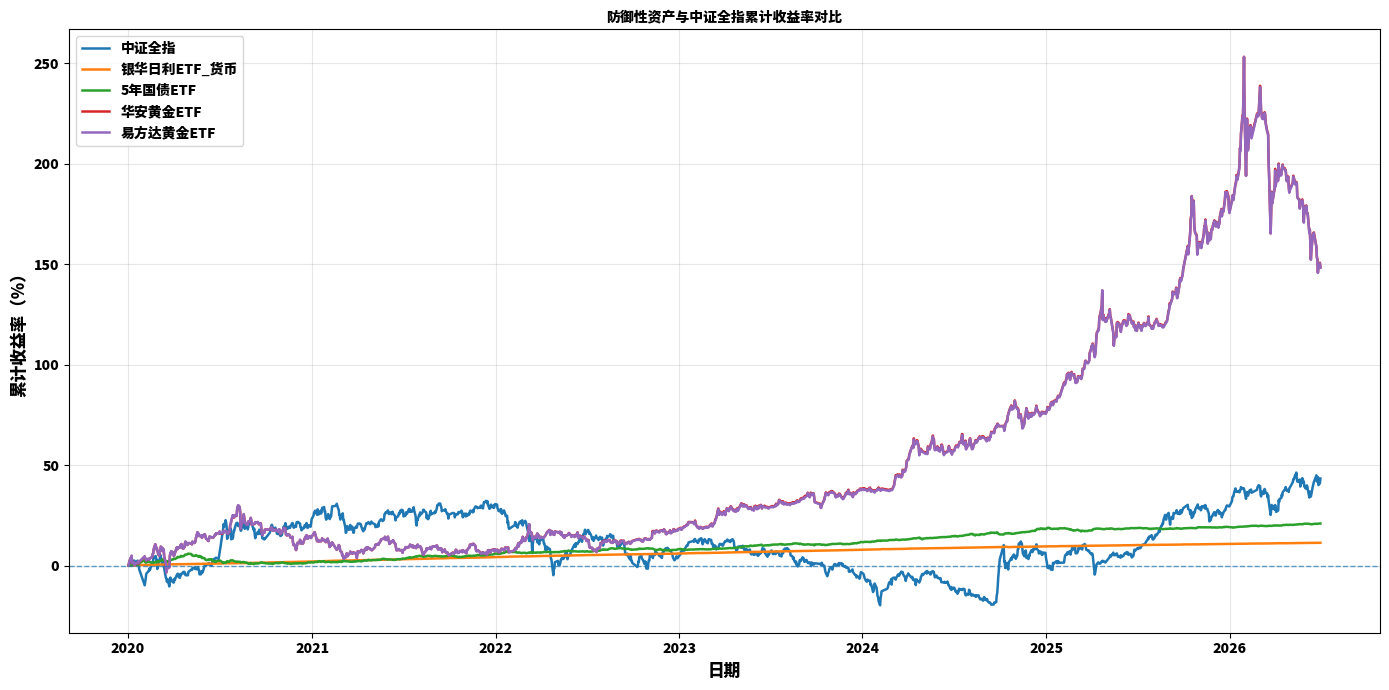

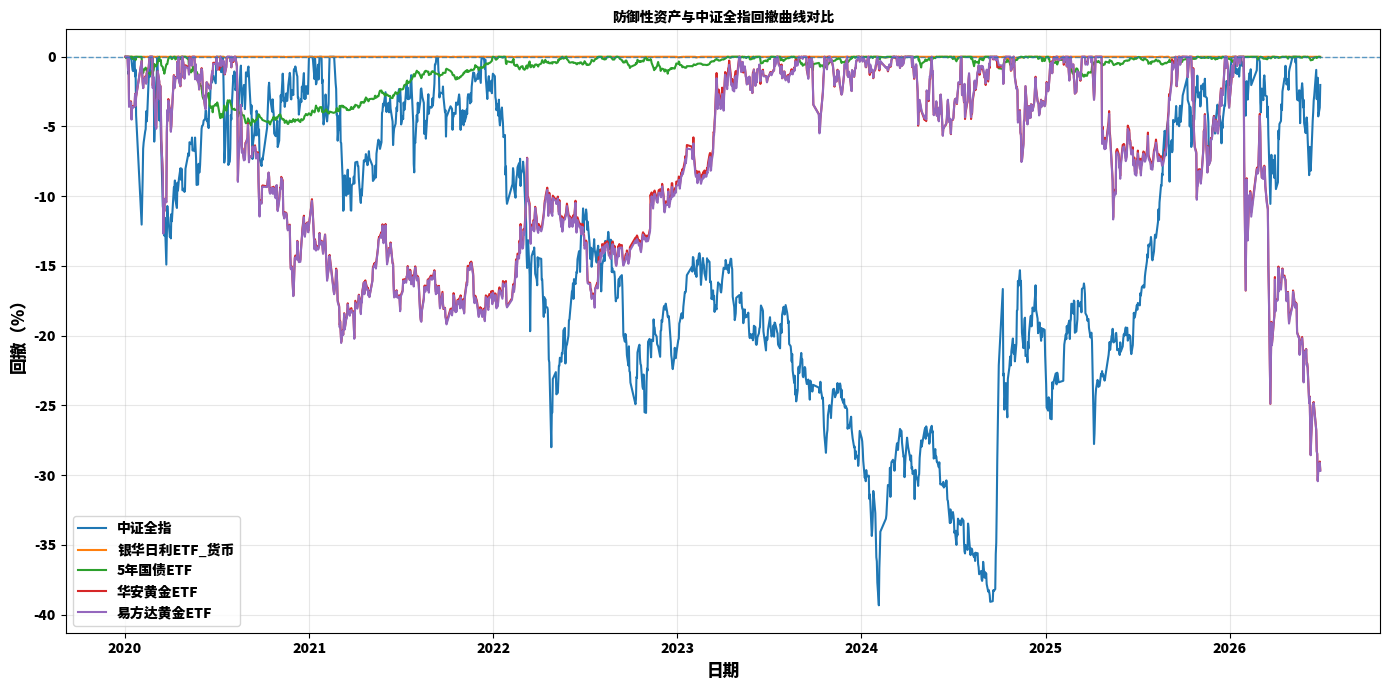

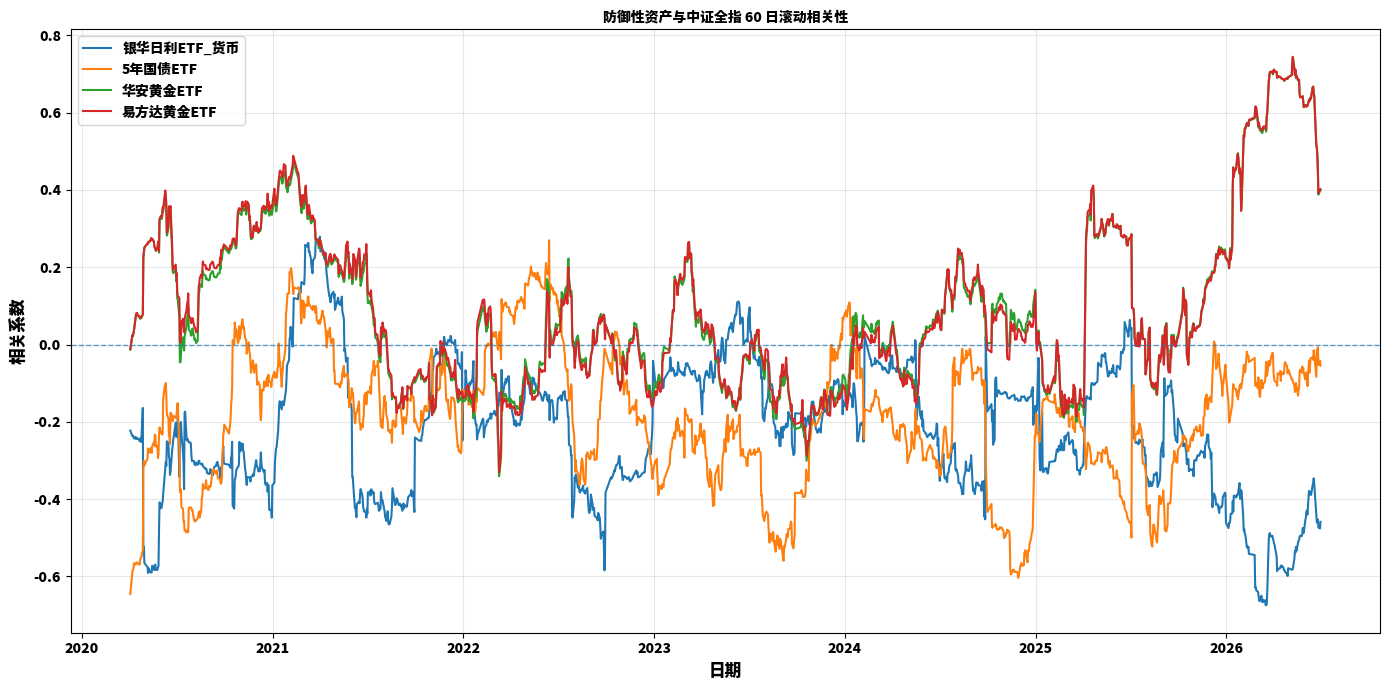


运行完成。主要结果变量：
price_df：对齐后的价格序列
ret_df：日收益率序列
nav_df：归一化净值序列
cum_ret_df：累计收益率序列
drawdown_df：回撤序列
metrics_df：绩效与防御属性指标
corr_matrix：日收益率相关性矩阵
rolling_corr_df：与中证全指的滚动相关性
resolved_info_df：实际读取到的代码和数据表


In [1]:
# ============================================================
# 防御性资产 vs 中证全指：收益率曲线与相关性对比
#
# 目的：
# - 对比货币 ETF、国债 ETF、黄金 ETF 等防御性资产与中证全指的收益率曲线
# - 观察这些资产在中证全指下跌阶段的表现、相关性、回撤与波动
#
# 默认标的：
# - 中证全指：000985.CSI
# - 银华日利：511880.SH / 511880.SHA
# - 5年国债 ETF：511010.SH / 511010.SHA
# - 华安黄金 ETF：518880.SH / 518880.SHA
# - 易方达黄金 ETF：159934.SZ / 159934.SZA
#
# 说明：
# - ETF 行情表在不同 BigQuant 环境中可能不同，本代码会自动尝试多个表。
# - 若某个标的读取失败，会打印失败信息并跳过，不影响其他标的。
# - 图表使用 Matplotlib 输出，并自动设置中文字体。
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2020-01-01"
END_DATE = "2026-06-30"

# 中证全指，用作风险资产代表与相关性基准。
INDEX_NAME = "中证全指"
INDEX_CANDIDATES = ["000985.CSI", "000985.SH", "000985.SHI"]

# 防御性资产候选。
# 每个资产可以配置多个代码后缀候选，代码会自动尝试。
DEFENSIVE_ASSETS = {
    "银华日利ETF_货币": ["511880.SH", "511880.SHA"],
    "5年国债ETF": ["511010.SH", "511010.SHA"],
    "华安黄金ETF": ["518880.SH", "518880.SHA"],
    "易方达黄金ETF": ["159934.SZ", "159934.SZA"],
}

# ETF / 基金行情表候选。不同 BigQuant 环境表名可能不同。
# 常见优先级：cn_fund_bar1d > cn_stock_bar1d。
ETF_TABLE_CANDIDATES = [
    "cn_fund_bar1d",
    "cn_stock_bar1d",
    "cn_etf_bar1d",
    "cn_fund_etf_bar1d",
]

# 是否所有资产从共同可比起点开始画图。
# True：只保留所有成功读取资产都有价格的区间；曲线可比性最好。
# False：每个资产从自己有数据的日期开始，空值用前值填充；样本更长但可比性弱一些。
USE_COMMON_DATES = True

# 相关性滚动窗口。
ROLLING_CORR_WINDOW = 60

# 中文字体路径。若 BigQuant 环境自动识别失败，可手动指定。
CHINESE_FONT_PATH = None

SHOW_PROGRESS = True


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def normalize_price_df(df, name):
    if df is None or df.empty:
        return None
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"])
    df = df.drop_duplicates("date").sort_values("date")
    s = df.set_index("date")["close"].rename(name)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    return s


def query_index_close(index_name, candidates, start_date, end_date):
    last_error = None
    for code in candidates:
        try:
            sql = f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{code}'
            ORDER BY date
            """
            df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
            s = normalize_price_df(df, index_name)
            if s is not None and len(s) > 30:
                print(f"指数读取成功：{index_name} -> {code}")
                return s, code
        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(f"指数读取失败：{index_name}，候选代码={candidates}，最后错误={last_error}")


def query_asset_close(asset_name, code_candidates, start_date, end_date, table_candidates):
    errors = []

    for table in table_candidates:
        for code in code_candidates:
            try:
                sql = f"""
                SELECT
                    date,
                    instrument,
                    close
                FROM {table}
                WHERE instrument = '{code}'
                ORDER BY date
                """
                df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
                s = normalize_price_df(df, asset_name)
                if s is not None and len(s) > 30:
                    print(f"资产读取成功：{asset_name} -> {table}.{code}，数据点={len(s)}")
                    return s, table, code
                errors.append(f"{table}.{code}: 空或数据点不足")
            except Exception as e:
                errors.append(f"{table}.{code}: {repr(e)}")
                continue

    print(f"警告：资产读取失败，已跳过：{asset_name}")
    print("最近错误：")
    for item in errors[-6:]:
        print("  ", item)
    return None, None, None


def calc_max_drawdown(nav):
    nav = nav.dropna()
    if len(nav) < 2:
        return np.nan
    dd = nav / nav.cummax() - 1
    return dd.min()


def calc_drawdown_series(nav):
    return nav / nav.cummax() - 1


def annual_return_from_nav(nav, trading_days=252):
    nav = nav.dropna()
    if len(nav) < 2:
        return np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    return (1 + total_ret) ** (trading_days / (len(nav) - 1)) - 1


def annual_volatility(ret, trading_days=252):
    ret = ret.dropna()
    if len(ret) < 2:
        return np.nan
    return ret.std(ddof=1) * np.sqrt(trading_days)


def sharpe_ratio(ret, trading_days=252):
    ret = ret.dropna()
    if len(ret) < 2:
        return np.nan
    std = ret.std(ddof=1)
    if std == 0 or pd.isna(std):
        return np.nan
    return ret.mean() / std * np.sqrt(trading_days)


def format_pct(x):
    if pd.isna(x):
        return np.nan
    return f"{x * 100:.2f}%"


# ============================================================
# 3. 读取价格数据
# ============================================================

log_progress("正在读取中证全指行情...")
index_close, resolved_index_code = query_index_close(
    INDEX_NAME,
    INDEX_CANDIDATES,
    START_DATE,
    END_DATE,
)

price_series = {INDEX_NAME: index_close}
resolved_info = [
    {
        "资产": INDEX_NAME,
        "类型": "指数",
        "数据表": "cn_stock_index_bar1d",
        "代码": resolved_index_code,
        "起始日期": index_close.index.min().strftime("%Y-%m-%d"),
        "结束日期": index_close.index.max().strftime("%Y-%m-%d"),
        "数据点数": len(index_close),
    }
]

log_progress("正在读取防御性资产行情...")
for asset_name, candidates in DEFENSIVE_ASSETS.items():
    s, table, code = query_asset_close(
        asset_name,
        candidates,
        START_DATE,
        END_DATE,
        ETF_TABLE_CANDIDATES,
    )
    if s is None:
        continue

    price_series[asset_name] = s
    resolved_info.append(
        {
            "资产": asset_name,
            "类型": "ETF / 防御资产",
            "数据表": table,
            "代码": code,
            "起始日期": s.index.min().strftime("%Y-%m-%d"),
            "结束日期": s.index.max().strftime("%Y-%m-%d"),
            "数据点数": len(s),
        }
    )

resolved_info_df = pd.DataFrame(resolved_info)

print("\n========== 实际读取到的资产 ==========")
if display is not None:
    display(resolved_info_df)
else:
    print(resolved_info_df)

if len(price_series) < 2:
    raise RuntimeError("除中证全指外，没有成功读取到任何防御资产。请检查 ETF 代码或行情表。")

# ============================================================
# 4. 对齐价格、计算收益与净值
# ============================================================

# 以中证全指交易日为主索引，ETF 非交易日缺失时前值填充。
price_df = pd.concat(price_series.values(), axis=1).sort_index()
price_df = price_df.reindex(index_close.index).ffill()

# 删除所有资产都不可比的前段空值。
if USE_COMMON_DATES:
    price_df = price_df.dropna(how="any")
else:
    price_df = price_df.dropna(subset=[INDEX_NAME])

# 再次过滤非正价格。
for col in price_df.columns:
    price_df.loc[price_df[col] <= 0, col] = np.nan

if USE_COMMON_DATES:
    price_df = price_df.dropna(how="any")
else:
    price_df = price_df.ffill().dropna(subset=[INDEX_NAME])

ret_df = price_df.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
ret_df = ret_df.dropna(how="all")

nav_df = price_df / price_df.iloc[0]
cum_ret_df = nav_df - 1

drawdown_df = nav_df.apply(calc_drawdown_series)

print("\n========== 对齐后样本区间 ==========")
print(f"起始日期：{price_df.index.min().strftime('%Y-%m-%d')}")
print(f"结束日期：{price_df.index.max().strftime('%Y-%m-%d')}")
print(f"交易日数量：{len(price_df)}")


# ============================================================
# 5. 绩效、相关性与下跌日表现统计
# ============================================================

index_ret = ret_df[INDEX_NAME]
index_down = index_ret < 0
index_big_down = index_ret <= -0.01

metric_rows = []

for col in nav_df.columns:
    nav = nav_df[col]
    ret = ret_df[col]

    common = pd.concat([index_ret, ret], axis=1).dropna()
    common.columns = ["index_ret", "asset_ret"]

    if len(common) > 5:
        corr_all = common["index_ret"].corr(common["asset_ret"])
        corr_down = common.loc[common["index_ret"] < 0, "index_ret"].corr(
            common.loc[common["index_ret"] < 0, "asset_ret"]
        ) if (common["index_ret"] < 0).sum() > 5 else np.nan
        avg_ret_when_index_down = common.loc[common["index_ret"] < 0, "asset_ret"].mean()
        avg_ret_when_index_big_down = common.loc[common["index_ret"] <= -0.01, "asset_ret"].mean()
        positive_rate_when_index_down = (common.loc[common["index_ret"] < 0, "asset_ret"] > 0).mean()
    else:
        corr_all = np.nan
        corr_down = np.nan
        avg_ret_when_index_down = np.nan
        avg_ret_when_index_big_down = np.nan
        positive_rate_when_index_down = np.nan

    metric_rows.append(
        {
            "资产": col,
            "累计收益": format_pct(nav.iloc[-1] / nav.iloc[0] - 1),
            "年化收益": format_pct(annual_return_from_nav(nav)),
            "年化波动率": format_pct(annual_volatility(ret)),
            "夏普比率_无风险利率0": round(sharpe_ratio(ret), 4) if not pd.isna(sharpe_ratio(ret)) else np.nan,
            "最大回撤": format_pct(calc_max_drawdown(nav)),
            "与中证全指日收益相关性": round(corr_all, 4) if not pd.isna(corr_all) else np.nan,
            "中证全指下跌日相关性": round(corr_down, 4) if not pd.isna(corr_down) else np.nan,
            "中证全指下跌日平均收益": format_pct(avg_ret_when_index_down),
            "中证全指跌超1%日平均收益": format_pct(avg_ret_when_index_big_down),
            "中证全指下跌日资产上涨占比": format_pct(positive_rate_when_index_down),
        }
    )

metrics_df = pd.DataFrame(metric_rows)

print("\n========== 防御性资产对比指标 ==========")
if display is not None:
    display(metrics_df)
else:
    print(metrics_df)

# 相关性矩阵。
corr_matrix = ret_df.corr()
print("\n========== 日收益率相关性矩阵 ==========")
if display is not None:
    display(corr_matrix)
else:
    print(corr_matrix)


# ============================================================
# 6. 图表输出：累计收益率、回撤、滚动相关性
# ============================================================

# 图 1：累计收益率曲线。
fig, ax = plt.subplots(figsize=(14, 7))

for col in cum_ret_df.columns:
    ax.plot(cum_ret_df.index, cum_ret_df[col] * 100, linewidth=1.8, label=col)

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("防御性资产与中证全指累计收益率对比", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("累计收益率（%）", fontsize=12, **cn_text_kwargs())
ax.grid(True, alpha=0.3)

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()
set_cn_tick_font(ax)
fig.tight_layout()
plt.show()

# 图 2：最大回撤曲线。
fig, ax = plt.subplots(figsize=(14, 7))

for col in drawdown_df.columns:
    ax.plot(drawdown_df.index, drawdown_df[col] * 100, linewidth=1.5, label=col)

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("防御性资产与中证全指回撤曲线对比", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("回撤（%）", fontsize=12, **cn_text_kwargs())
ax.grid(True, alpha=0.3)

if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()
set_cn_tick_font(ax)
fig.tight_layout()
plt.show()

# 图 3：防御性资产相对中证全指的滚动相关性。
rolling_corr_df = pd.DataFrame(index=ret_df.index)
for col in ret_df.columns:
    if col == INDEX_NAME:
        continue
    rolling_corr_df[col] = ret_df[col].rolling(ROLLING_CORR_WINDOW).corr(ret_df[INDEX_NAME])

if not rolling_corr_df.dropna(how="all").empty:
    fig, ax = plt.subplots(figsize=(14, 7))

    for col in rolling_corr_df.columns:
        ax.plot(rolling_corr_df.index, rolling_corr_df[col], linewidth=1.5, label=col)

    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(f"防御性资产与中证全指 {ROLLING_CORR_WINDOW} 日滚动相关性", fontsize=15, **cn_text_kwargs())
    ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
    ax.set_ylabel("相关系数", fontsize=12, **cn_text_kwargs())
    ax.grid(True, alpha=0.3)

    if CN_FONT is not None:
        ax.legend(prop=CN_FONT)
    else:
        ax.legend()
    set_cn_tick_font(ax)
    fig.tight_layout()
    plt.show()


# ============================================================
# 7. 保留结果变量
# ============================================================

print("\n运行完成。主要结果变量：")
print("price_df：对齐后的价格序列")
print("ret_df：日收益率序列")
print("nav_df：归一化净值序列")
print("cum_ret_df：累计收益率序列")
print("drawdown_df：回撤序列")
print("metrics_df：绩效与防御属性指标")
print("corr_matrix：日收益率相关性矩阵")
print("rolling_corr_df：与中证全指的滚动相关性")
print("resolved_info_df：实际读取到的代码和数据表")


In [ ]:
# ============================================================
# 中证全指 vs 银行板块指数 / 代表性银行股收益关系分析
#
# 输出：
# 1）中证全指、银行板块指数、自建银行等权指数累计收益率曲线
# 2）中证全指与代表性银行股累计收益率曲线
# 3）银行资产相对中证全指的相对净值曲线
# 4）与中证全指的滚动相关性曲线
# 5）统计指标表：累计收益、年化收益、年化波动、最大回撤、相关性、Beta、下跌日表现等
#
# 说明：
# - 银行板块指数会优先尝试读取 BigQuant 中的官方/行业指数候选代码；
# - 如果银行板块指数读取失败，代码会自动构造“银行股等权指数”；
# - 代表性银行股使用大行、股份行、城商行中较有代表性的样本；
# - 代码重点用于判断银行股是否具备防御属性，以及其与中证全指收益率之间的关系。
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2020-01-01"
END_DATE   = "2026-06-30"

# 中证全指。若你的 BigQuant 环境代码后缀不同，可在这里继续添加候选。
CSI_ALL_SHARE_CANDIDATES = [
    "000985.CSI",
    "000985.SH",
    "000985.SHI",
]

# 银行板块指数候选。
# 不同数据源对指数代码支持不同，所以这里使用候选机制；若全部失败，会自动使用自建银行等权指数。
BANK_INDEX_CANDIDATES = [
    ("399986.CSI", "中证银行指数"),
    ("399986.SZ",  "中证银行指数"),
    ("801780.SI",  "申万银行指数"),
    ("801780.CSI", "申万银行指数"),
]

# 代表性银行股。
# 每个股票提供多个后缀候选，以兼容 BigQuant 不同环境中的代码格式。
REPRESENTATIVE_BANK_STOCKS = {
    "工商银行": ["601398.SH", "601398.SHA"],
    "建设银行": ["601939.SH", "601939.SHA"],
    "农业银行": ["601288.SH", "601288.SHA"],
    "中国银行": ["601988.SH", "601988.SHA"],
    "交通银行": ["601328.SH", "601328.SHA"],
    "邮储银行": ["601658.SH", "601658.SHA"],
    "招商银行": ["600036.SH", "600036.SHA"],
    "兴业银行": ["601166.SH", "601166.SHA"],
    "平安银行": ["000001.SZ", "000001.SZA"],
    "宁波银行": ["002142.SZ", "002142.SZA"],
}

# 滚动相关性窗口
ROLLING_CORR_WINDOW = 60

# 是否绘制个股曲线。代表性银行股较多，若图太拥挤可设为 False。
PLOT_INDIVIDUAL_BANK_STOCKS = True

# 中文字体路径。若当前环境中文乱码，可手动指定，如 "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

SHOW_PROGRESS = True


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    for cand in candidate_names:
        for item in fm.fontManager.ttflist:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in fm.fontManager.ttflist:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)
if CN_FONT_NAME is None:
    print("提示：当前环境未检测到中文字体。如果图表中文乱码，请设置 CHINESE_FONT_PATH。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


# ============================================================
# 2. 通用工具函数
# ============================================================

def normalize_price_df(df, value_name="close"):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    df = df.dropna(subset=["date", value_name])
    df = df.drop_duplicates(["date", "instrument"])
    df = df.sort_values(["date", "instrument"])
    return df


def query_index_close_by_candidates(candidates, label, start_date, end_date):
    """
    从指数行情表中按候选代码读取收盘价。
    成功后返回 Series，index=date，name=label。
    """
    index_tables = [
        "cn_stock_index_bar1d",
        "cn_index_bar1d",
        "cn_fund_index_bar1d",
    ]

    errors = []
    for table in index_tables:
        for code in candidates:
            try:
                sql = f"""
                SELECT
                    date,
                    instrument,
                    close
                FROM {table}
                WHERE instrument = '{code}'
                ORDER BY date
                """
                df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
                if df is None or df.empty:
                    errors.append(f"{table} / {code}: 空")
                    continue
                df = normalize_price_df(df)
                if df.empty:
                    errors.append(f"{table} / {code}: 清洗后为空")
                    continue
                s = df.set_index("date")["close"].sort_index()
                s.name = label
                log_progress(f"{label} 使用 {table} / {code}")
                return s, code, table
            except Exception as e:
                errors.append(f"{table} / {code}: {repr(e)}")
                continue

    raise RuntimeError(f"未能读取 {label}。已尝试：\n" + "\n".join(errors[-20:]))


def query_named_index_candidates(index_candidates, start_date, end_date):
    """
    读取带中文名称的指数候选。返回第一个成功读取的指数序列。
    """
    index_tables = [
        "cn_stock_index_bar1d",
        "cn_index_bar1d",
        "cn_fund_index_bar1d",
    ]

    errors = []
    for table in index_tables:
        for code, label in index_candidates:
            try:
                sql = f"""
                SELECT
                    date,
                    instrument,
                    close
                FROM {table}
                WHERE instrument = '{code}'
                ORDER BY date
                """
                df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
                if df is None or df.empty:
                    errors.append(f"{table} / {code}: 空")
                    continue
                df = normalize_price_df(df)
                if df.empty:
                    errors.append(f"{table} / {code}: 清洗后为空")
                    continue
                s = df.set_index("date")["close"].sort_index()
                s.name = label
                log_progress(f"银行板块指数使用 {table} / {code} / {label}")
                return s, code, table, label
            except Exception as e:
                errors.append(f"{table} / {code}: {repr(e)}")
                continue

    log_progress("未能读取官方/行业银行指数候选，将仅使用自建银行等权指数。")
    if SHOW_PROGRESS:
        for item in errors[-8:]:
            print("  ", item)
    return None, None, None, None


def query_stock_close_for_representatives(stock_candidates, start_date, end_date):
    """
    一次性查询代表性银行股候选代码，自动为每个中文名称选择数据最完整的代码。
    """
    all_codes = sorted({code for codes in stock_candidates.values() for code in codes})
    code_sql = ", ".join([f"'{x}'" for x in all_codes])

    sql = f"""
    SELECT
        date,
        instrument,
        close,
        name
    FROM cn_stock_bar1d
    WHERE instrument IN ({code_sql})
    ORDER BY date, instrument
    """

    df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
    if df is None or df.empty:
        raise RuntimeError("未能读取代表性银行股日行情。请检查股票代码后缀是否与当前环境一致。")

    df = normalize_price_df(df)
    result = {}
    chosen_codes = {}

    for cn_name, codes in stock_candidates.items():
        sub = df[df["instrument"].isin(codes)].copy()
        if sub.empty:
            print(f"提示：{cn_name} 未读取到行情，已跳过。候选代码：{codes}")
            continue

        # 选择记录数最多的代码，避免 .SH / .SHA 同时存在时重复。
        count_by_code = sub.groupby("instrument")["date"].count().sort_values(ascending=False)
        chosen = count_by_code.index[0]
        s = sub[sub["instrument"] == chosen].set_index("date")["close"].sort_index()
        s.name = cn_name
        result[cn_name] = s
        chosen_codes[cn_name] = chosen

    if len(result) == 0:
        raise RuntimeError("代表性银行股全部读取失败。")

    log_progress("代表性银行股读取完成：")
    for k, v in chosen_codes.items():
        log_progress(f"  {k}: {v}")

    return pd.DataFrame(result).sort_index(), chosen_codes


def query_bank_equal_weight_index(start_date, end_date):
    """
    构造银行股等权指数。
    优先尝试申万2021一级行业代码 740000，其次尝试中文行业字段。
    """
    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1 = 740000",
            """
            SELECT
                b.date,
                b.instrument,
                b.close,
                b.name,
                p.sw2021_level1 AS industry
            FROM cn_stock_bar1d AS b
            JOIN cn_stock_prefactors AS p
                USING(date, instrument)
            WHERE CAST(p.sw2021_level1 AS VARCHAR) = '740000'
            ORDER BY b.date, b.instrument
            """
        ),
        (
            "cn_stock_prefactors.industry = 银行",
            """
            SELECT
                b.date,
                b.instrument,
                b.close,
                b.name,
                p.industry AS industry
            FROM cn_stock_bar1d AS b
            JOIN cn_stock_prefactors AS p
                USING(date, instrument)
            WHERE CAST(p.industry AS VARCHAR) = '银行'
            ORDER BY b.date, b.instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1 = 银行",
            """
            SELECT
                b.date,
                b.instrument,
                b.close,
                b.name,
                p.industry_level1 AS industry
            FROM cn_stock_bar1d AS b
            JOIN cn_stock_prefactors AS p
                USING(date, instrument)
            WHERE CAST(p.industry_level1 AS VARCHAR) = '银行'
            ORDER BY b.date, b.instrument
            """
        ),
        (
            "cn_stock_factors_industry.cs_level1_name = 银行",
            """
            SELECT
                b.date,
                b.instrument,
                b.close,
                b.name,
                ind.cs_level1_name AS industry
            FROM cn_stock_bar1d AS b
            JOIN cn_stock_factors_industry AS ind
                USING(date, instrument)
            WHERE CAST(ind.cs_level1_name AS VARCHAR) = '银行'
            ORDER BY b.date, b.instrument
            """
        ),
    ]

    errors = []
    for source_name, sql in candidate_sqls:
        try:
            df = dai.query(sql, filters={"date": [start_date, end_date]}).df()
            if df is None or df.empty:
                errors.append(f"{source_name}: 空")
                continue

            df = normalize_price_df(df)
            # 剔除 ST / *ST
            if "name" in df.columns:
                df = df[~df["name"].astype(str).str.contains("ST", na=False)].copy()

            if df.empty:
                errors.append(f"{source_name}: 剔除 ST 后为空")
                continue

            close_wide = df.pivot(index="date", columns="instrument", values="close").sort_index()
            ret_wide = close_wide.pct_change(fill_method=None)

            # 每日等权，至少需要 5 只银行股有有效收益。
            bank_ret = ret_wide.mean(axis=1, skipna=True)
            bank_count = ret_wide.notna().sum(axis=1)
            bank_ret = bank_ret.where(bank_count >= 5)
            bank_ret.name = "自建银行股等权指数"

            bank_nav = (1 + bank_ret.fillna(0)).cumprod()
            bank_nav.name = "自建银行股等权指数净值"

            log_progress(f"自建银行等权指数使用：{source_name}")
            log_progress(f"银行股样本数量：{close_wide.shape[1]}")
            return bank_ret, bank_nav, bank_count, source_name, sorted(close_wide.columns.tolist())

        except Exception as e:
            errors.append(f"{source_name}: {repr(e)}")
            continue

    raise RuntimeError("未能构造银行股等权指数。已尝试：\n" + "\n".join(errors[-20:]))


def close_to_ret(close_df_or_series):
    return close_df_or_series.pct_change(fill_method=None)


def ret_to_cumret(ret):
    return (1 + ret.fillna(0)).cumprod() - 1


def calc_max_drawdown(nav):
    nav = nav.dropna()
    if len(nav) == 0:
        return np.nan
    dd = nav / nav.cummax() - 1
    return dd.min()


def calc_metrics(ret_df, benchmark_col="中证全指"):
    rows = []
    if benchmark_col not in ret_df.columns:
        raise ValueError(f"benchmark_col {benchmark_col} 不在 ret_df 中。")

    benchmark_ret = ret_df[benchmark_col]

    for col in ret_df.columns:
        tmp = pd.concat([ret_df[col], benchmark_ret], axis=1, keys=["asset", "bench"]).dropna()
        if tmp.empty:
            continue

        r = tmp["asset"]
        b = tmp["bench"]
        nav = (1 + r).cumprod()
        total_ret = nav.iloc[-1] - 1
        ann_ret = (1 + total_ret) ** (252 / len(r)) - 1 if len(r) > 1 else np.nan
        ann_vol = r.std(ddof=1) * np.sqrt(252) if len(r) > 1 else np.nan
        sharpe = ann_ret / ann_vol if ann_vol and ann_vol != 0 else np.nan
        max_dd = calc_max_drawdown(nav)

        corr_all = r.corr(b)
        beta = r.cov(b) / b.var(ddof=1) if b.var(ddof=1) != 0 else np.nan

        down = b < 0
        down_1pct = b < -0.01

        rows.append({
            "资产": col,
            "样本天数": int(len(r)),
            "累计收益率": total_ret,
            "年化收益率": ann_ret,
            "年化波动率": ann_vol,
            "夏普比率_无风险利率0": sharpe,
            "最大回撤": max_dd,
            "与中证全指日收益相关性": corr_all,
            "Beta_相对中证全指": beta,
            "中证全指下跌日平均收益": r[down].mean() if down.sum() else np.nan,
            "中证全指下跌日上涨占比": (r[down] > 0).mean() if down.sum() else np.nan,
            "中证全指跌超1%日平均收益": r[down_1pct].mean() if down_1pct.sum() else np.nan,
            "中证全指跌超1%日上涨占比": (r[down_1pct] > 0).mean() if down_1pct.sum() else np.nan,
        })

    metrics = pd.DataFrame(rows)
    return metrics


def format_metrics(metrics):
    fmt = metrics.copy()
    pct_cols = [
        "累计收益率", "年化收益率", "年化波动率", "最大回撤",
        "中证全指下跌日平均收益", "中证全指下跌日上涨占比",
        "中证全指跌超1%日平均收益", "中证全指跌超1%日上涨占比",
    ]
    for c in pct_cols:
        if c in fmt.columns:
            fmt[c] = fmt[c].map(lambda x: f"{x * 100:.2f}%" if pd.notna(x) else np.nan)

    num_cols = ["夏普比率_无风险利率0", "与中证全指日收益相关性", "Beta_相对中证全指"]
    for c in num_cols:
        if c in fmt.columns:
            fmt[c] = fmt[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else np.nan)

    return fmt


# ============================================================
# 3. 读取数据
# ============================================================

log_progress("正在读取中证全指...")
csi_close, csi_code_used, csi_table_used = query_index_close_by_candidates(
    CSI_ALL_SHARE_CANDIDATES,
    "中证全指",
    START_DATE,
    END_DATE,
)

log_progress("正在读取银行板块指数候选...")
bank_index_close, bank_index_code_used, bank_index_table_used, bank_index_label_used = query_named_index_candidates(
    BANK_INDEX_CANDIDATES,
    START_DATE,
    END_DATE,
)

log_progress("正在构造自建银行股等权指数...")
bank_ew_ret, bank_ew_nav, bank_ew_count, bank_ew_source, bank_universe = query_bank_equal_weight_index(
    START_DATE,
    END_DATE,
)

log_progress("正在读取代表性银行股...")
bank_stock_close, chosen_stock_codes = query_stock_close_for_representatives(
    REPRESENTATIVE_BANK_STOCKS,
    START_DATE,
    END_DATE,
)


# ============================================================
# 4. 构造收益率矩阵
# ============================================================

# 收盘价类资产
close_dict = {"中证全指": csi_close}
if bank_index_close is not None:
    close_dict[bank_index_label_used] = bank_index_close

close_df = pd.DataFrame(close_dict).sort_index()
stock_close_df = bank_stock_close.sort_index()

price_ret_df = close_df.pct_change(fill_method=None)
stock_ret_df = stock_close_df.pct_change(fill_method=None)

# 自建银行等权指数已经是收益率序列
bank_ew_ret = bank_ew_ret.reindex(price_ret_df.index.union(bank_ew_ret.index)).sort_index()

# 汇总收益率：指数 + 自建银行等权 + 代表性个股
ret_df = pd.concat(
    [
        price_ret_df,
        bank_ew_ret.rename("自建银行股等权指数"),
        stock_ret_df,
    ],
    axis=1,
).sort_index()

# 对齐到 START_DATE ~ END_DATE，并去掉全空行
ret_df = ret_df[(ret_df.index >= pd.Timestamp(START_DATE)) & (ret_df.index <= pd.Timestamp(END_DATE))]
ret_df = ret_df.dropna(how="all")

# 累计收益率
cumret_df = ret_to_cumret(ret_df)


# ============================================================
# 5. 输出统计指标
# ============================================================

metrics_df = calc_metrics(ret_df, benchmark_col="中证全指")
metrics_show = format_metrics(metrics_df)

print("\n========== 数据来源 ==========")
print(f"中证全指：{csi_table_used} / {csi_code_used}")
if bank_index_close is not None:
    print(f"银行板块指数：{bank_index_table_used} / {bank_index_code_used} / {bank_index_label_used}")
else:
    print("银行板块指数：未读取到官方/行业指数候选，仅使用自建银行股等权指数")
print(f"自建银行等权指数来源：{bank_ew_source}")
print(f"自建银行等权指数成分股票数量：{len(bank_universe)}")
print("代表性银行股代码：")
for name, code in chosen_stock_codes.items():
    print(f"  {name}: {code}")

print("\n========== 指标表 ==========")
if display is not None:
    display(metrics_show)
else:
    print(metrics_show)


# ============================================================
# 6. 图表 1：中证全指 vs 银行板块指数 / 自建银行等权指数
# ============================================================

plot_cols_1 = ["中证全指"]
if bank_index_close is not None and bank_index_label_used in cumret_df.columns:
    plot_cols_1.append(bank_index_label_used)
plot_cols_1.append("自建银行股等权指数")
plot_cols_1 = [c for c in plot_cols_1 if c in cumret_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for col in plot_cols_1:
    ax.plot(cumret_df.index, cumret_df[col], label=col, linewidth=1.8)

ax.set_title("中证全指 vs 银行板块指数累计收益率", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("累计收益率", fontsize=12, **cn_text_kwargs())
ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}%")
ax.grid(True, alpha=0.3)
if CN_FONT is not None:
    ax.legend(prop=CN_FONT)
else:
    ax.legend()
set_cn_tick_font(ax)
fig.tight_layout()
plt.show()


# ============================================================
# 7. 图表 2：代表性银行股与中证全指累计收益率对比
# ============================================================

if PLOT_INDIVIDUAL_BANK_STOCKS:
    plot_cols_2 = ["中证全指"] + [c for c in REPRESENTATIVE_BANK_STOCKS.keys() if c in cumret_df.columns]
    plot_cols_2 = [c for c in plot_cols_2 if c in cumret_df.columns]

    fig, ax = plt.subplots(figsize=(14, 7))
    for col in plot_cols_2:
        line_width = 2.4 if col == "中证全指" else 1.2
        alpha = 1.0 if col == "中证全指" else 0.85
        ax.plot(cumret_df.index, cumret_df[col], label=col, linewidth=line_width, alpha=alpha)

    ax.set_title("中证全指 vs 代表性银行股累计收益率", fontsize=15, **cn_text_kwargs())
    ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
    ax.set_ylabel("累计收益率", fontsize=12, **cn_text_kwargs())
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}%")
    ax.grid(True, alpha=0.3)
    if CN_FONT is not None:
        ax.legend(prop=CN_FONT, ncol=2)
    else:
        ax.legend(ncol=2)
    set_cn_tick_font(ax)
    fig.tight_layout()
    plt.show()


# ============================================================
# 8. 图表 3：银行资产相对中证全指的相对净值
# ============================================================

nav_df = (1 + ret_df.fillna(0)).cumprod()
relative_nav_df = pd.DataFrame(index=nav_df.index)
for col in nav_df.columns:
    if col == "中证全指":
        continue
    if "中证全指" in nav_df.columns:
        relative_nav_df[col] = nav_df[col] / nav_df["中证全指"]

# 为避免图过于拥挤，个股只画代表性股票 + 银行指数。
relative_cols = []
if bank_index_close is not None and bank_index_label_used in relative_nav_df.columns:
    relative_cols.append(bank_index_label_used)
relative_cols.append("自建银行股等权指数")
for c in ["工商银行", "建设银行", "招商银行", "兴业银行", "平安银行", "宁波银行"]:
    if c in relative_nav_df.columns:
        relative_cols.append(c)
relative_cols = [c for c in relative_cols if c in relative_nav_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for col in relative_cols:
    ax.plot(relative_nav_df.index, relative_nav_df[col], label=col, linewidth=1.5)

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_title("银行资产相对中证全指的相对净值", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("相对净值", fontsize=12, **cn_text_kwargs())
ax.grid(True, alpha=0.3)
if CN_FONT is not None:
    ax.legend(prop=CN_FONT, ncol=2)
else:
    ax.legend(ncol=2)
set_cn_tick_font(ax)
fig.tight_layout()
plt.show()


# ============================================================
# 9. 图表 4：与中证全指的滚动相关性
# ============================================================

rolling_corr_df = pd.DataFrame(index=ret_df.index)
for col in ret_df.columns:
    if col == "中证全指":
        continue
    rolling_corr_df[col] = ret_df[col].rolling(ROLLING_CORR_WINDOW).corr(ret_df["中证全指"])

rolling_cols = []
if bank_index_close is not None and bank_index_label_used in rolling_corr_df.columns:
    rolling_cols.append(bank_index_label_used)
rolling_cols.append("自建银行股等权指数")
for c in ["工商银行", "建设银行", "招商银行", "兴业银行", "平安银行", "宁波银行"]:
    if c in rolling_corr_df.columns:
        rolling_cols.append(c)
rolling_cols = [c for c in rolling_cols if c in rolling_corr_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for col in rolling_cols:
    ax.plot(rolling_corr_df.index, rolling_corr_df[col], label=col, linewidth=1.5)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(f"银行资产与中证全指的 {ROLLING_CORR_WINDOW} 日滚动相关性", fontsize=15, **cn_text_kwargs())
ax.set_xlabel("日期", fontsize=12, **cn_text_kwargs())
ax.set_ylabel("滚动相关性", fontsize=12, **cn_text_kwargs())
ax.set_ylim(-1, 1)
ax.grid(True, alpha=0.3)
if CN_FONT is not None:
    ax.legend(prop=CN_FONT, ncol=2)
else:
    ax.legend(ncol=2)
set_cn_tick_font(ax)
fig.tight_layout()
plt.show()


# ============================================================
# 10. 结果变量说明
# ============================================================

print("\n运行完成。主要结果变量：")
print("ret_df：所有资产日收益率")
print("cumret_df：所有资产累计收益率")
print("metrics_df：原始指标表")
print("metrics_show：格式化后的指标表")
print("relative_nav_df：银行资产相对中证全指的相对净值")
print("rolling_corr_df：银行资产与中证全指的滚动相关性")
print("bank_universe：自建银行等权指数使用的银行股列表")
print("chosen_stock_codes：代表性银行股最终使用的代码")


### 防御性策略构建

中证全指 >= 30 日均线：
    因子股票池仓位 = 98%
    工商银行、中国银行、交通银行仓位 = 0%

中证全指 < 30 日均线：
    因子股票池仓位 = 10%
    工商银行、中国银行、交通银行合计仓位 = 88%
    三只银行股等权，各约 29.33%

In [1]:
# ============================================================
# id2_std_3m 行业 + 市值中性化因子：市值前三组联合选股 BigTrader v30 原生回测
#
# 策略设定：
# - 股票池：全市场 A 股，剔除 ST / *ST
# - 因子：id2_std_3m，近 3 个月个股收益对市场、规模、BP 三因子回归残差标准差
# - 因子处理：行业 + 市值中性化
# - 市值分组：每个调仓截面按 total_market_cap 从小到大分为 10 组
#       第 1 组 = 最小市值 10%
#       第 10 组 = 最大市值 10%
# - 选股方式：只使用第 1~3 组；每组内部选中性化后因子值最低的 5%
# - 组合权重：
#       风险开启：三组入选股票合并后整体等权，股票目标总仓位 0.98
#       风险关闭：股票策略目标总仓位降至 0.10，释放仓位等权配置工商银行、中国银行、交通银行
# - 调仓：每 30 个交易日调仓一次，因子日后第 1 个交易日开盘买入；趋势状态变化时只调整仓位不换股
# - 回测：单次调用 BigQuant / BigTrader 原生 M.bigtrader.v30 回测引擎
#
# 交易约束：
# - 剔除 ST / *ST
# - 停牌 / 无成交不可买卖
# - 开盘涨停不可买
# - 开盘跌停不可卖
# - 买入万三，卖出千一三，最低 5 元
#
# 内存优化要点：
# - 不再构造 open/amount/volume/buyable/sellable 的宽表，只保留 close、ret、mv、pb 宽表
# - 只在因子截面日期合并市值与行业，不使用全量 mv_wide.stack()
# - 选股信号生成后主动释放行情宽表、因子中间表等大对象
# - 只运行第 1~3 组联合策略的一次 BigTrader 回测，避免十组对象累计占用内存
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import os
import dai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from bigmodule import M
from bigtrader.finance.commission import PerOrder

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# 0. 参数区
# ============================================================

START_DATE = "2022-01-01"
END_DATE   = "2026-06-30"

LOOKBACK_DAYS = 63       # 近3个月，约63个交易日
HOLD_DAYS = 30           # 持仓30个交易日
REBALANCE_DAYS = 30      # 每30个交易日调仓一次
BUY_DELAY_DAYS = 1       # 因子日后第1个交易日交易，避免同日未来函数

NUM_SIZE_GROUPS = 10     # 市值十组
SELECT_PCT = 0.05        # 每个目标市值组内部选因子值最低的5%
SELECT_SIZE_GROUPS = [1, 2, 3]  # 使用市值最小的前三组
MIN_OBS_TS = 40          # 单只股票时间序列回归最少观测数
MIN_CS_N = 200           # 每个横截面最少股票数
MIN_INDUSTRY_STOCKS = 5  # 单个行业最少股票数，太少的行业归入 Other

FACTOR_SIGN = 1          # 保持原始 id2_std_3m 方向，策略直接选最低值
MV_FIELD = "total_market_cap"

# total_market_cap 单位换算
# 如果 BigQuant 中 total_market_cap 是“元”，则 1e8 换算为“亿元”
# 如果你的字段已经是“亿元”，改为 1
MARKET_CAP_UNIT_DIVISOR = 1e8

# 市场收益率：用于 id2_std_3m 三因子回归中的市场因子
USE_INDEX_MARKET_RET = True
INDEX_CODE = "000985.CSI"

# BigTrader v30 原生回测参数
CAPITAL_BASE = 1_000_000
BENCHMARK = "沪深300指数"

# 交易成本
BUY_COST = 0.0003        # 买入万3
SELL_COST = 0.0013       # 卖出千1.3
MIN_COST = 5             # 最低5元

# 成交量限制，BigTrader v30 使用
VOLUME_LIMIT = 0.025

# 买卖价格字段
ORDER_PRICE_FIELD_BUY = "open"
ORDER_PRICE_FIELD_SELL = "open"

# 趋势向上时目标仓位使用比例，留少量现金避免费用导致下单失败
TARGET_GROSS_EXPOSURE = 0.98

# ============================================================
# 指数趋势过滤参数
# ============================================================

USE_TREND_FILTER = True

# 趋势过滤使用的指数。这里按你的要求使用中证全指。
TREND_INDEX_CODE = "000985.CSI"

# 均线窗口，可以自行调整。例如 20、30、60。
TREND_MA_WINDOW = 30

# 为避免未来函数，开盘调仓时默认使用“上一交易日”的指数收盘价与均线判断风险状态。
# True：t 日下单使用 t-1 日趋势状态；False：使用 t 日收盘状态，会产生未来函数风险，不建议。
TREND_USE_PREVIOUS_TRADING_DAY = True

# 中证全指在均线之上/之下时的股票策略目标仓位。
# 风险开启：股票策略 98%，银行防御资产 0%；
# 风险关闭：股票策略 10%，释放出的 88% 等权配置到银行防御资产。
RISK_ON_STOCK_EXPOSURE = 0.98
RISK_OFF_STOCK_EXPOSURE = 0.10

RISK_ON_DEFENSIVE_EXPOSURE = 0.00
RISK_OFF_DEFENSIVE_EXPOSURE = 0.88

# 防御资产：工商银行、中国银行、交通银行。
# BigTrader v30 通常使用 .SH/.SZ 后缀；若你的环境使用 .SHA/.SZA，to_bigtrader_instrument 会做兼容转换。
DEFENSIVE_BANK_ASSETS = {
    "601398.SH": "工商银行",
    "601988.SH": "中国银行",
    "601328.SH": "交通银行",
}

# 均线尚未形成时的默认仓位。由于 QUERY_START 已经向前取 220 天，正式回测期通常不会触发。
TREND_DEFAULT_STOCK_EXPOSURE = RISK_ON_STOCK_EXPOSURE
TREND_DEFAULT_DEFENSIVE_EXPOSURE = RISK_ON_DEFENSIVE_EXPOSURE

# 为了兼容前面生成初始信号时的字段名，保持这个变量。
TARGET_GROSS_EXPOSURE = RISK_ON_STOCK_EXPOSURE

# 是否输出趋势过滤状态统计。
SHOW_TREND_FILTER_SUMMARY = True

# 是否展示 BigTrader 原生交互式回测图。
# 若页面占位太大或内存紧张，可以设为 False，但回测仍使用原生引擎。
PLOT_CHARTS = True

SHOW_PROGRESS = True

# 中文字体路径。若 BigQuant 环境没有自动识别中文字体，可手动填入字体路径。
# 例如：CHINESE_FONT_PATH = "/home/ai/.fonts/SimHei.ttf"
CHINESE_FONT_PATH = None

# 行业数据 SQL。自动读取失败时，手动填入，要求返回 date, instrument, industry 三列
CUSTOM_INDUSTRY_SQL = None

# 查询数据向前多取一段，保证计算3个月回看窗口
QUERY_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=220)).strftime("%Y-%m-%d")
QUERY_END = END_DATE


# ============================================================
# 1. 中文字体设置
# ============================================================

def setup_chinese_font(font_path=None):
    candidate_names = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK TC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "WenQuanYi Micro Hei",
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
    ]

    if font_path is not None and os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name
        except Exception:
            pass

    font_items = fm.fontManager.ttflist

    for cand in candidate_names:
        for item in font_items:
            if cand.lower() in item.name.lower():
                font_prop = fm.FontProperties(fname=item.fname)
                font_name = font_prop.get_name()
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                return font_prop, font_name

    for item in font_items:
        fname_lower = item.fname.lower()
        if any(key in fname_lower for key in [
            "noto", "sourcehan", "simhei", "msyh", "wqy",
            "wenquanyi", "pingfang", "heiti"
        ]):
            font_prop = fm.FontProperties(fname=item.fname)
            font_name = font_prop.get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_prop, font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None, None


CN_FONT, CN_FONT_NAME = setup_chinese_font(CHINESE_FONT_PATH)

if CN_FONT_NAME is None:
    print("提示：当前环境未检测到可用中文字体。如果图表中文仍显示为方框，请在 CHINESE_FONT_PATH 中指定中文字体文件路径。")
else:
    print(f"中文字体设置成功：{CN_FONT_NAME}")


def cn_text_kwargs():
    return {"fontproperties": CN_FONT} if CN_FONT is not None else {}


def set_cn_tick_font(ax):
    if CN_FONT is None:
        return
    for label in ax.get_xticklabels():
        label.set_fontproperties(CN_FONT)
    for label in ax.get_yticklabels():
        label.set_fontproperties(CN_FONT)


def build_trend_allocation_df(all_dates, query_start, query_end):
    """
    构造中证全指趋势过滤后的股票仓位与银行防御仓位序列。

    规则：
    - 指数收盘价 >= N 日均线：
        股票策略仓位 = RISK_ON_STOCK_EXPOSURE；
        银行防御仓位 = RISK_ON_DEFENSIVE_EXPOSURE；
    - 指数收盘价 <  N 日均线：
        股票策略仓位 = RISK_OFF_STOCK_EXPOSURE；
        银行防御仓位 = RISK_OFF_DEFENSIVE_EXPOSURE；
    - 为避免未来函数，默认 t 日开盘交易使用上一交易日收盘后可观察到的趋势状态。
    """
    all_dates = pd.DatetimeIndex(all_dates)

    if not USE_TREND_FILTER:
        return pd.DataFrame(
            {
                "stock_exposure": float(TARGET_GROSS_EXPOSURE),
                "defensive_exposure": 0.0,
                "risk_on": True,
            },
            index=all_dates,
        )

    idx = dai.query(
        f"""
        SELECT
            date,
            instrument,
            close
        FROM cn_stock_index_bar1d
        WHERE instrument = '{TREND_INDEX_CODE}'
        ORDER BY date
        """,
        filters={"date": [query_start, query_end]}
    ).df()

    if idx is None or idx.empty:
        raise RuntimeError(f"趋势过滤指数 {TREND_INDEX_CODE} 数据为空，无法构造指数趋势过滤信号。")

    idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
    idx = idx.drop_duplicates("date").sort_values("date")
    idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

    close = idx.set_index("date")["close"].reindex(all_dates).ffill()
    ma = close.rolling(window=TREND_MA_WINDOW, min_periods=TREND_MA_WINDOW).mean()

    risk_on_raw = (close >= ma)
    # 均线未形成时，不启用防御切换，默认风险开启。
    risk_on_raw = risk_on_raw.where(ma.notna(), True)

    stock_raw = pd.Series(
        np.where(risk_on_raw, RISK_ON_STOCK_EXPOSURE, RISK_OFF_STOCK_EXPOSURE),
        index=all_dates,
        dtype="float32",
        name="stock_exposure_raw",
    )

    defensive_raw = pd.Series(
        np.where(risk_on_raw, RISK_ON_DEFENSIVE_EXPOSURE, RISK_OFF_DEFENSIVE_EXPOSURE),
        index=all_dates,
        dtype="float32",
        name="defensive_exposure_raw",
    )

    if TREND_USE_PREVIOUS_TRADING_DAY:
        stock_exposure = stock_raw.shift(1).fillna(float(TREND_DEFAULT_STOCK_EXPOSURE))
        defensive_exposure = defensive_raw.shift(1).fillna(float(TREND_DEFAULT_DEFENSIVE_EXPOSURE))
        risk_on = risk_on_raw.shift(1).fillna(True).astype(bool)
    else:
        stock_exposure = stock_raw.fillna(float(TREND_DEFAULT_STOCK_EXPOSURE))
        defensive_exposure = defensive_raw.fillna(float(TREND_DEFAULT_DEFENSIVE_EXPOSURE))
        risk_on = risk_on_raw.fillna(True).astype(bool)

    allocation_df = pd.DataFrame(
        {
            "stock_exposure": stock_exposure.astype("float32"),
            "defensive_exposure": defensive_exposure.astype("float32"),
            "risk_on": risk_on.astype(bool),
        },
        index=all_dates,
    )

    return allocation_df



# ============================================================
# 2. 工具函数
# ============================================================

def log_progress(msg):
    if SHOW_PROGRESS:
        print(msg)


def downcast_float_columns(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
    return df


def ols_resid_std(y, X, min_obs=40):
    """
    计算 y 对 X 多元线性回归的残差标准差。
    逻辑与原版一致：使用 np.linalg.lstsq，残差标准差按 ddof=1 计算。
    """
    valid = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yv = y[valid]
    Xv = X[valid]

    if len(yv) < min_obs:
        return np.nan

    Xv = np.column_stack([np.ones(len(Xv)), Xv])

    try:
        beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
        resid = yv - Xv @ beta
        return np.std(resid, ddof=1)
    except Exception:
        return np.nan


def load_industry_data(query_start, query_end, keep_dates=None):
    """
    自动读取行业数据。
    keep_dates: 若提供，则只保留这些日期，减少后续内存占用。
    """
    def _post_process(industry):
        industry["date"] = pd.to_datetime(industry["date"]).dt.normalize()
        industry = industry[["date", "instrument", "industry"]].copy()
        industry = industry.dropna(subset=["date", "instrument", "industry"])
        industry["industry"] = industry["industry"].astype(str)
        if keep_dates is not None:
            industry = industry[industry["date"].isin(keep_dates)].copy()
        industry = industry.drop_duplicates(["date", "instrument"])
        return industry

    if CUSTOM_INDUSTRY_SQL is not None:
        industry = dai.query(
            CUSTOM_INDUSTRY_SQL,
            filters={"date": [query_start, query_end]}
        ).df()
        return _post_process(industry), "CUSTOM_INDUSTRY_SQL"

    candidate_sqls = [
        (
            "cn_stock_prefactors.sw2021_level1",
            """
            SELECT
                date,
                instrument,
                sw2021_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.sw_level1",
            """
            SELECT
                date,
                instrument,
                sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_sw_level1",
            """
            SELECT
                date,
                instrument,
                industry_sw_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry_level1",
            """
            SELECT
                date,
                instrument,
                industry_level1 AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_prefactors.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_prefactors
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry_name",
            """
            SELECT
                date,
                instrument,
                industry_name AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
        (
            "cn_stock_industry_component.industry",
            """
            SELECT
                date,
                instrument,
                industry AS industry
            FROM cn_stock_industry_component
            ORDER BY date, instrument
            """
        ),
    ]

    last_error = None

    for source_name, sql in candidate_sqls:
        try:
            industry = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if industry is None or industry.empty:
                continue

            if not {"date", "instrument", "industry"}.issubset(industry.columns):
                continue

            industry = _post_process(industry)
            if industry.empty:
                continue

            return industry, source_name

        except Exception as e:
            last_error = e
            continue

    raise RuntimeError(
        "未能自动读取行业字段。请在参数区设置 CUSTOM_INDUSTRY_SQL，"
        "并确保查询结果包含 date, instrument, industry 三列。"
        f"\n最后一次错误信息：{last_error}"
    )


def industry_size_neutralize_one_date(
    g,
    factor_col="factor_raw_signed",
    mv_col="total_market_cap",
    industry_col="industry"
):
    """
    横截面回归中性化：factor ~ log(total_market_cap) + industry_dummies。
    返回残差。
    """
    g = g.copy()

    y = g[factor_col].replace([np.inf, -np.inf], np.nan)
    mv = g[mv_col].replace([np.inf, -np.inf], np.nan)
    ind = g[industry_col]

    valid = y.notna() & mv.notna() & (mv > 0) & ind.notna()
    residual = pd.Series(np.nan, index=g.index, dtype="float32")

    if valid.sum() < MIN_CS_N:
        return residual

    sub = g.loc[valid, [factor_col, mv_col, industry_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub[sub[mv_col] > 0].copy()

    if len(sub) < MIN_CS_N:
        return residual

    industry_counts = sub[industry_col].value_counts()
    small_industries = industry_counts[industry_counts < MIN_INDUSTRY_STOCKS].index

    sub[industry_col] = sub[industry_col].where(
        ~sub[industry_col].isin(small_industries),
        "Other"
    )

    yv = sub[factor_col].to_numpy(dtype="float64", copy=False)
    log_mv = np.log(sub[mv_col].to_numpy(dtype="float64", copy=False))

    industry_dummies = pd.get_dummies(
        sub[industry_col],
        prefix="industry",
        drop_first=True
    ).astype("float64")

    X_df = pd.DataFrame(
        {
            "const": 1.0,
            "log_mv": log_mv
        },
        index=sub.index
    )

    if industry_dummies.shape[1] > 0:
        industry_dummies.index = sub.index
        X_df = pd.concat([X_df, industry_dummies], axis=1)

    X = X_df.to_numpy(dtype="float64", copy=False)

    try:
        beta = np.linalg.lstsq(X, yv, rcond=None)[0]
        resid = (yv - X @ beta).astype("float32")
        residual.loc[sub.index] = resid
    except Exception:
        pass

    return residual


# ============================================================
# 3. 读取行情数据，构造交易状态
# ============================================================

log_progress("正在读取 A 股日行情数据...")


def query_bar_data(query_start, query_end):
    query_candidates = [
        (
            "upper/lower + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "upper/lower + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "upper/lower only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                upper_limit AS up_limit,
                lower_limit AS down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down + open-limit flags + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + open-limit flags",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_open_limit_up,
                is_open_limit_down
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            True,
        ),
        (
            "up/down + suspended",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit,
                is_suspended
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
        (
            "up/down only",
            """
            SELECT
                date,
                instrument,
                open,
                close,
                amount,
                volume,
                name,
                up_limit,
                down_limit
            FROM cn_stock_bar1d
            ORDER BY date, instrument
            """,
            False,
        ),
    ]

    errors = []
    for query_name, sql, has_limit_flag in query_candidates:
        try:
            data = dai.query(
                sql,
                filters={"date": [query_start, query_end]}
            ).df()

            if data is None or data.empty:
                errors.append(f"{query_name}: 查询结果为空")
                continue

            if "up_limit" not in data.columns:
                data["up_limit"] = np.nan
            if "down_limit" not in data.columns:
                data["down_limit"] = np.nan
            if "is_open_limit_up" not in data.columns:
                data["is_open_limit_up"] = np.nan
            if "is_open_limit_down" not in data.columns:
                data["is_open_limit_down"] = np.nan
            if "is_suspended" not in data.columns:
                data["is_suspended"] = np.nan

            log_progress(f"行情数据字段方案：{query_name}")
            return data, has_limit_flag

        except Exception as e:
            errors.append(f"{query_name}: {repr(e)}")
            continue

    raise RuntimeError(
        "未能读取 cn_stock_bar1d 行情数据。请检查当前 BigQuant 环境中 cn_stock_bar1d 的字段名。"
        "\n已尝试字段方案：\n" + "\n".join(errors[-8:])
    )


bar, HAS_LIMIT_FLAG = query_bar_data(QUERY_START, QUERY_END)

bar["date"] = pd.to_datetime(bar["date"]).dt.normalize()
bar = downcast_float_columns(bar, ["open", "close", "amount", "volume", "up_limit", "down_limit"])

# 剔除 ST / *ST。
# 这里用名称包含 ST 处理，兼容 ST 与 *ST。
bar = bar[~bar["name"].astype(str).str.contains("ST", na=False)].copy()
bar = bar.drop_duplicates(["date", "instrument"])
bar = bar.sort_values(["date", "instrument"])

# 停牌判定
bar["is_suspended_calc"] = (
    bar["open"].isna()
    | bar["close"].isna()
    | bar["amount"].fillna(0).le(0)
    | bar["volume"].fillna(0).le(0)
)

bar["is_suspended_final"] = bar["is_suspended"].fillna(False).astype(bool) | bar["is_suspended_calc"]

# 涨停不可买 / 跌停不可卖
if HAS_LIMIT_FLAG:
    bar["is_open_limit_up_final"] = bar["is_open_limit_up"].fillna(False).astype(bool)
    bar["is_open_limit_down_final"] = bar["is_open_limit_down"].fillna(False).astype(bool)
else:
    eps = 1e-8
    bar["is_open_limit_up_final"] = (
        bar["up_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] >= bar["up_limit"] * (1 - eps))
    )
    bar["is_open_limit_down_final"] = (
        bar["down_limit"].notna()
        & bar["open"].notna()
        & (bar["open"] <= bar["down_limit"] * (1 + eps))
    )

bar["buyable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_up_final"]).astype(bool)
bar["sellable_open"] = (~bar["is_suspended_final"] & ~bar["is_open_limit_down_final"]).astype(bool)

# 交易状态长表：后续 BigTrader 回调用。保留必要列即可。
tradability_long = bar[
    [
        "date",
        "instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].copy()

# 用 close 构造收益率宽表；其余 open/amount/volume 不再构造宽表，节省内存。
log_progress("正在构造收盘价与收益率宽表...")
close_wide = bar.pivot(index="date", columns="instrument", values="close").sort_index()
ret_wide = close_wide.pct_change(fill_method=None).astype("float32")

# 释放 bar 中不再使用的大列，保留 tradability_long 和 close_wide 即可。
del bar
gc.collect()


# ============================================================
# 4. 读取市值与 PB 数据，构造宽表
# ============================================================

log_progress("正在读取市值与 PB 数据...")

val = dai.query(
    f"""
    SELECT
        date,
        instrument,
        {MV_FIELD} AS total_market_cap,
        pb
    FROM cn_stock_prefactors
    ORDER BY date, instrument
    """,
    filters={"date": [QUERY_START, QUERY_END]}
).df()

val["date"] = pd.to_datetime(val["date"]).dt.normalize()
val = downcast_float_columns(val, ["total_market_cap", "pb"])
val = val.drop_duplicates(["date", "instrument"])
val = val.sort_values(["date", "instrument"])

log_progress("正在构造市值与 PB 宽表...")
mv_wide = (
    val.pivot(index="date", columns="instrument", values="total_market_cap")
    .reindex(close_wide.index)
    .astype("float32")
)

pb_wide = (
    val.pivot(index="date", columns="instrument", values="pb")
    .reindex(close_wide.index)
    .astype("float32")
)

all_dates = close_wide.index
all_instruments = close_wide.columns


# ============================================================
# 5. 构造三因子日收益率：市场、规模、BP
# ============================================================

log_progress("正在构造市场、规模、BP 三个日收益率序列...")

mkt_ret = None

if USE_INDEX_MARKET_RET:
    try:
        idx = dai.query(
            f"""
            SELECT
                date,
                instrument,
                close
            FROM cn_stock_index_bar1d
            WHERE instrument = '{INDEX_CODE}'
            ORDER BY date
            """,
            filters={"date": [QUERY_START, QUERY_END]}
        ).df()

        idx["date"] = pd.to_datetime(idx["date"]).dt.normalize()
        idx = idx.drop_duplicates(["date"]).sort_values("date")
        idx["close"] = pd.to_numeric(idx["close"], errors="coerce")

        idx_ret = idx.set_index("date")["close"].pct_change(fill_method=None).reindex(all_dates)

        if idx_ret.dropna().shape[0] > 50:
            mkt_ret = idx_ret.astype("float32")
            log_progress(f"市场收益率使用指数：{INDEX_CODE}")
        else:
            log_progress("指数数据不足，市场收益率改用全市场等权收益率。")

    except Exception:
        log_progress("指数收益率读取失败，市场收益率改用全市场等权收益率。")

if mkt_ret is None:
    mkt_ret = ret_wide.mean(axis=1, skipna=True).astype("float32")

size_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")
bp_factor_ret = np.full(len(all_dates), np.nan, dtype="float32")

for i, dt in enumerate(all_dates):
    if i == 0:
        continue

    r = ret_wide.loc[dt]
    mv_lag = mv_wide.iloc[i - 1]
    pb_lag = pb_wide.iloc[i - 1]

    valid_size = r.notna() & mv_lag.notna() & (mv_lag > 0)

    if valid_size.sum() >= MIN_CS_N:
        mv_valid = mv_lag[valid_size]
        r_valid = r[valid_size]

        q30 = mv_valid.quantile(0.30)
        q70 = mv_valid.quantile(0.70)

        small_ret = r_valid[mv_valid <= q30].mean()
        big_ret = r_valid[mv_valid >= q70].mean()

        size_factor_ret[i] = small_ret - big_ret

    valid_bp = r.notna() & pb_lag.notna() & (pb_lag > 0)

    if valid_bp.sum() >= MIN_CS_N:
        pb_valid = pb_lag[valid_bp]
        r_valid = r[valid_bp]

        q30 = pb_valid.quantile(0.30)
        q70 = pb_valid.quantile(0.70)

        low_pb_ret = r_valid[pb_valid <= q30].mean()
        high_pb_ret = r_valid[pb_valid >= q70].mean()

        bp_factor_ret[i] = low_pb_ret - high_pb_ret

factor_ret_daily = pd.DataFrame(
    {
        "mkt_ret": mkt_ret.values.astype("float32"),
        "size_ret": size_factor_ret,
        "bp_ret": bp_factor_ret,
    },
    index=all_dates,
)


# ============================================================
# 6. 每30个交易日计算一次 id2_std_3m 原始因子
# ============================================================

log_progress("正在计算 id2_std_3m 原始因子...")

start_pos = np.searchsorted(all_dates, pd.Timestamp(START_DATE))
end_pos = np.searchsorted(all_dates, pd.Timestamp(END_DATE), side="right") - 1

valid_start_pos = max(start_pos, LOOKBACK_DAYS)
valid_end_pos = min(
    end_pos,
    len(all_dates) - BUY_DELAY_DAYS - HOLD_DAYS - 1
)

rebalance_positions = list(range(valid_start_pos, valid_end_pos + 1, REBALANCE_DAYS))
if len(rebalance_positions) == 0:
    raise RuntimeError("没有可用调仓截面。请检查 START_DATE、END_DATE、LOOKBACK_DAYS、HOLD_DAYS 设置。")

factor_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    dt = all_dates[pos]
    window_dates = all_dates[pos - LOOKBACK_DAYS + 1: pos + 1]

    X_window = factor_ret_daily.loc[window_dates, ["mkt_ret", "size_ret", "bp_ret"]].to_numpy(dtype="float64")
    ret_window = ret_wide.loc[window_dates]

    # 先按非空收益率数量过滤，减少无效回归次数。
    valid_obs_count = ret_window.notna().sum(axis=0)
    candidate_instruments = valid_obs_count[valid_obs_count >= MIN_OBS_TS].index

    valid_count = 0

    for inst in candidate_instruments:
        y = ret_window[inst].to_numpy(dtype="float64", copy=False)
        std_resid = ols_resid_std(y, X_window, min_obs=MIN_OBS_TS)

        if np.isfinite(std_resid):
            factor_rows.append((dt, inst, np.float32(std_resid)))
            valid_count += 1

    if SHOW_PROGRESS and (n == 1 or n == len(rebalance_positions) or n % 10 == 0):
        print(f"已完成 {n}/{len(rebalance_positions)} 个截面，当前日期：{dt.date()}，有效股票数：{valid_count}")

factor_df = pd.DataFrame(
    factor_rows,
    columns=["date", "instrument", "id2_std_3m"]
)

if factor_df.empty:
    raise RuntimeError("id2_std_3m 因子结果为空。请检查行情、指数和回归窗口设置。")

factor_df["factor_raw_signed"] = (FACTOR_SIGN * factor_df["id2_std_3m"]).astype("float32")
factor_dates = pd.DatetimeIndex(sorted(factor_df["date"].unique()))


# ============================================================
# 7. 读取行业数据，只保留因子截面日期；合并市值与行业；做行业 + 市值中性化
# ============================================================

log_progress("正在读取行业数据...")
industry_df, industry_source = load_industry_data(QUERY_START, QUERY_END, keep_dates=set(factor_dates))
log_progress(f"行业数据来源：{industry_source}")

log_progress("正在合并市值与行业，并进行行业 + 市值中性化处理...")

mv_on_factor_dates = val[
    val["date"].isin(factor_dates)
][["date", "instrument", "total_market_cap"]].copy()

factor_df = factor_df.merge(
    mv_on_factor_dates,
    on=["date", "instrument"],
    how="left"
)

factor_df = factor_df.merge(
    industry_df,
    on=["date", "instrument"],
    how="left"
)

factor_df = (
    factor_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["factor_raw_signed", "total_market_cap", "industry"])
)

factor_df = factor_df[factor_df["total_market_cap"] > 0].copy()
factor_df["industry"] = factor_df["industry"].astype(str)
factor_df["total_market_cap"] = factor_df["total_market_cap"].astype("float32")

factor_df["factor_industry_size_neutral"] = (
    factor_df
    .groupby("date", group_keys=False)
    .apply(
        lambda g: industry_size_neutralize_one_date(
            g,
            factor_col="factor_raw_signed",
            mv_col="total_market_cap",
            industry_col="industry"
        )
    )
    .astype("float32")
)

factor_df["factor"] = factor_df["factor_industry_size_neutral"].astype("float32")
factor_df = factor_df.dropna(subset=["factor"]).copy()

# 行业数据已合并完成，释放。
del industry_df, mv_on_factor_dates
gc.collect()



# ============================================================
# 8. 生成市值前三组联合调仓信号
# ============================================================

log_progress("正在生成市值前三组联合调仓信号：每组内部选中性化因子最低的 5%，合并后整体等权...")

selected_rows = []
group_summary_rows = []
period_summary_rows = []

for n, pos in enumerate(rebalance_positions, 1):
    factor_date = all_dates[pos]
    buy_pos = pos + BUY_DELAY_DAYS
    sell_pos = buy_pos + HOLD_DAYS

    if sell_pos >= len(all_dates):
        continue

    buy_date = all_dates[buy_pos]
    sell_date = all_dates[sell_pos]

    g = factor_df[factor_df["date"] == factor_date].copy()
    if g.empty:
        continue

    buy_trade = tradability_long.loc[
        tradability_long["date"] == buy_date,
        ["instrument", "buyable_open"]
    ]

    g = g.merge(buy_trade, on="instrument", how="left")
    g["buyable_open"] = g["buyable_open"].fillna(False).astype(bool)

    # 真实约束：买入时剔除停牌、无成交、开盘涨停不可买股票。
    # ST / *ST 已经在读取行情时根据 name 字段提前剔除。
    g = g[g["buyable_open"]].copy()
    g = g.dropna(subset=["factor", "total_market_cap"])
    g = g[g["total_market_cap"] > 0].copy()

    if len(g) < MIN_CS_N:
        continue

    # 每个截面按总市值从小到大分十组。
    # size_group = 1 表示最小市值 10%；size_group = 10 表示最大市值 10%。
    g = g.sort_values("total_market_cap", ascending=True).reset_index(drop=True)
    g["mcap_rank"] = np.arange(1, len(g) + 1)
    g["size_group"] = np.ceil(g["mcap_rank"] / len(g) * NUM_SIZE_GROUPS).astype(int)
    g["size_group"] = g["size_group"].clip(1, NUM_SIZE_GROUPS)

    selected_in_this_period = []

    for size_group in SELECT_SIZE_GROUPS:
        sub = g[g["size_group"] == size_group].copy()
        n_candidates = len(sub)
        n_select = int(np.floor(n_candidates * SELECT_PCT))

        if n_select < 1:
            continue

        selected_sub = (
            sub.sort_values("factor", ascending=True)
               .head(n_select)
               .copy()
        )

        selected_sub["rank_in_size_group"] = np.arange(1, len(selected_sub) + 1)
        selected_sub["size_group"] = int(size_group)
        selected_in_this_period.append(selected_sub)

        group_summary_rows.append(
            {
                "factor_date": factor_date,
                "trade_date": buy_date,
                "sell_date": sell_date,
                "size_group": int(size_group),
                "n_candidates": int(n_candidates),
                "n_selected": int(len(selected_sub)),
                "avg_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).mean()),
                "median_market_cap_yi": float((selected_sub["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR).median()),
            }
        )

    if len(selected_in_this_period) == 0:
        continue

    selected_df = pd.concat(selected_in_this_period, ignore_index=True)
    selected_df = selected_df.drop_duplicates("instrument").copy()

    if selected_df.empty:
        continue

    # 三个市值组入选股票合并后整体等权。
    selected_df["trade_date"] = buy_date
    selected_df["factor_date"] = factor_date
    selected_df["sell_date"] = sell_date
    selected_df["target_weight"] = TARGET_GROSS_EXPOSURE / len(selected_df)
    selected_df["rank_in_portfolio"] = np.arange(1, len(selected_df) + 1)
    selected_df["market_cap_yi"] = selected_df["total_market_cap"] / MARKET_CAP_UNIT_DIVISOR
    selected_df["log10_market_cap_yi"] = np.log10(selected_df["market_cap_yi"].replace(0, np.nan))

    selected_rows.append(
        selected_df[
            [
                "trade_date",
                "factor_date",
                "sell_date",
                "size_group",
                "instrument",
                "target_weight",
                "rank_in_portfolio",
                "rank_in_size_group",
                "id2_std_3m",
                "factor_raw_signed",
                "factor",
                "total_market_cap",
                "market_cap_yi",
                "log10_market_cap_yi",
                "industry",
            ]
        ]
    )

    period_summary_rows.append(
        {
            "factor_date": factor_date,
            "trade_date": buy_date,
            "sell_date": sell_date,
            "n_selected_total": int(len(selected_df)),
            "n_selected_group_1": int((selected_df["size_group"] == 1).sum()),
            "n_selected_group_2": int((selected_df["size_group"] == 2).sum()),
            "n_selected_group_3": int((selected_df["size_group"] == 3).sum()),
            "avg_market_cap_yi": float(selected_df["market_cap_yi"].mean()),
            "median_market_cap_yi": float(selected_df["market_cap_yi"].median()),
        }
    )

if len(selected_rows) == 0:
    raise RuntimeError("市值前三组选股结果为空。请检查日期、涨跌停、停牌、市值字段和 SELECT_PCT 设置。")

selected_data = pd.concat(selected_rows, ignore_index=True)
size_group_signal_summary = pd.DataFrame(group_summary_rows)
period_signal_summary = pd.DataFrame(period_summary_rows)

for col in ["trade_date", "factor_date", "sell_date"]:
    selected_data[col] = pd.to_datetime(selected_data[col]).dt.strftime("%Y-%m-%d")
    if not size_group_signal_summary.empty:
        size_group_signal_summary[col] = pd.to_datetime(size_group_signal_summary[col]).dt.strftime("%Y-%m-%d")
    if not period_signal_summary.empty:
        period_signal_summary[col] = pd.to_datetime(period_signal_summary[col]).dt.strftime("%Y-%m-%d")

selected_data["size_group"] = selected_data["size_group"].astype(int)
selected_data["target_weight"] = selected_data["target_weight"].astype("float32")
selected_data["market_cap_yi"] = selected_data["market_cap_yi"].astype("float32")
selected_data["log10_market_cap_yi"] = selected_data["log10_market_cap_yi"].astype("float32")

holding_df = selected_data.copy()

print("\n========== 市值前三组选股信号概览 ==========")
summary_by_group = (
    size_group_signal_summary
    .groupby("size_group")
    .agg(
        调仓次数=("trade_date", "nunique"),
        平均候选股票数=("n_candidates", "mean"),
        平均入选股票数=("n_selected", "mean"),
        平均入选市值_亿元=("avg_market_cap_yi", "mean"),
        中位入选市值_亿元=("median_market_cap_yi", "mean"),
    )
    .reset_index()
)
summary_by_group["市值组说明"] = summary_by_group["size_group"].map(
    lambda x: f"第{x}组：市值最小的第{x}个十分位"
)
summary_by_group = summary_by_group[
    ["size_group", "市值组说明", "调仓次数", "平均候选股票数", "平均入选股票数", "平均入选市值_亿元", "中位入选市值_亿元"]
]

if display is not None:
    display(summary_by_group)
    display(period_signal_summary.tail())
else:
    print(summary_by_group)
    print(period_signal_summary.tail())

print("\n市值前三组联合策略：")
print(f"调仓次数：{selected_data['trade_date'].nunique()}")
print(f"总持仓记录数：{len(selected_data)}")
print(f"平均每期持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")
print(f"平均单票目标权重：{selected_data['target_weight'].mean():.6f}")

# ============================================================
# 9. 构造指数趋势过滤仓位与银行防御仓位序列
# ============================================================

log_progress("正在构造中证全指趋势过滤仓位序列：风险关闭时将释放仓位配置到银行防御资产...")
trend_allocation_df = build_trend_allocation_df(
    all_dates=all_dates,
    query_start=QUERY_START,
    query_end=QUERY_END
)

if SHOW_TREND_FILTER_SUMMARY:
    trend_summary_tmp = trend_allocation_df.loc[
        (trend_allocation_df.index >= pd.Timestamp(START_DATE))
        & (trend_allocation_df.index <= pd.Timestamp(END_DATE))
    ].copy()

    risk_off_days = int((trend_summary_tmp["stock_exposure"] <= RISK_OFF_STOCK_EXPOSURE + 1e-8).sum())
    risk_on_days = int((trend_summary_tmp["stock_exposure"] >= RISK_ON_STOCK_EXPOSURE - 1e-8).sum())

    print("========== 指数趋势过滤 + 银行防御仓位设置 ==========")
    print(f"趋势过滤指数：{TREND_INDEX_CODE}")
    print(f"均线窗口：{TREND_MA_WINDOW} 日")
    print(f"趋势判断是否滞后一日以避免未来函数：{TREND_USE_PREVIOUS_TRADING_DAY}")
    print(f"指数在均线之上：股票策略 {RISK_ON_STOCK_EXPOSURE:.2%}，银行防御资产 {RISK_ON_DEFENSIVE_EXPOSURE:.2%}")
    print(f"指数在均线之下：股票策略 {RISK_OFF_STOCK_EXPOSURE:.2%}，银行防御资产 {RISK_OFF_DEFENSIVE_EXPOSURE:.2%}")
    print("防御资产：", "、".join([f"{name}({code})" for code, name in DEFENSIVE_BANK_ASSETS.items()]))
    print(f"正式样本内高股票仓位交易日数：{risk_on_days}")
    print(f"正式样本内低股票仓位交易日数：{risk_off_days}")

# 选股信号生成后，释放大对象，降低 BigTrader 回测阶段内存占用。
del close_wide, ret_wide, mv_wide, pb_wide, factor_ret_daily, factor_df, val
gc.collect()


# ============================================================
# 9. 生成 BigTrader v30 回测所需的信号与交易状态字典
# ============================================================

print("\n========== 准备 BigTrader v30 原生回测 ==========")
print("说明：本节将实际调用 M.bigtrader.v30；策略为市值第 1~3 组联合选股。")


def to_bigtrader_instrument(inst):
    """
    统一 BigTrader v30 使用的股票代码后缀。
    - DAI 某些环境可能返回 000001.SZA / 600000.SHA；
    - BigTrader v30 通常使用 000001.SZ / 600000.SH。
    """
    s = str(inst)
    if s.endswith(".SZA"):
        return s[:-4] + ".SZ"
    if s.endswith(".SHA"):
        return s[:-4] + ".SH"
    if s.endswith(".BJA"):
        return s[:-4] + ".BJ"
    return s


selected_data["bt_instrument"] = selected_data["instrument"].map(to_bigtrader_instrument)
tradability_long["bt_instrument"] = tradability_long["instrument"].map(to_bigtrader_instrument)
tradability_long["date"] = pd.to_datetime(tradability_long["date"]).dt.strftime("%Y-%m-%d")

signal_for_bt = selected_data[
    ["trade_date", "bt_instrument", "target_weight", "instrument", "factor_date", "sell_date", "factor", "size_group"]
].copy()

signal_by_date_for_bt = {
    d: g[["bt_instrument", "target_weight"]].drop_duplicates("bt_instrument").reset_index(drop=True)
    for d, g in signal_for_bt.groupby("trade_date")
}

DEFENSIVE_BANK_INSTRUMENTS_BT = [
    to_bigtrader_instrument(x)
    for x in DEFENSIVE_BANK_ASSETS.keys()
]

INSTRUMENTS = sorted(
    set(signal_for_bt["bt_instrument"].dropna().astype(str).unique().tolist())
    | set(DEFENSIVE_BANK_INSTRUMENTS_BT)
)

trade_start_date = pd.to_datetime(selected_data["trade_date"].min()).strftime("%Y-%m-%d")
trade_end_date = pd.to_datetime(selected_data["sell_date"].max()).strftime("%Y-%m-%d")

# 最后一个持仓周期结束日加入空目标组合，用于期末清仓。
if trade_end_date not in signal_by_date_for_bt:
    signal_by_date_for_bt[trade_end_date] = pd.DataFrame(columns=["bt_instrument", "target_weight"])

# BigTrader 回调用的每日股票策略仓位、银行防御仓位字典。
trend_allocation_for_bt = trend_allocation_df.loc[
    (trend_allocation_df.index >= pd.Timestamp(trade_start_date))
    & (trend_allocation_df.index <= pd.Timestamp(trade_end_date))
].copy()

stock_exposure_by_date_for_bt = {
    pd.Timestamp(d).strftime("%Y-%m-%d"): float(row["stock_exposure"])
    for d, row in trend_allocation_for_bt.iterrows()
}

defensive_exposure_by_date_for_bt = {
    pd.Timestamp(d).strftime("%Y-%m-%d"): float(row["defensive_exposure"])
    for d, row in trend_allocation_for_bt.iterrows()
}

risk_on_by_date_for_bt = {
    pd.Timestamp(d).strftime("%Y-%m-%d"): bool(row["risk_on"])
    for d, row in trend_allocation_for_bt.iterrows()
}

# 趋势仓位序列已转为字典，释放 DataFrame。
del trend_allocation_df, trend_allocation_for_bt
gc.collect()

# 只保留本策略相关股票、回测区间内的交易状态，降低内存。
trade_status_for_bt = tradability_long[
    (tradability_long["bt_instrument"].isin(INSTRUMENTS))
    & (tradability_long["date"] >= trade_start_date)
    & (tradability_long["date"] <= trade_end_date)
][
    [
        "date",
        "bt_instrument",
        "buyable_open",
        "sellable_open",
        "is_suspended_final",
        "is_open_limit_up_final",
        "is_open_limit_down_final",
        "amount",
        "volume",
    ]
].drop_duplicates(["date", "bt_instrument"]).copy()

# 原始交易状态长表已过滤完成，释放。
del tradability_long
gc.collect()

trade_status_by_date_for_bt = {}
for d, df in trade_status_for_bt.groupby("date"):
    trade_status_by_date_for_bt[d] = (
        df.set_index("bt_instrument")[[
            "buyable_open",
            "sellable_open",
            "is_suspended_final",
            "is_open_limit_up_final",
            "is_open_limit_down_final",
            "amount",
            "volume",
        ]]
        .to_dict("index")
    )

# DataFrame 已转为字典，释放以降低回测阶段内存。
del trade_status_for_bt
gc.collect()

print(f"BigTrader 回测开始日期：{trade_start_date}")
print(f"BigTrader 回测结束日期：{trade_end_date}")
print(f"BigTrader 订阅股票数量：{len(INSTRUMENTS)}")
print(f"调仓信号日期数量：{len(signal_by_date_for_bt)}")
print(f"趋势过滤仓位日期数量：{len(stock_exposure_by_date_for_bt)}")
print(f"平均每期目标持股数：{selected_data.groupby('trade_date')['instrument'].nunique().mean():.2f}")


# ============================================================
# 10. BigTrader v30 回调函数
# ============================================================

def initialize(context):
    """
    BigTrader 初始化函数，只执行一次。
    """
    context.set_commission(
        PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
        )
    )

    context.signal_by_date = signal_by_date_for_bt
    context.trade_status_by_date = trade_status_by_date_for_bt

    context.stock_exposure_by_date = stock_exposure_by_date_for_bt
    context.defensive_exposure_by_date = defensive_exposure_by_date_for_bt
    context.risk_on_by_date = risk_on_by_date_for_bt

    context.defensive_bank_instruments = DEFENSIVE_BANK_INSTRUMENTS_BT
    context.defensive_bank_names = {
        to_bigtrader_instrument(code): name
        for code, name in DEFENSIVE_BANK_ASSETS.items()
    }

    # 当前持仓期的因子目标股票池。非调仓日若趋势状态发生变化，则用该股票池进行仓位升降。
    context.current_factor_targets = []
    context.current_target_date = None
    context.current_stock_exposure = None
    context.current_defensive_exposure = None

    print("initialize 完成。")
    print("策略：市值第 1~3 组联合选股 + 中证全指趋势过滤 + 银行防御仓位")
    print("订阅股票数量：", len(INSTRUMENTS))
    print("调仓信号数量：", len(context.signal_by_date))
    print("趋势过滤仓位日期数量：", len(context.stock_exposure_by_date))
    print("银行防御资产：", "、".join([f"{context.defensive_bank_names.get(x, x)}({x})" for x in context.defensive_bank_instruments]))


def _get_today(data):
    """兼容 BigTrader v30 中 current_dt 的不同类型。"""
    try:
        return pd.Timestamp(data.current_dt).strftime("%Y-%m-%d")
    except Exception:
        return None


def _get_instrument_key(x):
    """兼容持仓字典 key 可能是字符串，也可能是 BigTrader 对象的情况。"""
    for attr in ["symbol", "instrument", "order_book_id", "code"]:
        if hasattr(x, attr):
            try:
                return to_bigtrader_instrument(getattr(x, attr))
            except Exception:
                pass
    return to_bigtrader_instrument(str(x))


def _get_holding_instruments(context):
    """获取当前持仓股票代码集合。"""
    positions = context.get_account_positions()
    holding = set()

    for k, pos in positions.items():
        instrument = _get_instrument_key(k)
        amount = getattr(pos, "amount", 0)
        if amount > 0:
            holding.add(instrument)

    return holding


def _get_status(context, date_str, instrument):
    """获取某日某股票交易状态；查不到时保守视作不可交易。"""
    day_status = context.trade_status_by_date.get(date_str, {})
    return day_status.get(
        instrument,
        {
            "buyable_open": False,
            "sellable_open": False,
            "is_suspended_final": True,
            "is_open_limit_up_final": True,
            "is_open_limit_down_final": True,
            "amount": 0,
            "volume": 0,
        },
    )


def _can_buy(context, date_str, instrument):
    """
    买入限制：
    - 停牌不能买；
    - 无成交不能买；
    - 开盘涨停不能买。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("buyable_open", False))


def _can_sell(context, date_str, instrument):
    """
    卖出限制：
    - 停牌不能卖；
    - 无成交不能卖；
    - 开盘跌停不能卖。
    """
    st = _get_status(context, date_str, instrument)
    return bool(st.get("sellable_open", False))


def _get_stock_exposure(context, date_str):
    """获取某日因子股票池目标总仓位。"""
    try:
        return float(context.stock_exposure_by_date.get(date_str, RISK_ON_STOCK_EXPOSURE))
    except Exception:
        return float(RISK_ON_STOCK_EXPOSURE)


def _get_defensive_exposure(context, date_str):
    """获取某日银行防御资产目标总仓位。"""
    try:
        return float(context.defensive_exposure_by_date.get(date_str, RISK_ON_DEFENSIVE_EXPOSURE))
    except Exception:
        return float(RISK_ON_DEFENSIVE_EXPOSURE)


def _is_allocation_changed(context, stock_exposure, defensive_exposure):
    """判断趋势过滤导致的股票/防御资产目标仓位是否发生变化。"""
    old_stock = getattr(context, "current_stock_exposure", None)
    old_def = getattr(context, "current_defensive_exposure", None)

    if old_stock is None or old_def is None:
        return True

    try:
        return (
            abs(float(old_stock) - float(stock_exposure)) > 1e-8
            or abs(float(old_def) - float(defensive_exposure)) > 1e-8
        )
    except Exception:
        return True


def _order_target_if_tradable(context, date_str, instrument, target_weight, old_weight_direction=None):
    """
    按交易限制下单到目标权重。
    old_weight_direction:
    - "buy": 需要买入或加仓，必须可买；
    - "sell": 需要卖出或减仓，必须可卖；
    - None: 不确定方向，至少可买或可卖之一为真。
    """
    can_buy = _can_buy(context, date_str, instrument)
    can_sell = _can_sell(context, date_str, instrument)

    if old_weight_direction == "buy":
        tradable = can_buy
    elif old_weight_direction == "sell":
        tradable = can_sell
    else:
        tradable = can_buy or can_sell

    if not tradable:
        return False

    try:
        context.order_target_percent(instrument, target_weight)
        return True
    except Exception as e:
        print(f"{date_str} 调整 {instrument} 到目标权重 {target_weight:.4f} 下单异常：{e}")
        return False


def handle_data(context, data):
    """
    BigTrader v30 每个交易日调用一次。

    交易逻辑：
    1）若当天是预设调仓日，更新因子目标股票池；
    2）若中证全指趋势状态发生变化，则只调整仓位，不重新选股；
    3）风险开启：因子股票池总仓位 98%，银行防御资产 0%；
    4）风险关闭：因子股票池总仓位 10%，释放的 88% 仓位等权配置工商银行、中国银行、交通银行；
    5）所有买卖都遵守停牌、无成交、开盘涨停不可买、开盘跌停不可卖限制。
    """
    today = _get_today(data)
    if today is None:
        return

    stock_exposure = _get_stock_exposure(context, today)
    defensive_exposure = _get_defensive_exposure(context, today)

    is_signal_day = today in context.signal_by_date
    allocation_changed = _is_allocation_changed(context, stock_exposure, defensive_exposure)

    # 非调仓日且趋势配置没有变化时，不重复下单，减少回测引擎压力。
    if (not is_signal_day) and (not allocation_changed):
        return

    # 1）确定当前因子目标股票池。
    if is_signal_day:
        today_signal = context.signal_by_date[today].copy()
        if today_signal.empty:
            factor_targets = []
        else:
            factor_targets = today_signal["bt_instrument"].astype(str).tolist()

        context.current_factor_targets = factor_targets
        context.current_target_date = today
    else:
        factor_targets = list(getattr(context, "current_factor_targets", []))

    defensive_targets = list(getattr(context, "defensive_bank_instruments", []))

    factor_target_set = set(factor_targets)
    defensive_target_set = set(defensive_targets)
    all_target_set = factor_target_set | defensive_target_set

    holding_set = _get_holding_instruments(context)

    old_stock_exposure = getattr(context, "current_stock_exposure", None)
    old_defensive_exposure = getattr(context, "current_defensive_exposure", None)

    # 2）先卖出当前持仓中不属于因子股票池或银行防御资产的股票。
    #    这一步用于调仓换股时清理旧因子持仓。
    for instrument in sorted(holding_set - all_target_set):
        if _can_sell(context, today, instrument):
            try:
                context.order_target_percent(instrument, 0)
            except Exception as e:
                print(f"{today} 卖出非目标持仓 {instrument} 下单异常：{e}")
        else:
            print(f"{today} 无法卖出非目标持仓 {instrument}：停牌、无成交或开盘跌停。")

    # 3）处理银行防御资产。
    #    风险关闭时配置 defensive_exposure；风险开启时目标为 0。
    defensive_weight = 0.0
    if len(defensive_targets) > 0:
        defensive_weight = float(defensive_exposure) / len(defensive_targets)

    defensive_adjusted = 0
    defensive_skipped = 0

    for instrument in defensive_targets:
        if old_defensive_exposure is not None and defensive_exposure < float(old_defensive_exposure) - 1e-8:
            direction = "sell"
        elif old_defensive_exposure is not None and defensive_exposure > float(old_defensive_exposure) + 1e-8:
            direction = "buy"
        else:
            # 调仓日若银行目标权重不变，仍尝试保证其目标权重正确。
            direction = None

        if _order_target_if_tradable(context, today, instrument, defensive_weight, old_weight_direction=direction):
            defensive_adjusted += 1
        else:
            defensive_skipped += 1

    # 4）处理因子股票池。
    if len(factor_targets) == 0:
        factor_weight = 0.0
    else:
        factor_weight = float(stock_exposure) / len(factor_targets)

    factor_adjusted = 0
    factor_skipped = 0

    # 对目标因子股票按趋势过滤后的股票总仓位等权配置。
    for instrument in factor_targets:
        # 若股票仓位下降，需要可卖；若股票仓位上升，需要可买。
        if old_stock_exposure is not None and stock_exposure < float(old_stock_exposure) - 1e-8:
            direction = "sell"
        elif old_stock_exposure is not None and stock_exposure > float(old_stock_exposure) + 1e-8:
            direction = "buy"
        else:
            direction = None

        if instrument not in holding_set and factor_weight > 0:
            direction = "buy"

        if _order_target_if_tradable(context, today, instrument, factor_weight, old_weight_direction=direction):
            factor_adjusted += 1
        else:
            factor_skipped += 1

    # 5）若是期末空目标组合，清掉所有因子股票和银行资产。
    if is_signal_day and len(factor_targets) == 0:
        for instrument in sorted(holding_set | defensive_target_set):
            if _can_sell(context, today, instrument):
                try:
                    context.order_target_percent(instrument, 0)
                except Exception as e:
                    print(f"{today} 期末清仓 {instrument} 下单异常：{e}")
            else:
                print(f"{today} 无法期末清仓 {instrument}：停牌、无成交或开盘跌停。")

    context.current_stock_exposure = stock_exposure
    context.current_defensive_exposure = defensive_exposure

    risk_state = "风险开启" if defensive_exposure <= 1e-8 else "风险关闭"

    if is_signal_day:
        print(
            f"{today} 调仓完成：{risk_state}，因子股票目标 {len(factor_targets)} 只，"
            f"股票仓位 {stock_exposure:.2%}，银行防御仓位 {defensive_exposure:.2%}，"
            f"单只因子股权重 {factor_weight:.4f}，单只银行股权重 {defensive_weight:.4f}，"
            f"因子股调整 {factor_adjusted} 只/跳过 {factor_skipped} 只，"
            f"银行股调整 {defensive_adjusted} 只/跳过 {defensive_skipped} 只"
        )
    elif allocation_changed:
        print(
            f"{today} 趋势配置变化：{risk_state}，"
            f"股票仓位 {stock_exposure:.2%}，银行防御仓位 {defensive_exposure:.2%}，"
            f"当前因子目标池 {len(factor_targets)} 只，"
            f"因子股调整 {factor_adjusted} 只/跳过 {factor_skipped} 只，"
            f"银行股调整 {defensive_adjusted} 只/跳过 {defensive_skipped} 只"
        )


# ============================================================
# 11. 启动 BigTrader v30 原生回测
# ============================================================

print("\n========== 开始 BigTrader v30 原生交易引擎回测 ==========")

backtest_data = {
    "start_date": trade_start_date,
    "end_date": trade_end_date,
    "market": "cn_stock",
    "instruments": INSTRUMENTS,
}

m = M.bigtrader.v30(
    data=backtest_data,
    start_date="",
    end_date="",
    initialize=initialize,
    handle_data=handle_data,

    capital_base=CAPITAL_BASE,
    frequency="daily",
    product_type="股票",

    # 每日触发 handle_data，由 handle_data 自己判断是否为预设调仓日。
    rebalance_period_type="交易日",
    rebalance_period_days="1",
    rebalance_period_roll_forward=True,

    backtest_engine_mode="标准模式",
    before_start_days=0,

    volume_limit=VOLUME_LIMIT,
    order_price_field_buy=ORDER_PRICE_FIELD_BUY,
    order_price_field_sell=ORDER_PRICE_FIELD_SELL,

    benchmark=BENCHMARK,
    plot_charts=PLOT_CHARTS,
)


# ============================================================
# 12. 保留结果变量
# ============================================================

print("\n运行完成。主要结果变量：")
print("selected_data：市值第 1~3 组联合策略调仓选股信号")
print("holding_df：同 selected_data，保留持仓明细")
print("size_group_signal_summary：每个截面、每个目标市值组的候选数与入选数")
print("period_signal_summary：每个调仓日三组联合后的总持仓数量与市值统计")
print("summary_by_group：市值第 1~3 组的选股概览")
print("signal_by_date_for_bt：BigTrader 调仓信号字典")
print("trade_status_by_date_for_bt：BigTrader 交易状态字典")
print("stock_exposure_by_date_for_bt：中证全指趋势过滤每日因子股票仓位字典")
print("defensive_exposure_by_date_for_bt：中证全指趋势过滤每日银行防御仓位字典")
print("risk_on_by_date_for_bt：每日风险状态字典")
print("m：M.bigtrader.v30 返回的 BigTrader 原生回测对象")


中文字体设置成功：Noto Sans CJK JP
正在读取 A 股日行情数据...
行情数据字段方案：upper/lower only
正在构造收盘价与收益率宽表...
正在读取市值与 PB 数据...
正在构造市值与 PB 宽表...
正在构造市场、规模、BP 三个日收益率序列...
市场收益率使用指数：000985.CSI
正在计算 id2_std_3m 原始因子...
已完成 1/36 个截面，当前日期：2022-01-04，有效股票数：4346
已完成 10/36 个截面，当前日期：2023-02-17，有效股票数：4899
已完成 20/36 个截面，当前日期：2024-05-16，有效股票数：5237
已完成 30/36 个截面，当前日期：2025-08-07，有效股票数：5226
已完成 36/36 个截面，当前日期：2026-05-12，有效股票数：5305
正在读取行业数据...
行业数据来源：cn_stock_prefactors.sw2021_level1
正在合并市值与行业，并进行行业 + 市值中性化处理...
正在生成市值前三组联合调仓信号：每组内部选中性化因子最低的 5%，合并后整体等权...

========== 市值前三组选股信号概览 ==========


,size_group,市值组说明,调仓次数,平均候选股票数,平均入选股票数,平均入选市值_亿元,中位入选市值_亿元
0,1,第1组：市值最小的第1个十分位,36,500.611111,24.527778,15.910534,15.821122
1,2,第2组：市值最小的第2个十分位,36,501.194444,24.583333,25.289657,25.120186
2,3,第3组：市值最小的第3个十分位,36,501.027778,24.555556,32.608009,32.590039


,factor_date,trade_date,sell_date,n_selected_total,n_selected_group_1,n_selected_group_2,n_selected_group_3,avg_market_cap_yi,median_market_cap_yi
31,2025-11-07,2025-11-10,2025-12-22,78,26,26,26,31.712046,30.985971
32,2025-12-19,2025-12-22,2026-02-04,78,26,26,26,30.564882,29.750111
33,2026-02-03,2026-02-04,2026-03-26,78,26,26,26,32.608517,31.572628
34,2026-03-25,2026-03-26,2026-05-13,78,26,26,26,30.377373,29.960800
35,2026-05-12,2026-05-13,2026-06-25,75,25,25,25,32.942093,32.182587



市值前三组联合策略：
调仓次数：36
总持仓记录数：2652
平均每期持股数：73.67
平均单票目标权重：0.013303
正在构造中证全指趋势过滤仓位序列：风险关闭时将释放仓位配置到银行防御资产...
========== 指数趋势过滤 + 银行防御仓位设置 ==========
趋势过滤指数：000985.CSI
均线窗口：30 日
趋势判断是否滞后一日以避免未来函数：True
指数在均线之上：股票策略 98.00%，银行防御资产 0.00%
指数在均线之下：股票策略 10.00%，银行防御资产 88.00%
防御资产： 工商银行(601398.SH)、中国银行(601988.SH)、交通银行(601328.SH)
正式样本内高股票仓位交易日数：514
正式样本内低股票仓位交易日数：571

========== 准备 BigTrader v30 原生回测 ==========
说明：本节将实际调用 M.bigtrader.v30；策略为市值第 1~3 组联合选股。
BigTrader 回测开始日期：2022-01-05
BigTrader 回测结束日期：2026-06-25
BigTrader 订阅股票数量：978
调仓信号日期数量：37
趋势过滤仓位日期数量：1081
平均每期目标持股数：73.67

========== 开始 BigTrader v30 原生交易引擎回测 ==========
[2026-07-02 16:04:47] [info     ] bigtrader.v30 开始运行 ..
[2026-07-02 16:04:48] [info     ] 2022-01-05, 2026-06-25, cn_stock, equity, instruments=978
[2026-07-02 16:04:48] [info     ] bigtrader module V2.1.0
[2026-07-02 16:04:48] [info     ] bigtrader engine v0.1.0.post9+g6d7300d 2026-02-10
initialize 完成。
策略：市值第 1~3 组联合选股 + 中证全指趋势过滤 + 银行防御仓位
订阅股票数量： 978
调仓信号数量： 37
趋势过滤仓位日期数量： 1081
银行防御

[2026-07-02 16:05:31] [info     ] bigtrader.v30 运行完成 [43.300s].

运行完成。主要结果变量：
selected_data：市值第 1~3 组联合策略调仓选股信号
holding_df：同 selected_data，保留持仓明细
size_group_signal_summary：每个截面、每个目标市值组的候选数与入选数
period_signal_summary：每个调仓日三组联合后的总持仓数量与市值统计
summary_by_group：市值第 1~3 组的选股概览
signal_by_date_for_bt：BigTrader 调仓信号字典
trade_status_by_date_for_bt：BigTrader 交易状态字典
stock_exposure_by_date_for_bt：中证全指趋势过滤每日因子股票仓位字典
defensive_exposure_by_date_for_bt：中证全指趋势过滤每日银行防御仓位字典
risk_on_by_date_for_bt：每日风险状态字典
m：M.bigtrader.v30 返回的 BigTrader 原生回测对象


从结果看，这个“趋势防御 + 银行股收益补偿”版本整体效果明显好于单纯降仓版本，也比原始无防御版本更均衡。

和之前单纯趋势过滤版本相比，策略收益被显著修复。单纯降仓版本的累计收益率约为 **200.26%**，年化收益率约为 **19.42%**；加入银行股补偿后，累计收益率提升到 **287.34%**，年化收益率提升到 **24.43%**。这说明在中证全指跌破 30 日均线时，将释放出来的仓位配置到工商银行、中国银行、交通银行这类大行股票，确实起到了收益补偿作用，没有让降仓资金长期闲置。

更关键的是，风险控制效果基本没有被破坏。当前版本最大回撤为 **15.35%**，和单纯趋势过滤版本的 **15.45%** 基本一致，甚至略低。这一点非常重要，说明银行股补偿并没有像高波动反向资产那样显著放大回撤，而是在保持防御效果的同时，提高了收益水平。

和原始未加防御版本相比，当前版本的累计收益率 **287.34%** 低于原始版本的 **316.55%**，但最大回撤从原始版本的约 **44.81%** 大幅下降到 **15.35%**。这意味着策略牺牲了一小部分累计收益，但换来了非常明显的回撤压缩。对于实盘或更稳健的策略研究来说，这种交换是值得的。

风险收益指标也明显改善。当前版本夏普比率达到 **1.08**，高于原始版本约 **0.87**，也高于单纯趋势过滤版本约 **0.92**。这说明加入银行股补偿后，策略并不是简单提高了收益，而是在单位波动收益上也得到了改善。收益波动率为 **19.13%**，明显低于原始无防御版本的约 **27.55%**，但年化收益仍然保持在 **24.43%**，说明整体风险收益结构更优。

贝塔为 **0.47**，相较原始策略明显下降，说明该版本对市场系统性波动的暴露较低。也就是说，策略收益不再完全依赖小市值股票池在风险偏好上升阶段的表现，而是通过趋势过滤和银行股防御仓位，将部分组合风险切换到更稳健的大行资产上。

从曲线形态看，红色策略收益曲线整体较为平滑，尤其在 2024 年初之后没有出现原始策略中那种极端深度回撤。黄色相对收益曲线长期向上，说明策略相对基准仍然持续积累超额收益。2024 年下半年以后，策略收益斜率明显增强，说明当小市值因子重新有效时，策略仍然能够跟上主收益来源；而在防御期，银行股仓位又提供了一定的收益承接。

不过，这个版本也有一个值得注意的问题：仓位曲线仍然频繁在高仓位和防御仓位之间切换，说明 30 日均线趋势过滤仍然存在一定“来回打脸”的情况。银行股补偿能缓解降仓期收益损失，但如果指数长期围绕均线震荡，策略仍可能因为频繁切换产生额外交易成本和仓位扰动。后续可以继续测试加入缓冲机制，例如要求连续两到三天站上或跌破均线再切换仓位，或者加入 1% 左右的突破/跌破阈值。

综合评价来看，这个版本目前是三个版本中最均衡的：

| 策略版本 | 收益特征 | 风险特征 | 综合评价 |
|---|---|---|---|
| 原始策略 | 收益最高，累计收益约 316.55% | 回撤过大，最大回撤约 44.81% | 进攻性强，但风险承受压力大 |
| 趋势降仓版本 | 回撤大幅下降 | 收益明显降低 | 防御有效，但资金利用率不足 |
| 趋势降仓 + 银行股补偿版本 | 累计收益约 287.34%，年化约 24.43% | 最大回撤约 15.35%，夏普约 1.08 | 当前最优的风险收益平衡版本 |

因此，当前结果说明：**用银行股承接防御期释放出来的仓位是有效的**。它既弥补了单纯降仓导致的收益损失，又基本保留了趋势过滤带来的低回撤优势。从策略工程角度看，这比单纯空仓或现金替代更有吸引力。

更准确的结论可以写成：

> 在中证全指跌破 30 日均线时，将股票因子组合仓位降至 10%，并将释放出来的 88% 仓位等权配置到工商银行、中国银行、交通银行，可以有效改善单纯趋势过滤策略的收益损失问题。该机制在保持最大回撤约 15% 的同时，将年化收益提升至约 24.43%，夏普比率提升至约 1.08，说明银行股防御仓位在当前样本期内具有较好的收益补偿效果。相比原始高仓位策略，该版本大幅降低回撤；相比单纯降仓策略，该版本显著提高收益，因此更适合作为后续重点优化和稳健化研究的主版本。